# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [25]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [26]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"

# csvpath = "/Volumes/AllieS/2025_OrganelleMorphology_MitoLyso/test_mitoimprov_v5"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/mito_seg_testing/mitoimprov_v8"
filename = "Cell.csv"
metadata_path = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegmentation"
metadata_filename = "MitochondriaSegmentationSubsetImages_metaonly_new.csv"
# filename = "total_combined_cell_borders_excluded.csv"

cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
nuc_df_mitolyso = pd.read_csv(os.path.join(csvpath, "Nuclei.csv"))
nuc_df_mitolyso = nuc_df_mitolyso.add_prefix("Nuclei_")

relabeled_mito_df_mitolyso = pd.read_csv(os.path.join(csvpath, "RelabeledMito.csv"))
relabeled_mito_df_mitolyso = relabeled_mito_df_mitolyso.add_prefix("RelabeledMito_")
# image_df = pd.read_csv(os.path.join(csvpath, "Image.csv"))
combined_cell_df_mitolyso = pd.merge(
    cell_df_mitolyso,
    nuc_df_mitolyso,
    left_on=["ImageNumber", "Parent_Nuclei"],
    right_on=["Nuclei_ImageNumber", "Nuclei_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    relabeled_mito_df_mitolyso,
    left_on=["ImageNumber", "ObjectNumber"],
    right_on=["RelabeledMito_ImageNumber", "RelabeledMito_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
    
# combined_cell_df_mitolyso = pd.merge(combined_cell_df_mitolyso, image_df, left_on=["ImageNumber"], right_on=["ImageNumber"], suffixes=("", "_Image"))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(f"cell_df_mitolyso.shape: {cell_df_mitolyso.shape}")
display(f"combined_cell_df_mitolyso.shape: {combined_cell_df_mitolyso.shape}")
# print(cell_df.shape, " ", filter_df.shape)
display(combined_cell_df_mitolyso.head())

'cell_df_mitolyso.shape: (875, 290)'

'combined_cell_df_mitolyso.shape: (875, 525)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,RelabeledMito_Distance_Centroid_Cell,RelabeledMito_Distance_Centroid_Cytoplasm,RelabeledMito_Distance_Minimum_Cell,RelabeledMito_Distance_Minimum_Cytoplasm,RelabeledMito_Location_Center_X,RelabeledMito_Location_Center_Y,RelabeledMito_Number_Object_Number,RelabeledMito_Parent_Cell,RelabeledMito_Parent_Cytoplasm,RelabeledMito_Parent_Mitochondria
0,1,1,Doxo,0,42091,NaN,NaN,monochrome,0,0,...,184.791598,221.152024,177.288477,170.844392,1307.375859,830.125795,1,1,1,4
1,1,2,Doxo,0,42091,NaN,NaN,monochrome,0,0,...,46.096893,58.866942,192.540506,19.416835,802.828163,1412.535511,2,2,2,187
2,2,1,Doxo,0,42962,NaN,NaN,monochrome,0,0,...,21.751297,44.225459,192.464672,126.583843,1646.557030,714.029689,1,1,1,15
3,2,2,Doxo,0,42962,NaN,NaN,monochrome,0,0,...,13.432195,7.776697,137.533077,0.682349,188.495481,904.469147,2,2,2,63
4,3,1,Doxo,0,47479,NaN,NaN,monochrome,0,0,...,7.002620,18.453273,120.507925,34.315641,2010.358962,102.881040,1,1,1,1


In [27]:
#add metadata columns for merging with metadata csv
combined_cell_df_mitolyso["Metadata_RowColField"] = (
    "r"
    + combined_cell_df_mitolyso["Metadata_WellRow"].astype(str).str.rjust(2, "0")
    + "c"
    + combined_cell_df_mitolyso["Metadata_WellColumn"].astype(str).str.rjust(2, "0")
    + "f"
    + combined_cell_df_mitolyso["Metadata_Field"].astype(str).str.rjust(2, "0")
)

combined_cell_df_mitolyso["Metadata_Rep_RowColField"] = (
    "rep"
    + combined_cell_df_mitolyso["Metadata_PlateNumber"].astype(str).str.rjust(2, "0")
    + "_"
    + combined_cell_df_mitolyso["Metadata_RowColField"]
)

combined_cell_df_mitolyso["Metadata_PlateNumber"] = combined_cell_df_mitolyso[
    "Metadata_PlateNumber"
].astype(str)

display(f"combined_cell_df_mitolyso.shape before metadata merge: {combined_cell_df_mitolyso.shape}")

metadata_df = pd.read_csv(os.path.join(metadata_path, metadata_filename))
metadata_df["Metadata_PlateNumber"] = metadata_df["Metadata_PlateNumber"].astype(str)
metadata_df["Metadata_RowColField"] = metadata_df["Metadata_RowColField"].astype(str)

keys = ["Metadata_PlateNumber", "Metadata_RowColField", "Metadata_WellRow", "Metadata_WellColumn", "Metadata_Field"] #, "ObjectNumber"]
display(metadata_df.tail())
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    metadata_df,
    on=keys,
    how="left",
)
display(
    f"combined_cell_df_mitolyso.shape after metadata merge: {combined_cell_df_mitolyso.shape}"
)
display(combined_cell_df_mitolyso.tail())

'combined_cell_df_mitolyso.shape before metadata merge: (875, 527)'

,AllGroups,Metadata_PlateNumber,Cell_Unique_ID,Number_Object_Number,Image_FileName_MitoTracker_MAX,Value,Segmentation,Metadata_RowColField,Metadata_WellRow,Metadata_WellColumn,Metadata_Field,Parent_Nuclei,PassageNumber,Original_Index
137,P13-15,3,61636,2,MAX_ch2-r04c07f03.tif,median,not bad,r04c07f03,4,7,3,1,13,59572
138,P13-15,3,61786,9,MAX_ch2-r04c07f23.tif,median,mix of good/under,r04c07f23,4,7,23,9,13,59713
139,P13-15,1,72157,1,MAX_ch2-r04c04f15.tif,median,good,r04c04f15,4,4,15,1,14,69823
140,P13-15,1,74254,8,MAX_ch2-r06c04f02.tif,highest,oversegmented,r06c04f02,6,4,2,8,14,71865
141,P13-15,1,75368,12,MAX_ch2-r07c04f15.tif,lowest,"undersegmented, sparse",r07c04f15,7,4,15,11,14,72964


'combined_cell_df_mitolyso.shape after metadata merge: (875, 536)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Metadata_Rep_RowColField,AllGroups,Cell_Unique_ID,Number_Object_Number_y,Image_FileName_MitoTracker_MAX,Value,Segmentation,Parent_Nuclei_y,PassageNumber,Original_Index
870,137,7,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
871,137,8,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
872,137,9,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
873,137,10,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
874,137,11,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626


In [28]:
# Join another csv with data on the same cells with the ImageJ features
ij_csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegmentation/MitoSkelMeasurments"
ij_csv = "mito_masks.csv"

ij_skeleton_df_1 = pd.read_csv(os.path.join(ij_csvpath, ij_csv))
for col in ij_skeleton_df_1.columns:
    new_col = col
    if "+AF8-" in col:
        new_col = col.replace("+AF8-", "_")
    if new_col not in [
        "ImageTitle",
        "ObjectNumber",
        "Metadata_PlateNumber",
        "Metadata_RowColField",
        "Metadata_ThresholdingOP",
    ]:
        new_col = new_col + "_IJ"
    print(f"Renaming column {col} to {new_col}")
    ij_skeleton_df_1.rename(columns={col: new_col}, inplace=True)
ij_skeleton_df_1["Metadata_PlateNumber"] = ij_skeleton_df_1["Metadata_PlateNumber"].astype(
    str
)
display(ij_skeleton_df_1)
display(combined_cell_df_mitolyso.shape)

combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    ij_skeleton_df_1,
    left_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    right_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    how="left",
    suffixes=("", "_IJ"),
)

display(combined_cell_df_mitolyso.shape)
display(combined_cell_df_mitolyso.head())

Renaming column ImageTitle to ImageTitle
Renaming column ObjectNumber to ObjectNumber
Renaming column Metadata_PlateNumber to Metadata_PlateNumber
Renaming column Metadata_RowColField to Metadata_RowColField
Renaming column Metadata_ThresholdingOP to Metadata_ThresholdingOP
Renaming column MitochondrialFootprint to MitochondrialFootprint_IJ
Renaming column BranchLength_Mean to BranchLength_Mean_IJ
Renaming column BranchLength_Median to BranchLength_Median_IJ
Renaming column BranchLength_Stdev to BranchLength_Stdev_IJ
Renaming column BranchLength_Max to BranchLength_Max_IJ
Renaming column SkeletonLength_Mean to SkeletonLength_Mean_IJ
Renaming column SkeletonLength_Median to SkeletonLength_Median_IJ
Renaming column SkeletonLength_Stdev to SkeletonLength_Stdev_IJ
Renaming column SkeletonLength_Max to SkeletonLength_Max_IJ
Renaming column BranchesPerStructure_Mean to BranchesPerStructure_Mean_IJ
Renaming column BranchesPerStructure_Median to BranchesPerStructure_Median_IJ
Renaming column B

,ImageTitle,ObjectNumber,Metadata_PlateNumber,Metadata_RowColField,Metadata_ThresholdingOP,MitochondrialFootprint_IJ,BranchLength_Mean_IJ,BranchLength_Median_IJ,BranchLength_Stdev_IJ,BranchLength_Max_IJ,...,Max_NumberOfBranches_IJ,Max_NumberOfJunctions_IJ,Max_NumberOfEndpointVoxels_IJ,Max_NumberOfJunctionVoxels_IJ,Max_NumberOfSlabVoxels_IJ,Max_AverageBranchLength_IJ,Max_NumberOfTriplePoints_IJ,Max_NumberOfQuadruplePoints_IJ,Max_MaximumBranchLength_IJ,Max_ShortestPathLength_IJ
0,rep06_MAX_ch2-r01c07f14_RelabeledMito_3.tiff,3,6,r01c07f14,otsu,152370.0,13.852,10.899,11.331,122.799,...,1206,720,162,1433,12199,49.799,637,77,122.799,1901.684
1,rep06_MAX_ch2-r01c07f14_RelabeledMito_2.tiff,2,6,r01c07f14,otsu,15024.0,16.694,10.450,17.953,101.569,...,32,17,7,32,284,63.083,14,1,101.569,213.693
2,rep06_MAX_ch2-r01c07f14_RelabeledMito_1.tiff,1,6,r01c07f14,otsu,25868.0,15.839,11.899,12.322,82.682,...,119,71,14,144,1412,27.071,63,6,82.682,422.517
3,rep06_MAX_ch2-r04c02f39_RelabeledMito_4.tiff,4,6,r04c02f39,otsu,26621.0,12.067,9.899,8.648,51.799,...,160,91,33,193,1400,50.971,79,11,51.799,362.599
4,rep06_MAX_ch2-r04c02f39_RelabeledMito_6.tiff,6,6,r04c02f39,otsu,117739.0,12.418,9.485,9.901,74.125,...,1080,641,133,1337,9349,32.028,555,73,74.125,1097.154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,rep07_MAX_ch2-r05c03f08_RelabeledMito_2.tiff,2,7,r05c03f08,otsu,32479.0,14.203,11.864,10.205,64.355,...,195,111,46,213,2113,39.314,100,11,64.355,569.049
871,rep05_MAX_ch2-r06c03f35_RelabeledMito_4.tiff,4,5,r06c03f35,otsu,87528.0,13.666,11.278,10.251,69.698,...,595,350,91,713,6036,69.698,307,37,69.698,1058.506
872,rep05_MAX_ch2-r06c03f35_RelabeledMito_1.tiff,1,5,r06c03f35,otsu,62053.0,18.420,14.899,16.280,107.255,...,143,85,19,201,1922,62.627,74,10,107.255,789.460
873,rep05_MAX_ch2-r06c03f35_RelabeledMito_3.tiff,3,5,r06c03f35,otsu,55455.0,15.993,13.314,12.807,76.770,...,134,77,31,157,1891,58.113,73,6,76.770,677.541


(875, 536)

(875, 574)

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Max_NumberOfBranches_IJ,Max_NumberOfJunctions_IJ,Max_NumberOfEndpointVoxels_IJ,Max_NumberOfJunctionVoxels_IJ,Max_NumberOfSlabVoxels_IJ,Max_AverageBranchLength_IJ,Max_NumberOfTriplePoints_IJ,Max_NumberOfQuadruplePoints_IJ,Max_MaximumBranchLength_IJ,Max_ShortestPathLength_IJ
0,1,1,Doxo,0,42091,NaN,NaN,monochrome,0,0,...,829,497,110,984,8834,96.640,444,46,107.296,1038.380
1,1,2,Doxo,0,42091,NaN,NaN,monochrome,0,0,...,326,192,62,379,4571,50.598,176,15,92.326,932.311
2,2,1,Doxo,0,42962,NaN,NaN,monochrome,0,0,...,1310,773,198,1593,12079,68.184,679,85,86.569,1233.099
3,2,2,Doxo,0,42962,NaN,NaN,monochrome,0,0,...,157,91,31,207,2334,21.314,83,7,92.368,446.957
4,3,1,Doxo,0,47479,NaN,NaN,monochrome,0,0,...,317,186,40,417,2710,26.485,154,26,76.125,359.338


## Setup functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

## Search Column Names

In [29]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(combined_cell_df_mitolyso, "Mito")
display(combined_cell_df_mitolyso[colnames + ["ImageTitle"]])

Query: Mito
    Metadata_Image_FileName_MitoTracker_MAX
    Metadata_Mito skeleton branch ends per cell area
    FileName_MitoTracker_MAX
    PathName_MitoTracker_MAX
    Children_MitoSkel_Seeds_Count
    Children_Mitochondria_Closed_Count
    Children_Mitochondria_Count
    Children_RelabeledMito_Count
    Intensity_IntegratedIntensityEdge_MitoTracker_MAX
    Intensity_IntegratedIntensity_MitoTracker_MAX
    Intensity_LowerQuartileIntensity_MitoTracker_MAX
    Intensity_MADIntensity_MitoTracker_MAX
    Intensity_MassDisplacement_MitoTracker_MAX
    Intensity_MaxIntensityEdge_MitoTracker_MAX
    Intensity_MaxIntensity_MitoTracker_MAX
    Intensity_MeanIntensityEdge_MitoTracker_MAX
    Intensity_MeanIntensity_MitoTracker_MAX
    Intensity_MedianIntensity_MitoTracker_MAX
    Intensity_MinIntensityEdge_MitoTracker_MAX
    Intensity_MinIntensity_MitoTracker_MAX
    Intensity_StdIntensityEdge_MitoTracker_MAX
    Intensity_StdIntensity_MitoTracker_MAX
    Intensity_UpperQuartileIntensity_Mit

,Metadata_Image_FileName_MitoTracker_MAX,Metadata_Mito skeleton branch ends per cell area,FileName_MitoTracker_MAX,PathName_MitoTracker_MAX,Children_MitoSkel_Seeds_Count,Children_Mitochondria_Closed_Count,Children_Mitochondria_Count,Children_RelabeledMito_Count,Intensity_IntegratedIntensityEdge_MitoTracker_MAX,Intensity_IntegratedIntensity_MitoTracker_MAX,...,RelabeledMito_Distance_Minimum_Cytoplasm,RelabeledMito_Location_Center_X,RelabeledMito_Location_Center_Y,RelabeledMito_Number_Object_Number,RelabeledMito_Parent_Cell,RelabeledMito_Parent_Cytoplasm,RelabeledMito_Parent_Mitochondria,Image_FileName_MitoTracker_MAX,MitochondrialFootprint_IJ,ImageTitle
0,MAX_ch2-r02c01f13.tif,0.000216,rep05_MAX_ch2-r02c01f13.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,517,95,127,1,16.586740,3487.243833,...,170.844392,1307.375859,830.125795,1,1,1,4,MAX_ch2-r02c01f13.tif,151397.0,rep05_MAX_ch2-r02c01f13_RelabeledMito_1.tiff
1,MAX_ch2-r02c01f13.tif,0.000216,rep05_MAX_ch2-r02c01f13.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,385,119,139,1,11.877379,2962.535894,...,19.416835,802.828163,1412.535511,2,2,2,187,MAX_ch2-r02c01f13.tif,96842.0,rep05_MAX_ch2-r02c01f13_RelabeledMito_2.tiff
2,MAX_ch2-r04c01f16.tif,0.001552,rep05_MAX_ch2-r04c01f16.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,571,67,124,1,12.477791,3697.082645,...,126.583843,1646.557030,714.029689,1,1,1,15,MAX_ch2-r04c01f16.tif,162214.0,rep05_MAX_ch2-r04c01f16_RelabeledMito_1.tiff
3,MAX_ch2-r04c01f16.tif,0.001552,rep05_MAX_ch2-r04c01f16.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,96,8,18,1,4.016083,1274.353132,...,0.682349,188.495481,904.469147,2,2,2,63,MAX_ch2-r04c01f16.tif,43594.0,rep05_MAX_ch2-r04c01f16_RelabeledMito_2.tiff
4,MAX_ch2-r05c01f26.tif,0.001733,rep05_MAX_ch2-r05c01f26.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,110,13,21,1,2.334478,471.804629,...,34.315641,2010.358962,102.881040,1,1,1,1,MAX_ch2-r05c01f26.tif,38408.0,rep05_MAX_ch2-r05c01f26_RelabeledMito_1.tiff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,MAX_ch2-r06c11f29.tif,0.000598,rep07_MAX_ch2-r06c11f29.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,128,28,37,1,22.002243,1736.595496,...,14.575371,1305.574324,1052.825286,7,7,7,194,MAX_ch2-r06c11f29.tif,35870.0,rep07_MAX_ch2-r06c11f29_RelabeledMito_7.tiff
871,MAX_ch2-r06c11f29.tif,0.000598,rep07_MAX_ch2-r06c11f29.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,78,17,21,1,12.260197,1651.047085,...,26.030016,448.235923,1014.028946,8,8,8,191,MAX_ch2-r06c11f29.tif,29641.0,rep07_MAX_ch2-r06c11f29_RelabeledMito_8.tiff
872,MAX_ch2-r06c11f29.tif,0.000598,rep07_MAX_ch2-r06c11f29.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,47,3,7,1,11.958511,532.748307,...,8.957782,1355.046805,994.713379,9,9,9,186,MAX_ch2-r06c11f29.tif,10875.0,rep07_MAX_ch2-r06c11f29_RelabeledMito_9.tiff
873,MAX_ch2-r06c11f29.tif,0.000598,rep07_MAX_ch2-r06c11f29.tif,/mnt/bigdisk1/AllieSpangaro/Morphology_Replica...,96,25,32,1,20.757122,2157.361532,...,0.430571,867.282410,1146.674982,10,10,10,213,MAX_ch2-r06c11f29.tif,33632.0,rep07_MAX_ch2-r06c11f29_RelabeledMito_10.tiff


### Get original column names 

In [32]:
base_cols = [
    #"FileName_MitoTracker_MAX",
    "Metadata_PlateNumber",
    "Metadata_RowColField",
    "AllGroups",
    "AreaShape_Area",
]

colnames_mitoskel_seeds = search_column_name(combined_cell_df_mitolyso, "MitoSkel_Seeds_ObjectSkeleton")
colnames_mitoskel_nuc = search_column_name(combined_cell_df_mitolyso, "Nuclei_ObjectSkeleton")
colnames_mitocount = search_column_name(combined_cell_df_mitolyso, ["Children_Mito", "Count"],inclusive_or=False)
colnames_mitoarea = search_column_name(combined_cell_df_mitolyso, ["Mito", "AreaShape_Area"],inclusive_or=False)

colnames_object_skeleton = search_column_name(combined_cell_df_mitolyso, "ObjectSkeleton")
colnames_ij = search_column_name(combined_cell_df_mitolyso, "IJ")


use_cols = base_cols + colnames_mitoskel_seeds + colnames_mitoskel_nuc+ colnames_ij + colnames_object_skeleton + colnames_mitocount + colnames_mitoarea
use_cols_unique =list(dict.fromkeys(use_cols))


display_df = combined_cell_df_mitolyso[use_cols_unique]
display(display_df)


Query: MitoSkel_Seeds_ObjectSkeleton
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
Query: Nuclei_ObjectSkeleton
    Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel_Closed
Query: ['Children_Mito', 'Count']
    Children_MitoSkel_Seeds_Count
    Children_Mitochondria_Closed_Count
    Children_Mitochondria_Coun

,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel_Closed,...,Max_NumberOfTriplePoints_IJ,Max_NumberOfQuadruplePoints_IJ,Max_MaximumBranchLength_IJ,Max_ShortestPathLength_IJ,Children_MitoSkel_Seeds_Count,Children_Mitochondria_Closed_Count,Children_Mitochondria_Count,Mean_Mitochondria_AreaShape_Area,Mean_Mitochondria_Closed_AreaShape_Area,RelabeledMito_AreaShape_Area
0,5,r02c01f13,Doxo,480261,0.104449,1.224371,1.030948,29.458695,184.0,85.0,...,444,46,107.296,1038.380,517,95,127,1192.102362,1653.747368,151397
1,5,r02c01f13,Doxo,412893,0.059740,0.693506,1.002597,19.672197,138.0,70.0,...,176,15,92.326,932.311,385,119,139,696.705036,831.386555,96842
2,5,r04c01f16,Doxo,353909,0.129597,1.528897,1.059545,30.138143,319.0,134.0,...,679,85,86.569,1233.099,571,67,124,1308.177419,2532.149254,162214
3,5,r04c01f16,Doxo,83740,0.031250,1.031250,1.010417,33.160686,42.0,24.0,...,83,7,92.368,446.957,96,8,18,2421.888889,5542.375000,43594
4,5,r05c01f26,Doxo,58844,0.145455,1.790909,1.000000,33.173747,57.0,25.0,...,154,26,76.125,359.338,110,13,21,1828.952381,3054.769231,38408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,r06c11f29,P13-15,109704,0.046875,1.000000,1.015625,26.310203,47.0,33.0,...,87,11,91.154,746.825,128,28,37,969.459459,1324.250000,35870
871,7,r06c11f29,P13-15,98120,0.076923,0.794872,1.064103,27.330551,41.0,23.0,...,34,2,83.598,374.563,78,17,21,1411.476190,1778.823529,29641
872,7,r06c11f29,P13-15,37812,0.021277,0.765957,0.914894,19.815641,13.0,9.0,...,32,2,67.598,346.214,47,3,7,1553.571429,3756.666667,10875
873,7,r06c11f29,P13-15,136388,0.125000,0.947917,0.927083,27.846641,44.0,23.0,...,63,13,115.426,788.524,96,25,32,1051.000000,1367.320000,33632


In [31]:
def make_per_area_column_names(
    df,
    area_col="AreaShape_Area",
    number_of_seeds_col="Children_MitoSkel_Seeds_Count",
    use_cols=use_cols_unique,
    mito_area_cols=[],
    mito_count_cols=[],
    colnames_mitoskel_seeds=[],
):
    df = df.copy()
    new_use_cols = use_cols.copy()
    for col in mito_area_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Per_Area_AreaFraction_" + col] = df[col] / df[area_col]
        #remove the col from new_use_cols so that it doesn't get processed again in the final loop
        if col in new_use_cols:
            new_use_cols.remove(col)

    for col in mito_count_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Per_Area_Number_" + col] = df[col] / df[area_col]
        if col in new_use_cols:
            new_use_cols.remove(col)
    # calculate total per cell for mito skel seeded version, then divide by area
    for col in colnames_mitoskel_seeds:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Math_Total_" + col] = df[col] * df[number_of_seeds_col]
        df["Per_Area_" + col] = df["Math_Total_" + col] / df[area_col]
        if col in new_use_cols:
            new_use_cols.remove(col)

    #for everything else in use_cols, just divide by area
    for col in new_use_cols:
        if "Math_Total" in col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]
        elif "FromNucleus" in col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]
        elif "IJ" in col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]

    return df


combined_cell_df_mitolyso2 = make_per_area_column_names(
    combined_cell_df_mitolyso, area_col="AreaShape_Area",number_of_seeds_col="Children_MitoSkel_Seeds_Count", use_cols=use_cols_unique, mito_area_cols=colnames_mitoarea, mito_count_cols=colnames_mitocount, colnames_mitoskel_seeds=colnames_mitoskel_seeds
)

display(combined_cell_df_mitolyso2.tail())
colnames_object_skeleton = search_column_name(
    combined_cell_df_mitolyso2, "ObjectSkeleton"
)
display(combined_cell_df_mitolyso2[colnames_object_skeleton])

/tmp/ipykernel_3787/3013201217.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]
/tmp/ipykernel_3787/3013201217.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]


,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Per_Area_Max_NumberOfBranches_IJ,Per_Area_Max_NumberOfJunctions_IJ,Per_Area_Max_NumberOfEndpointVoxels_IJ,Per_Area_Max_NumberOfJunctionVoxels_IJ,Per_Area_Max_NumberOfSlabVoxels_IJ,Per_Area_Max_AverageBranchLength_IJ,Per_Area_Max_NumberOfTriplePoints_IJ,Per_Area_Max_NumberOfQuadruplePoints_IJ,Per_Area_Max_MaximumBranchLength_IJ,Per_Area_Max_ShortestPathLength_IJ
870,137,7,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,0.001559,0.000893,0.000337,0.001805,0.021011,0.000354,0.000793,0.000100,0.000831,0.006808
871,137,8,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,0.000642,0.000367,0.000163,0.000652,0.009244,0.000675,0.000347,0.000020,0.000852,0.003817
872,137,9,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,0.001587,0.000899,0.000423,0.001878,0.020073,0.000449,0.000846,0.000053,0.001788,0.009156
873,137,10,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,0.000968,0.000565,0.000125,0.001276,0.013352,0.000846,0.000462,0.000095,0.000846,0.005781
874,137,11,P13-15,0,27258,NaN,NaN,monochrome,0,0,...,0.000365,0.000199,0.000099,0.000442,0.006186,0.000912,0.000166,0.000033,0.001710,0.004085


Query: ObjectSkeleton
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel_Closed
    Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel_Closed
    Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Math_Total_Mean_M

,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel_Closed,Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel_Closed,Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberTrunks_Mask_MitoSkel_Closed,Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel_Closed,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
0,0.104449,1.224371,1.030948,29.458695,184.0,85.0,442.0,260.0,44,42,10283.914094,8359.444804,54.0,0.000112,633.0,0.001318,533.0,0.001110,15230.145301,0.031712
1,0.059740,0.693506,1.002597,19.672197,138.0,70.0,239.0,131.0,20,21,6136.914557,4964.809860,23.0,0.000056,267.0,0.000647,386.0,0.000935,7573.795953,0.018343
2,0.129597,1.528897,1.059545,30.138143,319.0,134.0,663.0,367.0,34,28,13695.793785,11358.263521,74.0,0.000209,873.0,0.002467,605.0,0.001709,17208.879530,0.048625
3,0.031250,1.031250,1.010417,33.160686,42.0,24.0,76.0,43.0,14,10,2481.605482,1871.856137,3.0,0.000036,99.0,0.001182,97.0,0.001158,3183.425901,0.038016
4,0.145455,1.790909,1.000000,33.173747,57.0,25.0,128.0,30.0,28,18,2249.027722,1291.680383,16.0,0.000272,197.0,0.003348,110.0,0.001869,3649.112207,0.062013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0.046875,1.000000,1.015625,26.310203,47.0,33.0,75.0,53.0,13,13,2080.263224,1931.606365,6.0,0.000055,128.0,0.001167,130.0,0.001185,3367.706021,0.030698
871,0.076923,0.794872,1.064103,27.330551,41.0,23.0,56.0,45.0,18,15,1800.231692,1659.290566,6.0,0.000061,62.0,0.000632,83.0,0.000846,2131.782994,0.021726
872,0.021277,0.765957,0.914894,19.815641,13.0,9.0,15.0,6.0,3,5,387.433552,250.622369,1.0,0.000026,36.0,0.000952,43.0,0.001137,931.335143,0.024631
873,0.125000,0.947917,0.927083,27.846641,44.0,23.0,77.0,37.0,20,19,1898.765743,1467.018482,12.0,0.000088,91.0,0.000667,89.0,0.000653,2673.277512,0.019601


In [33]:
colnames_per_area = search_column_name(combined_cell_df_mitolyso2, "Per_Area")
colnames_totals = search_column_name(combined_cell_df_mitolyso2, "Math_Total")

use_cols_new = use_cols_unique + colnames_per_area  + colnames_totals
use_cols_new_unique =list(dict.fromkeys(use_cols_new))


display_df = combined_cell_df_mitolyso2[use_cols_new_unique]
display(display_df)
display_df_pivot = display_df.pivot_table(
    index=["AllGroups"],
    values=use_cols_new_unique[3:],
    aggfunc="mean",
)

display_df_pivot_plates = display_df.pivot_table(
    index=["Metadata_PlateNumber", "AllGroups"],
    values=use_cols_new_unique[3:],
    #columns=["AllGroups"],
    aggfunc="mean",
)


display(display_df_pivot)
display(display_df_pivot_plates)


Query: Per_Area
    Per_Area_AreaFraction_Mean_Mitochondria_AreaShape_Area
    Per_Area_AreaFraction_Mean_Mitochondria_Closed_AreaShape_Area
    Per_Area_AreaFraction_RelabeledMito_AreaShape_Area
    Per_Area_Number_Children_MitoSkel_Seeds_Count
    Per_Area_Number_Children_Mitochondria_Closed_Count
    Per_Area_Number_Children_Mitochondria_Count
    Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel
    Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel
    Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel
    Per_Area_Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
    Per_Area_MitochondrialFootprint_IJ
    Per_Area_BranchLength_Mean_IJ
    Per_Area_BranchLength_Median_IJ
    Per_Area_BranchLength_Stdev_IJ
    Per_Area_BranchLength_Max_IJ
    Per_Area_SkeletonLength_Mean_IJ
    Per_Area_SkeletonLength_Median_IJ
    Per_Area_SkeletonLength_Stdev_IJ
    Per_Area_SkeletonLength_Max_IJ
 

,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Nuclei_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel_Closed,...,Per_Area_Max_NumberOfSlabVoxels_IJ,Per_Area_Max_AverageBranchLength_IJ,Per_Area_Max_NumberOfTriplePoints_IJ,Per_Area_Max_NumberOfQuadruplePoints_IJ,Per_Area_Max_MaximumBranchLength_IJ,Per_Area_Max_ShortestPathLength_IJ,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberBranchEnds_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberNonTrunkBranches_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_NumberTrunks_Mask_MitoSkel,Math_Total_Mean_MitoSkel_Seeds_ObjectSkeleton_TotalObjectSkeletonLength_Mask_MitoSkel
0,5,r02c01f13,Doxo,480261,0.104449,1.224371,1.030948,29.458695,184.0,85.0,...,0.018394,0.000201,0.000924,0.000096,0.000223,0.002162,54.0,633.0,533.0,15230.145301
1,5,r02c01f13,Doxo,412893,0.059740,0.693506,1.002597,19.672197,138.0,70.0,...,0.011071,0.000123,0.000426,0.000036,0.000224,0.002258,23.0,267.0,386.0,7573.795953
2,5,r04c01f16,Doxo,353909,0.129597,1.528897,1.059545,30.138143,319.0,134.0,...,0.034130,0.000193,0.001919,0.000240,0.000245,0.003484,74.0,873.0,605.0,17208.879530
3,5,r04c01f16,Doxo,83740,0.031250,1.031250,1.010417,33.160686,42.0,24.0,...,0.027872,0.000255,0.000991,0.000084,0.001103,0.005337,3.0,99.0,97.0,3183.425901
4,5,r05c01f26,Doxo,58844,0.145455,1.790909,1.000000,33.173747,57.0,25.0,...,0.046054,0.000450,0.002617,0.000442,0.001294,0.006107,16.0,197.0,110.0,3649.112207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,r06c11f29,P13-15,109704,0.046875,1.000000,1.015625,26.310203,47.0,33.0,...,0.021011,0.000354,0.000793,0.000100,0.000831,0.006808,6.0,128.0,130.0,3367.706021
871,7,r06c11f29,P13-15,98120,0.076923,0.794872,1.064103,27.330551,41.0,23.0,...,0.009244,0.000675,0.000347,0.000020,0.000852,0.003817,6.0,62.0,83.0,2131.782994
872,7,r06c11f29,P13-15,37812,0.021277,0.765957,0.914894,19.815641,13.0,9.0,...,0.020073,0.000449,0.000846,0.000053,0.001788,0.009156,1.0,36.0,43.0,931.335143
873,7,r06c11f29,P13-15,136388,0.125000,0.947917,0.927083,27.846641,44.0,23.0,...,0.013352,0.000846,0.000462,0.000095,0.000846,0.005781,12.0,91.0,89.0,2673.277512


,AreaShape_Area,BranchLength_Max_IJ,BranchLength_Mean_IJ,BranchLength_Median_IJ,BranchLength_Stdev_IJ,BranchesPerStructure_Max_IJ,BranchesPerStructure_Mean_IJ,BranchesPerStructure_Median_IJ,BranchesPerStructure_Stdev_IJ,Children_MitoSkel_Seeds_Count,...,Total_NumberOfBranches_IJ,Total_NumberOfEndpointVoxels_IJ,Total_NumberOfJunctionVoxels_IJ,Total_NumberOfJunctions_IJ,Total_NumberOfQuadruplePoints_IJ,Total_NumberOfSlabVoxels_IJ,Total_NumberOfTriplePoints_IJ,Total_ShortestPathLength_IJ,Total_SkeletonLength_FromBranches_IJ,Total_SkeletonLength_IJ
AllGroups,,,,,,,,,,,,,,,,,,,,,
Doxo,271040.484375,94.442852,14.340281,10.970453,12.175930,582.625000,11.156117,1.054688,60.016023,426.796875,...,817.335938,328.359375,866.328125,421.234375,42.593750,7709.429688,371.289062,2817.464859,10904.887555,10887.780039
P13-15,82183.598967,84.335260,16.390532,12.860086,13.603632,140.345955,8.418373,1.551635,26.981244,102.538726,...,190.039587,80.623064,197.151463,97.595525,8.268503,2116.691910,88.142857,937.562468,2922.517177,2898.781859
P32-35,260996.487952,95.302042,13.661873,10.604482,11.557765,474.090361,8.214964,1.018072,48.298337,451.765060,...,767.114458,352.572289,786.879518,381.716867,39.620482,7012.993976,335.518072,3011.477904,9941.609837,9927.242566


AreaShape_Area  BranchLength_Max_IJ  \
Metadata_PlateNumber AllGroups                                        
1                    P13-15       99518.159091            73.360477   
2                    P13-15      109022.300000            86.322567   
3                    P13-15       82487.029412            85.535235   
5                    Doxo        219224.466667            84.889233   
                     P13-15       61737.101190            75.940560   
                     P32-35      205656.208333            79.589687   
6                    Doxo        185252.000000            82.062898   
                     P13-15       79356.108808            85.836808   
                     P32-35      220600.833333           101.156500   
7                    Doxo        440681.538462           120.520436   
                     P13-15      101663.573171           101.937256   
                     P32-35      286877.803571           101.722277   

                                BranchLength_Mean_IJ  BranchLength_Median_IJ  \
Metadata_PlateNumber AllGroups                                                 
1                    P13-15                14.288205               11.468455   
2                    P13-15                15.139317               11.970767   
3                    P13-15                16.574118               12.852235   
5                    Doxo                  13.641300               10.429000   
                     P13-15                16.630893               13.031583   
                     P32-35                12.309583                9.525604   
6                    Doxo                  14.403390               10.918797   
                     P13-15                16.647415               13.107440   
                     P32-35                15.782667               12.040000   
7                    Doxo                  14.782487               11.465103   
                     P13-15                17.260951               13.327244   
                     P32-35                14.127813               10.989955   

                                BranchLength_Stdev_IJ  \
Metadata_PlateNumber AllGroups                          
1                    P13-15                 11.252205   
2                    P13-15                 12.389233   
3                    P13-15                 13.520676   
5                    Doxo                   11.411933   
                     P13-15                 13.620768   
                     P32-35                 10.057958   
6                    Doxo                   11.868593   
                     P13-15                 13.793140   
                     P32-35                 13.595333   
7                    Doxo                   13.228564   
                     P13-15                 15.307207   
                     P32-35                 12.091384   

                                BranchesPerStructure_Max_IJ  \
Metadata_PlateNumber AllGroups                                
1                    P13-15                      179.863636   
2                    P13-15                      208.850000   
3                    P13-15                      158.352941   
5                    Doxo                        545.933333   
                     P13-15                       91.994048   
                     P32-35                      633.812500   
6                    Doxo                        532.864407   
                     P13-15                      150.839378   
                     P32-35                      536.000000   
7                    Doxo                        686.128205   
                     P13-15                      135.914634   
                     P32-35                      402.321429   

                                BranchesPerStructure_Mean_IJ  \
Metadata_PlateNumber AllGroups                                 
1                    P13-15                         8.013818   
2                    P13-15               

In [34]:
summary_stats = display_df.describe()
outpath = "segmentation_test"
display_df.to_csv(os.path.join(outpath, "processed_cell_data.csv"), index=False) 
display_df_pivot.to_csv(os.path.join(outpath, "processed_cell_data_pivot.csv"), index=True)
summary_stats.to_csv(os.path.join(outpath, "processed_cell_data_summary.csv"), index=True)

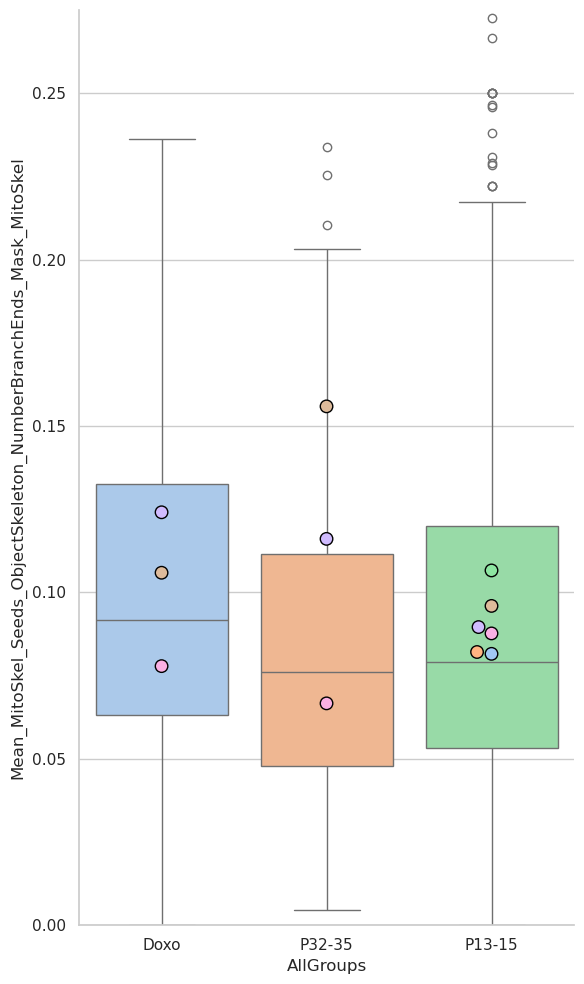

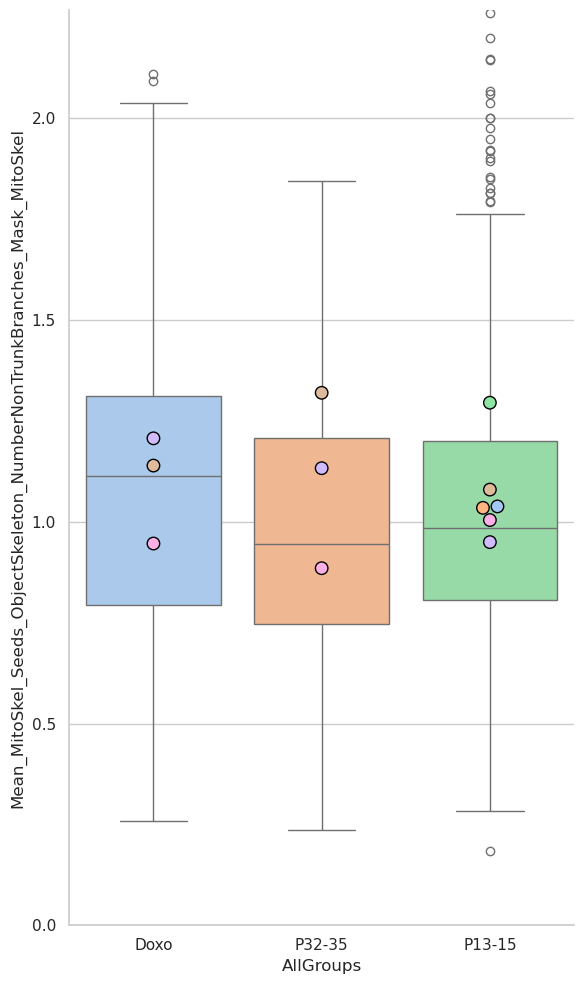

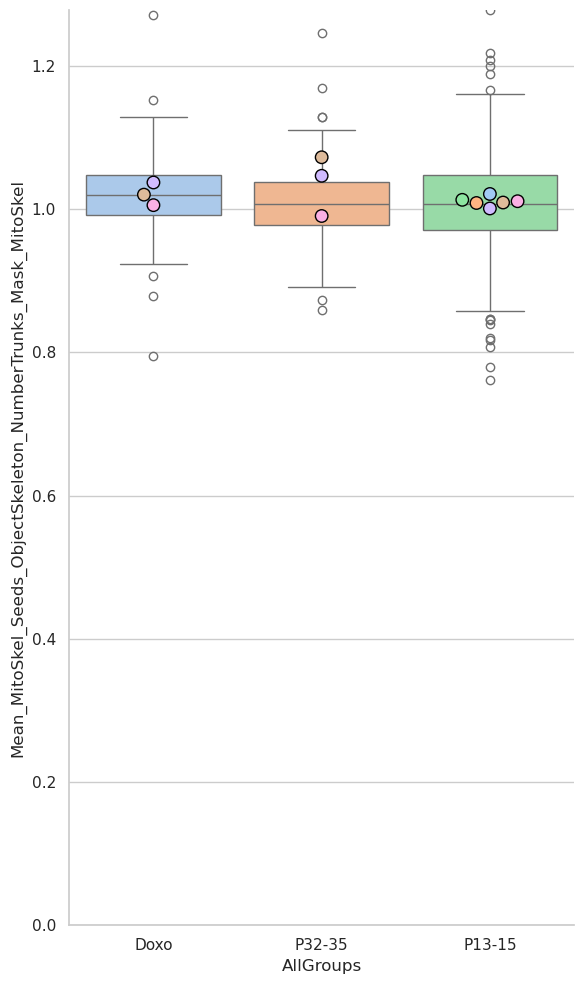

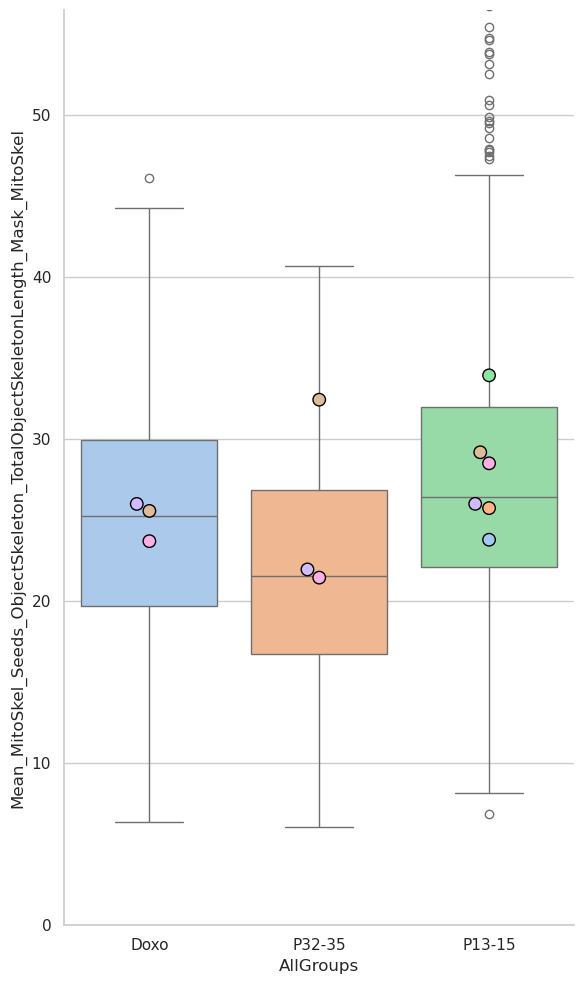

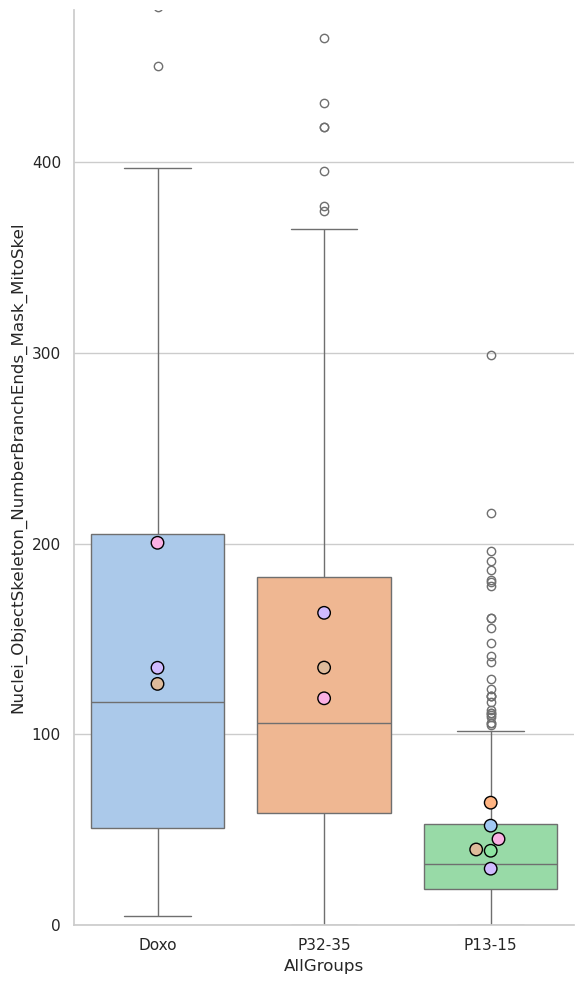

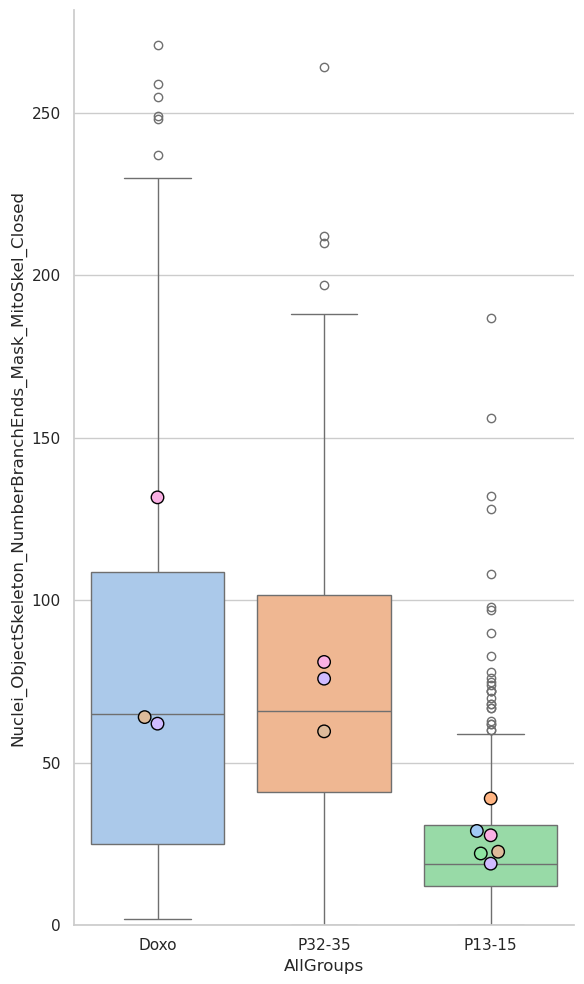

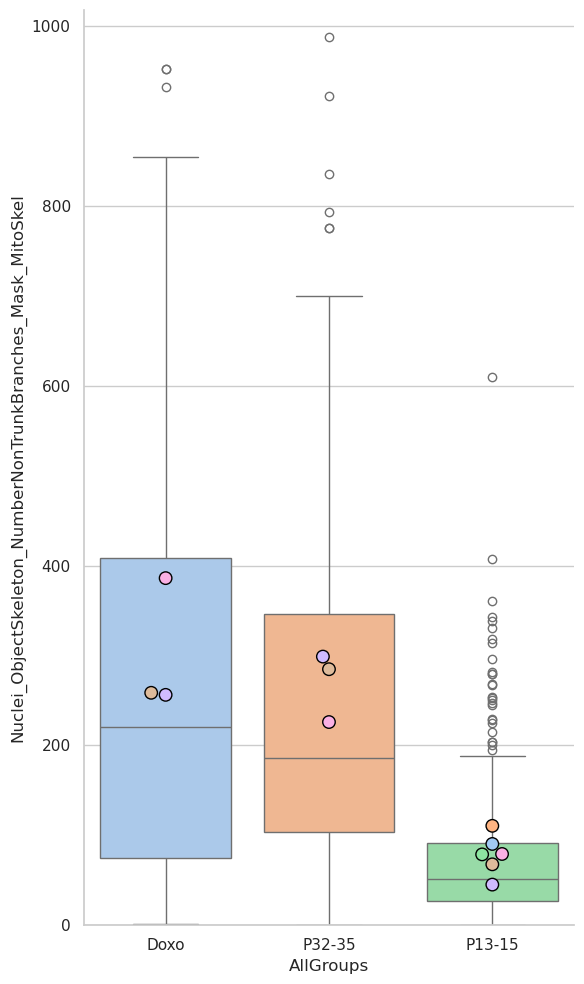

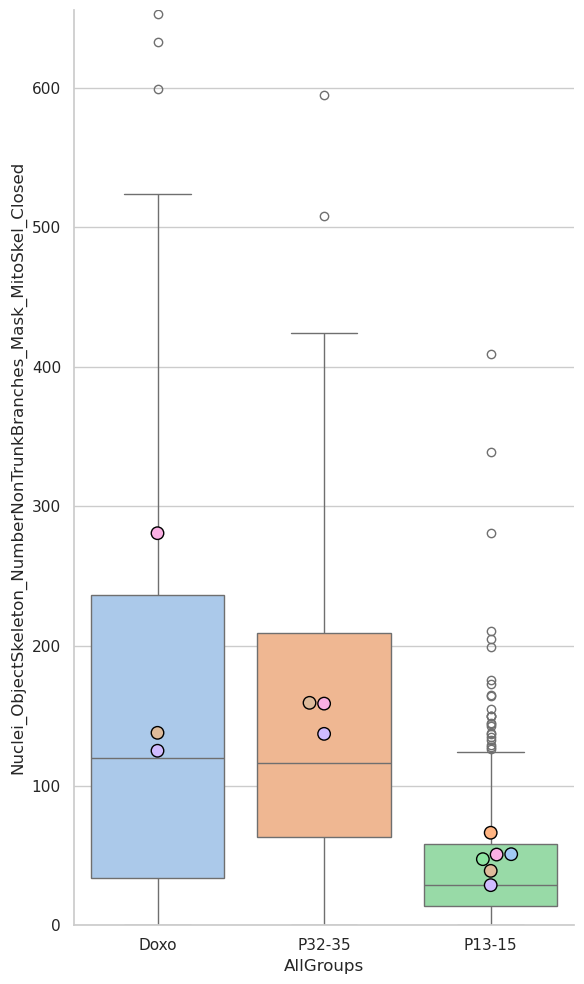

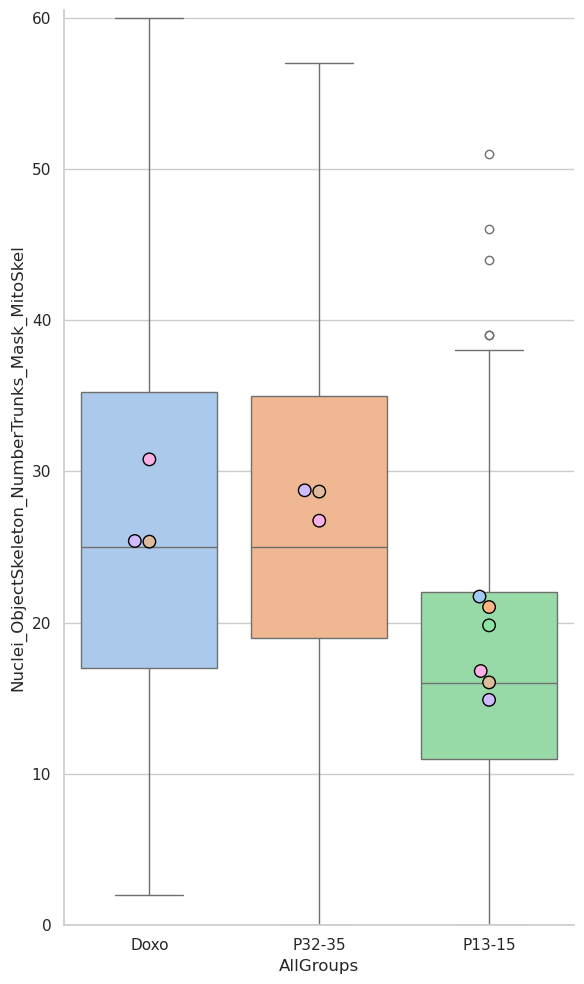

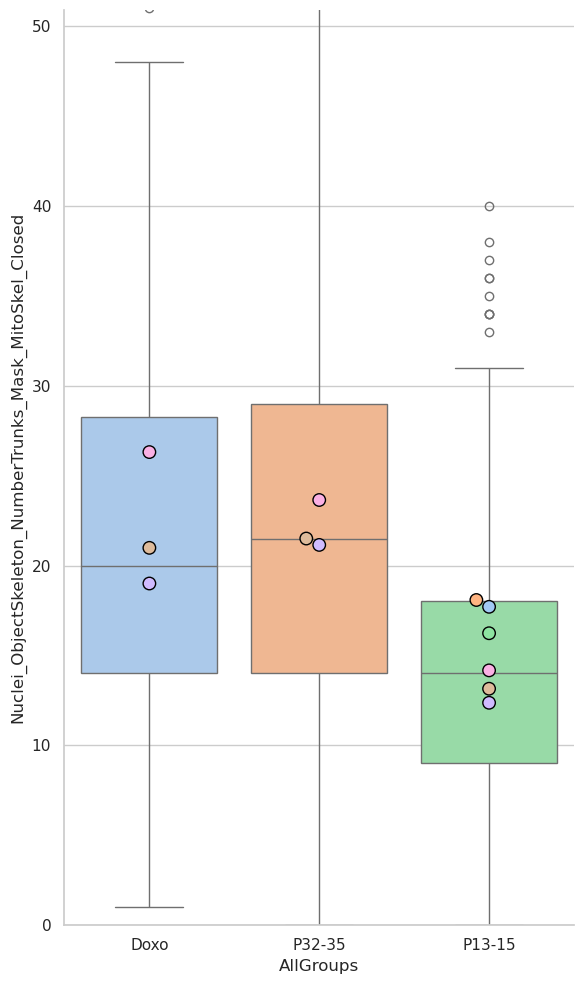

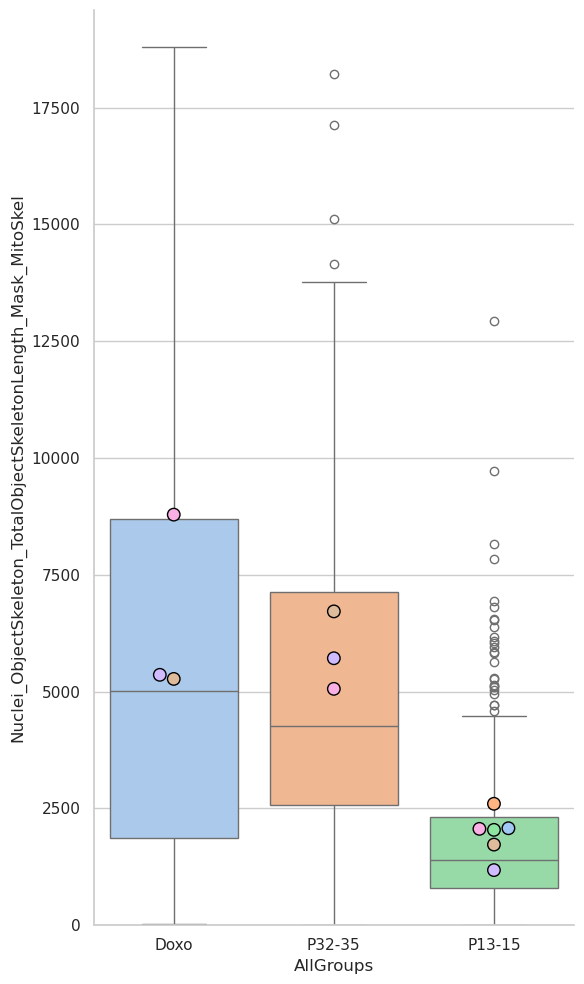

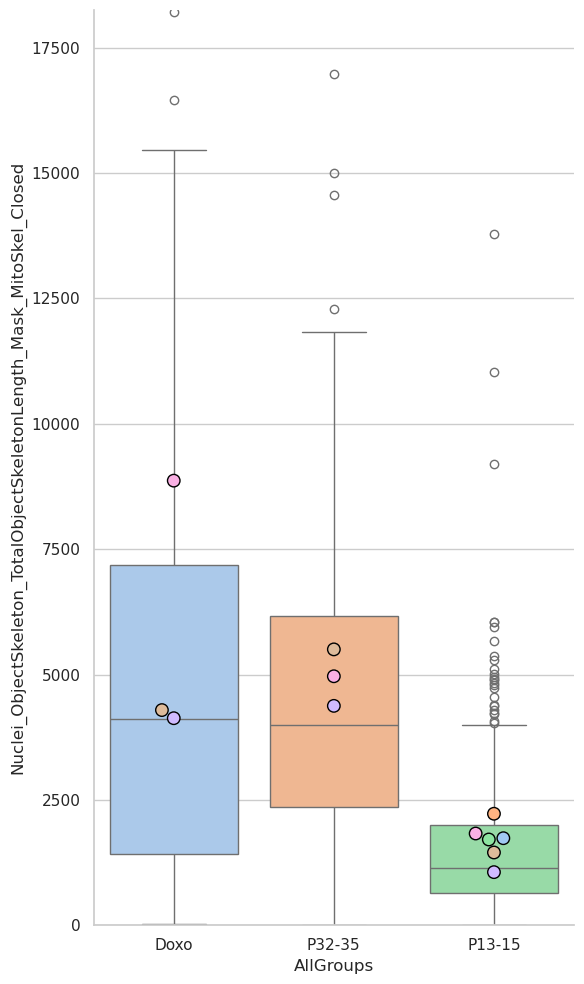

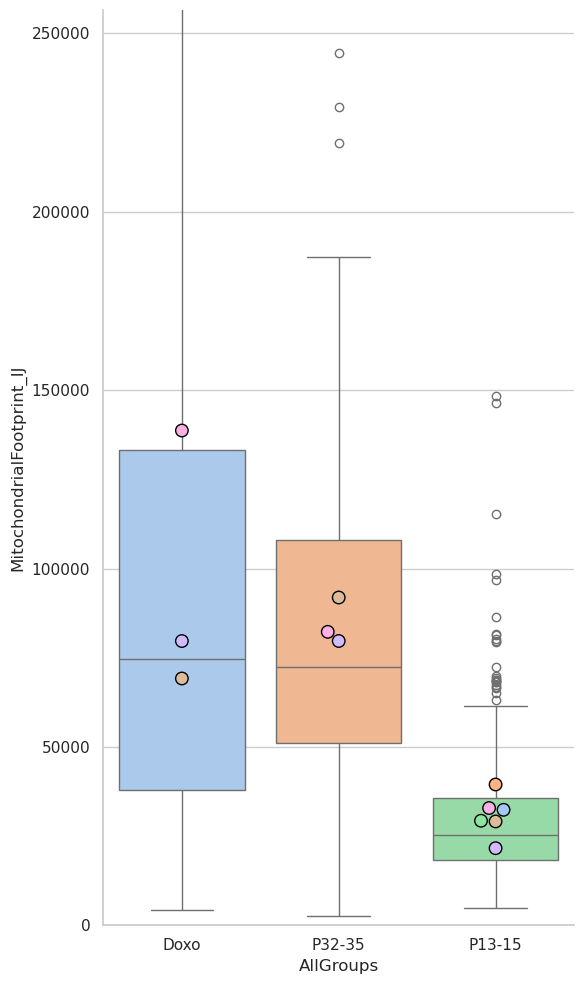

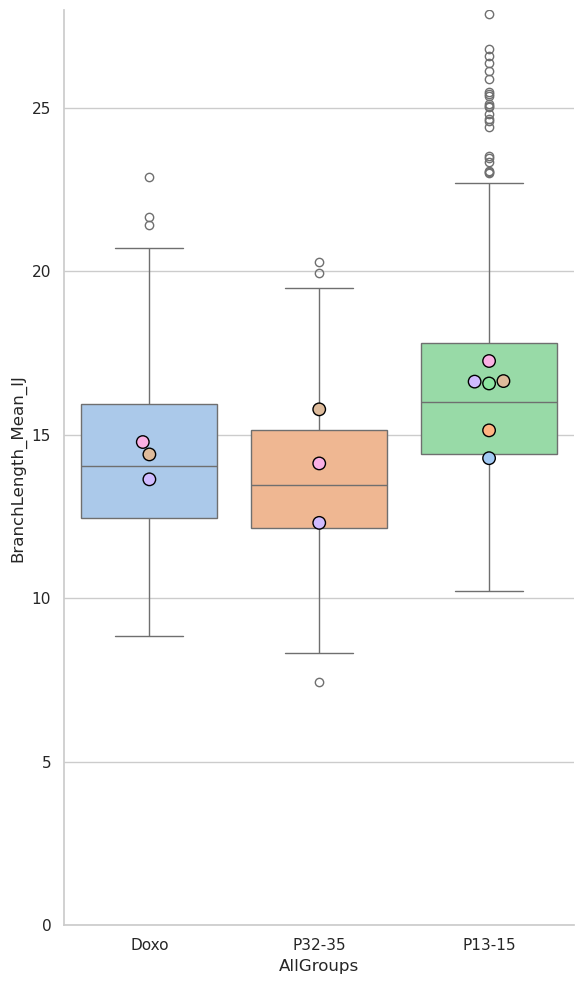

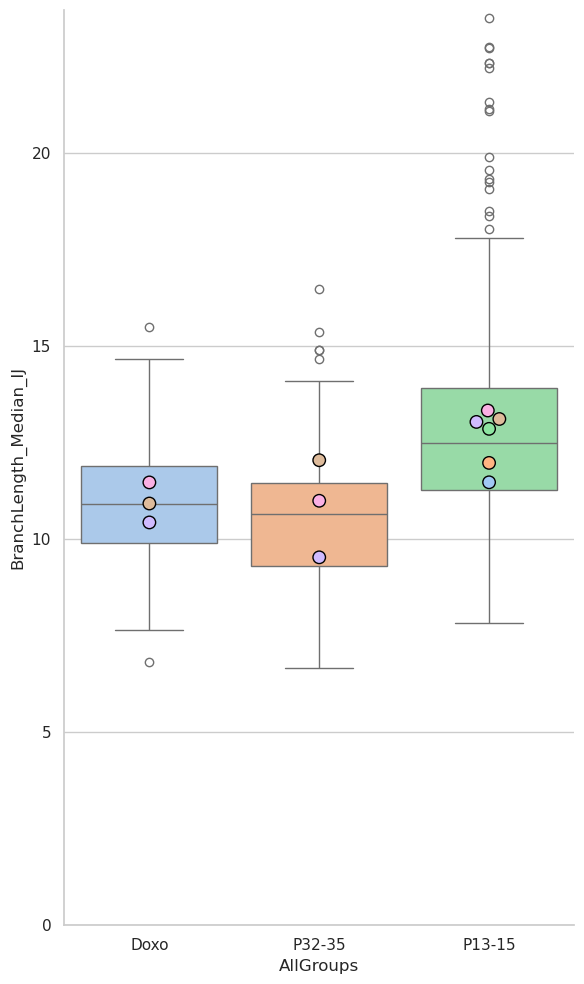

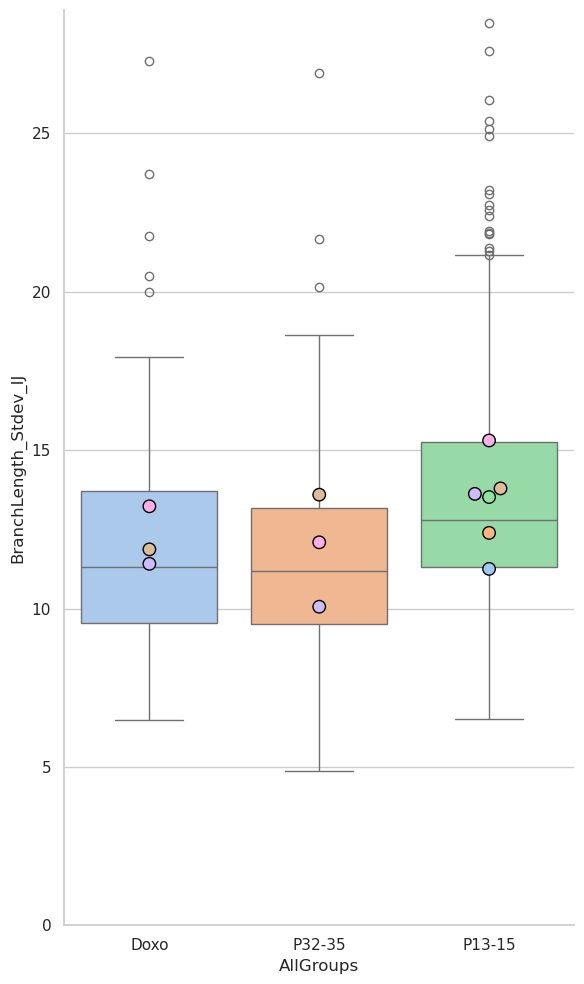

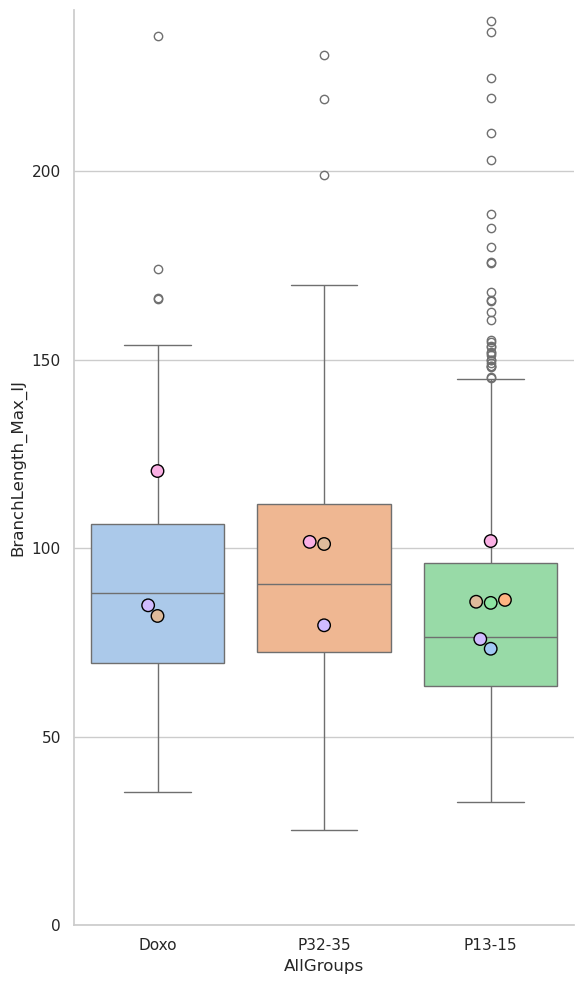

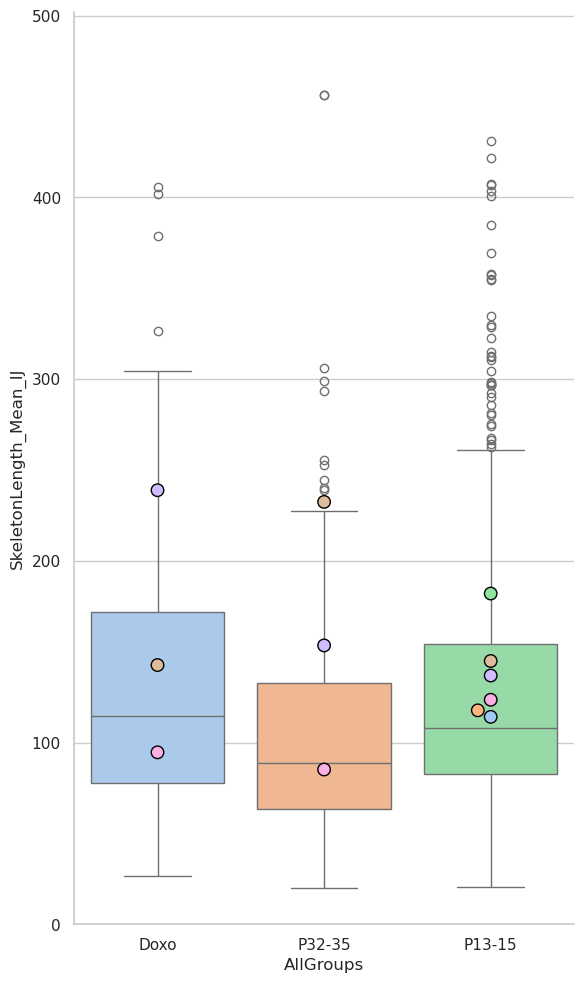

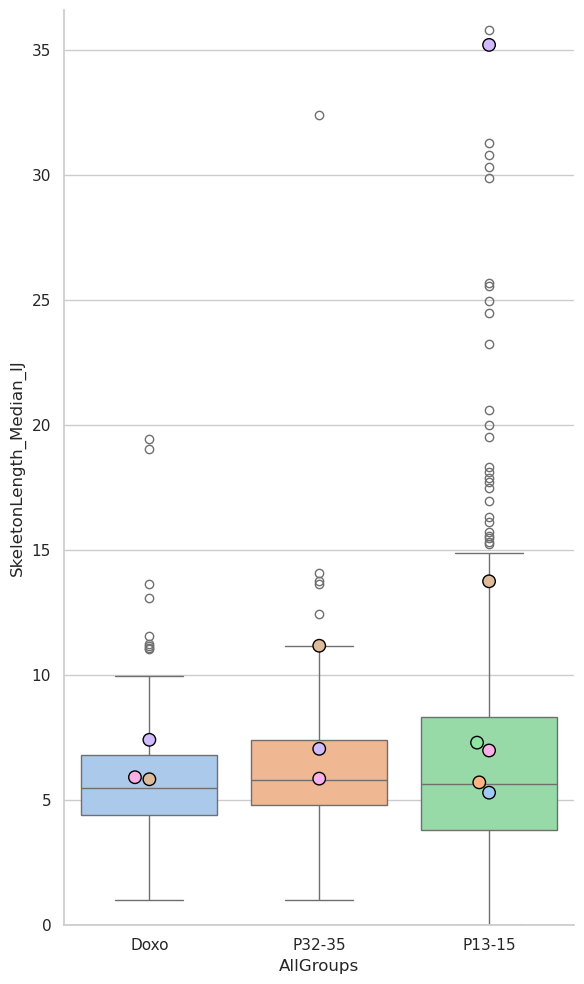

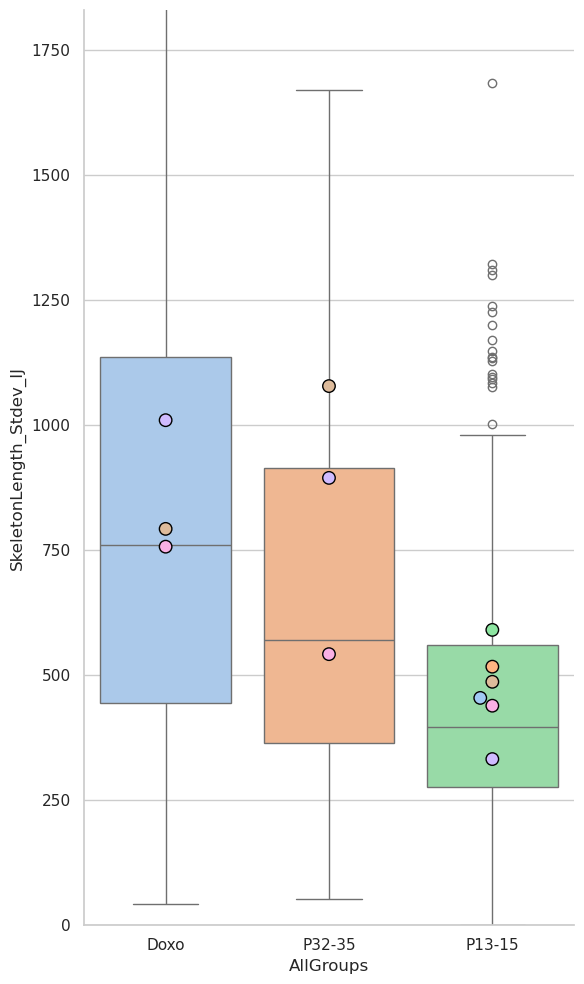

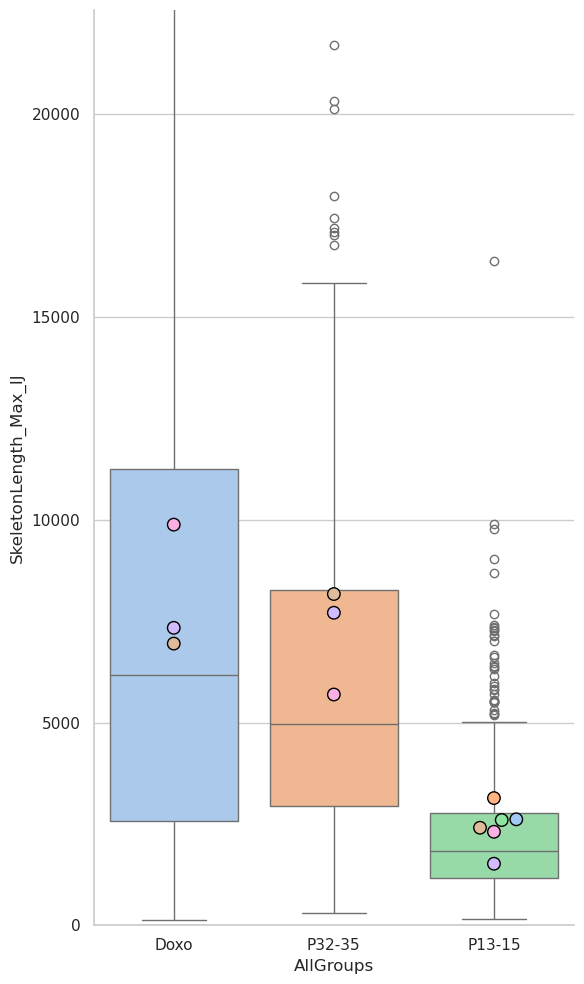

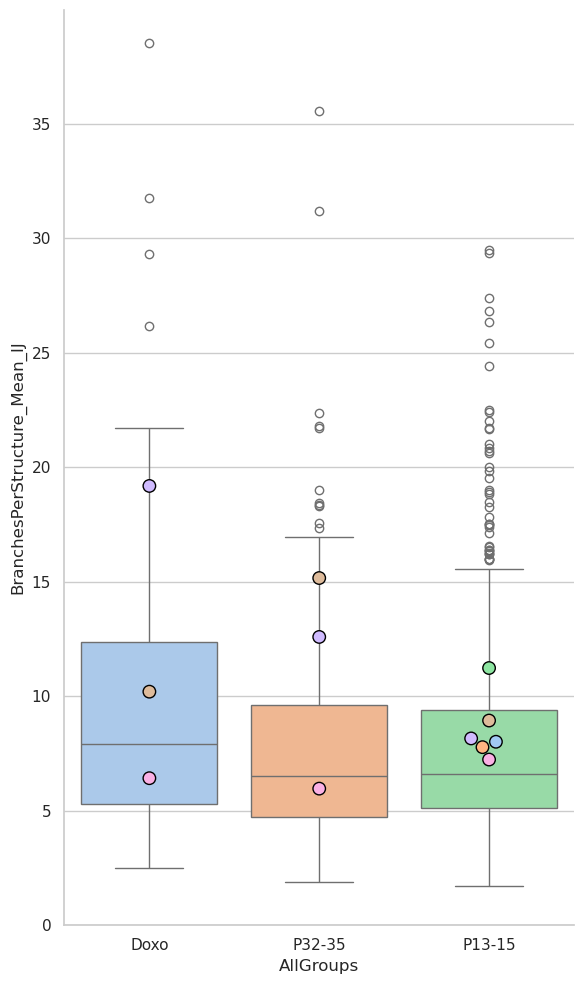

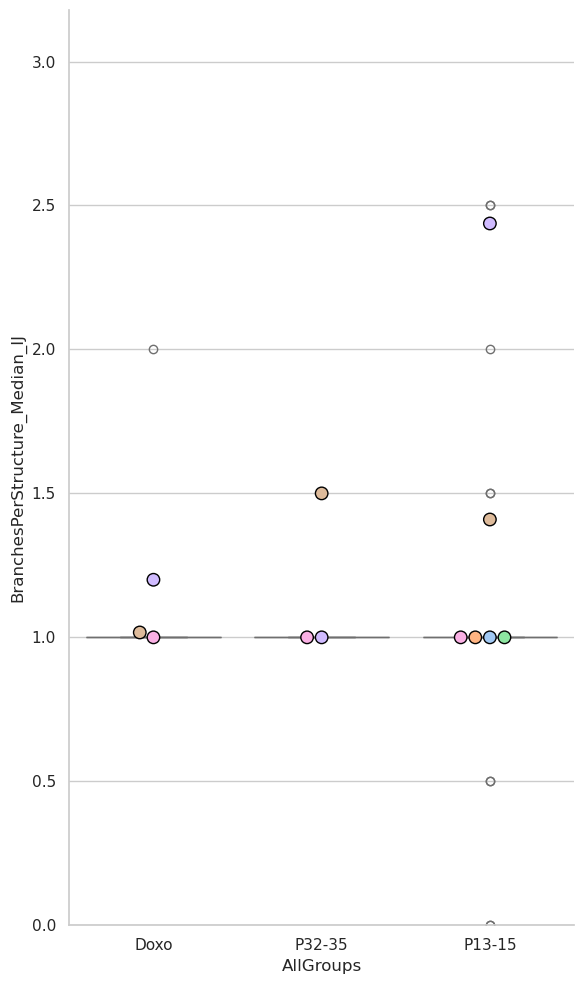

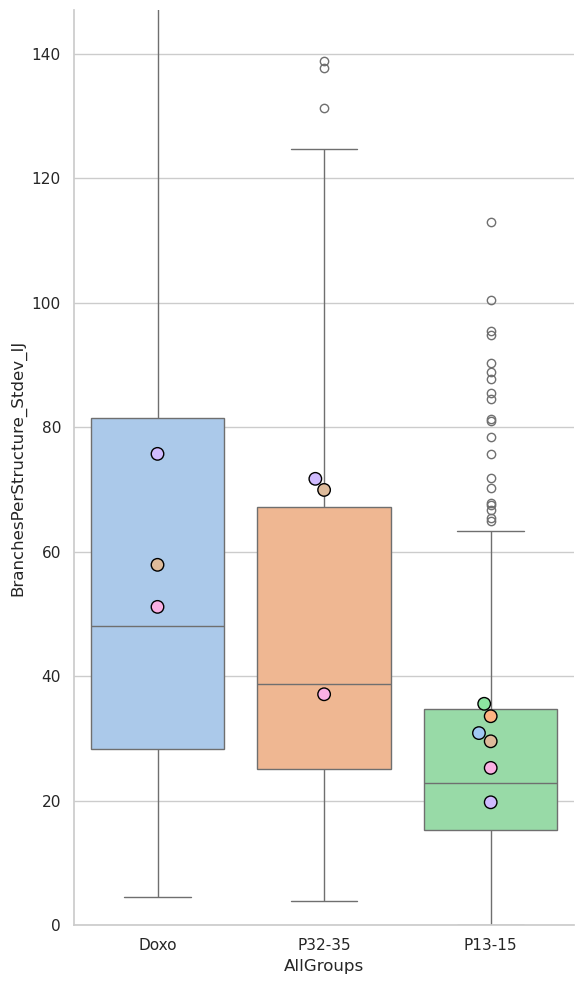

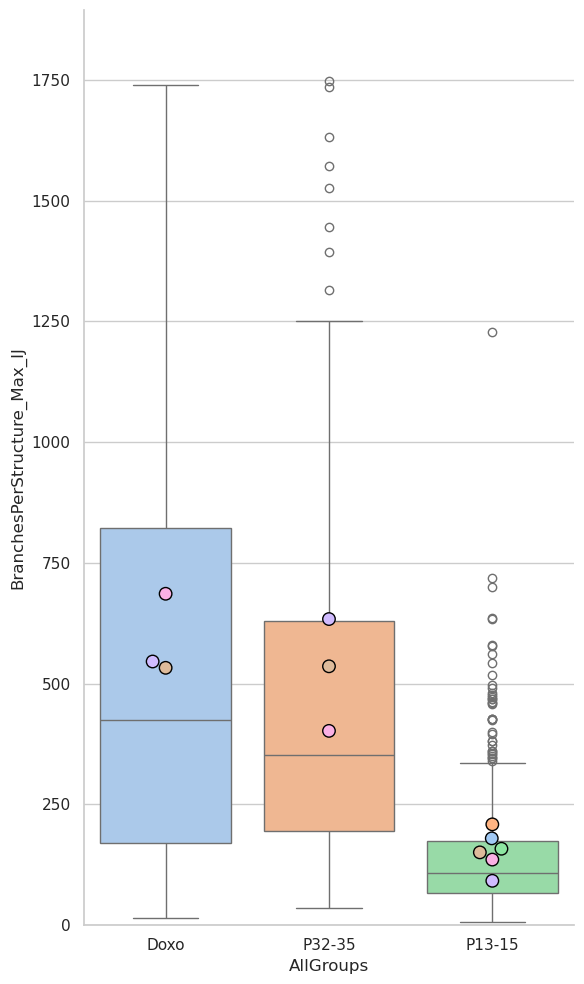

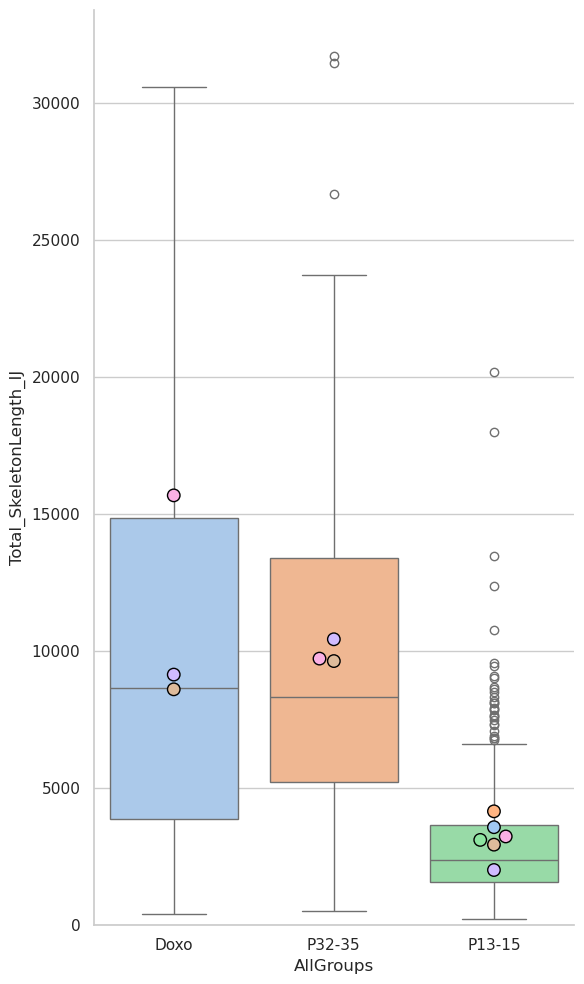

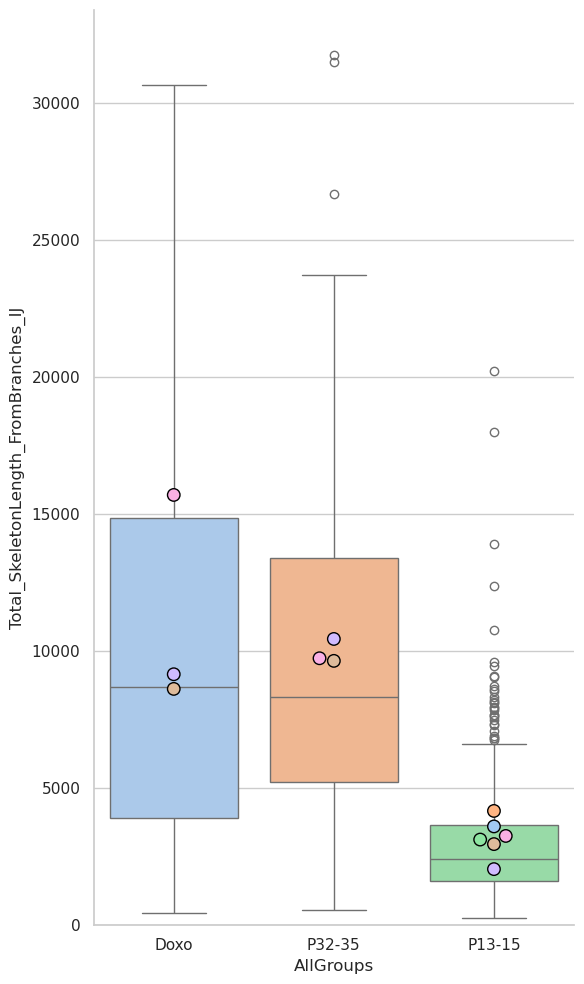

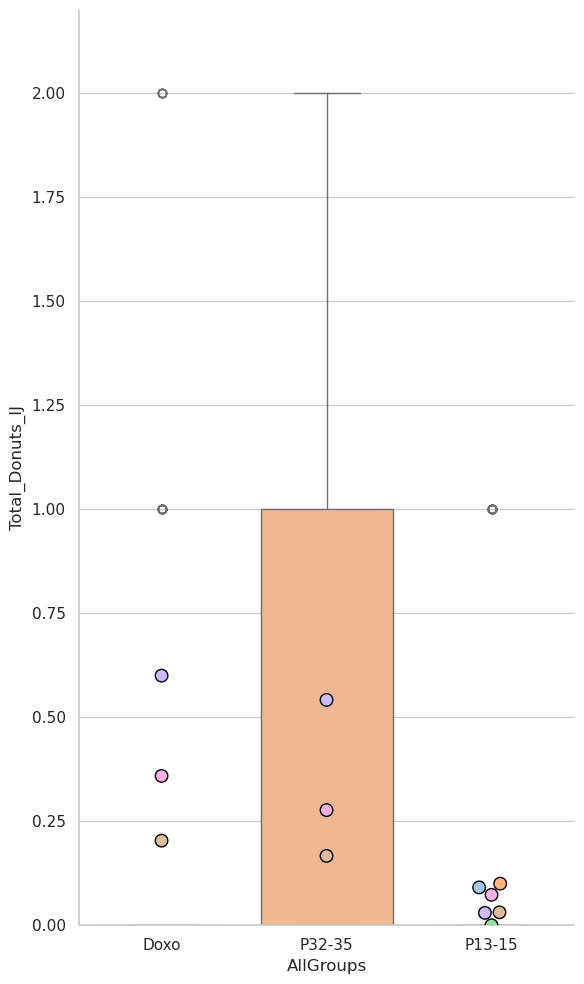

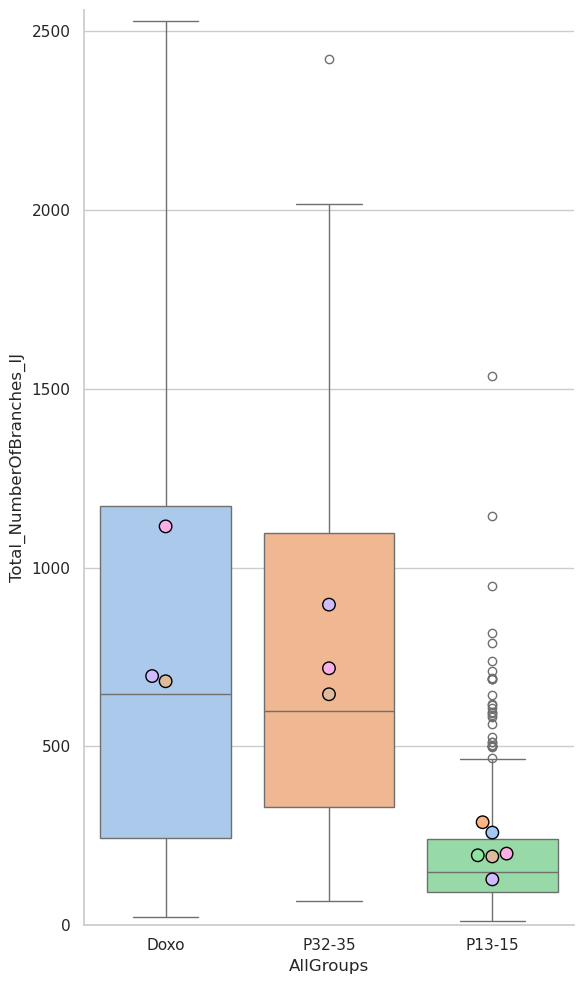

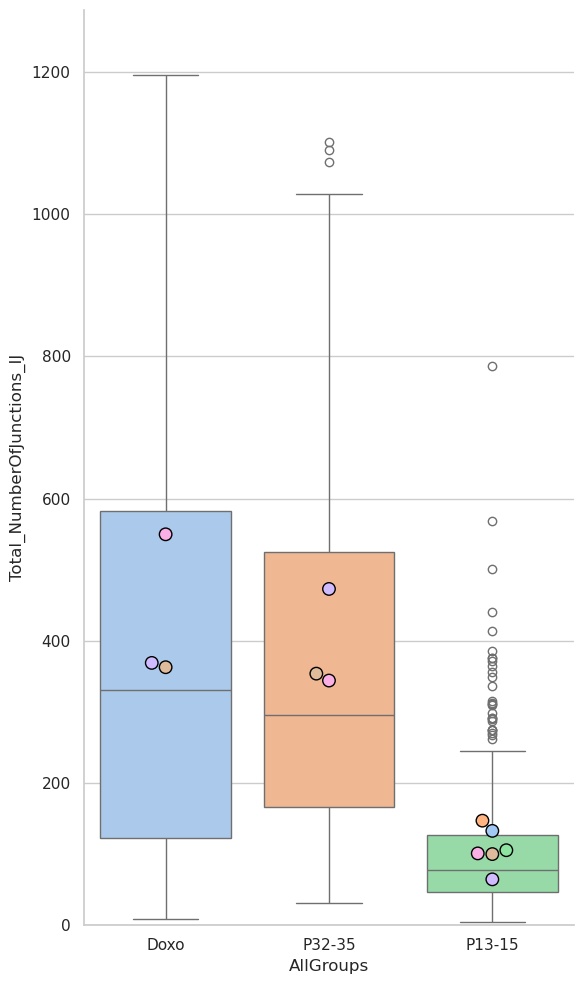

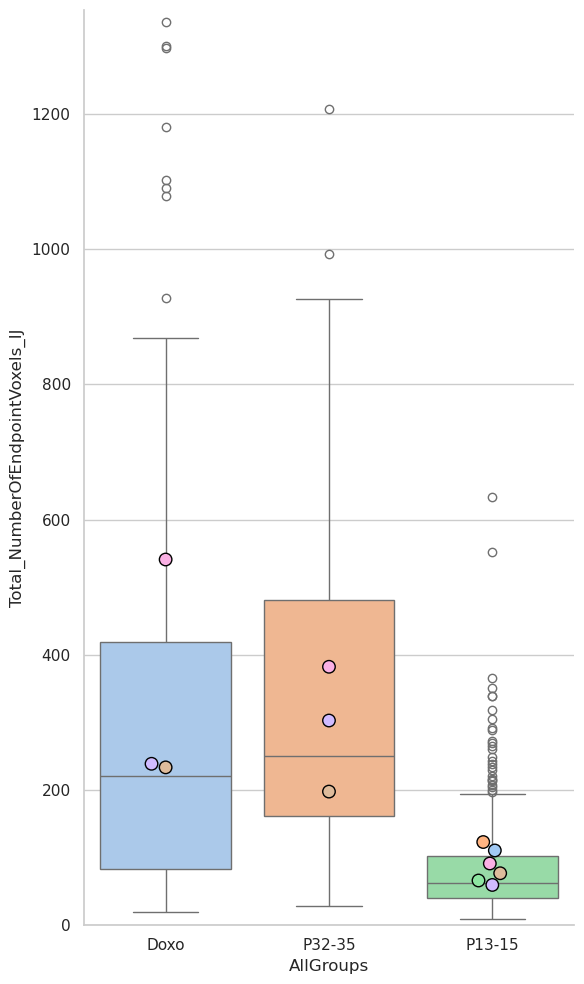

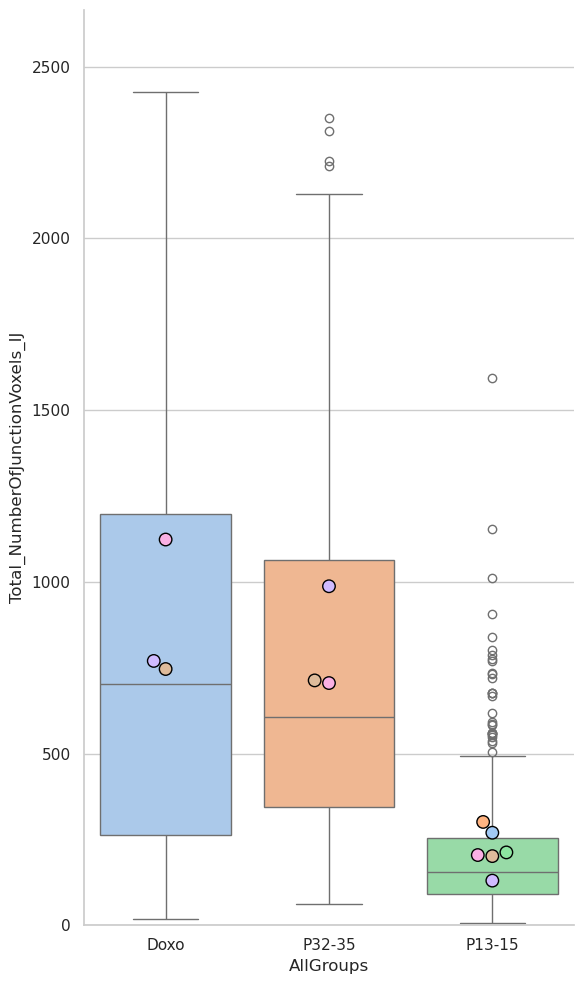

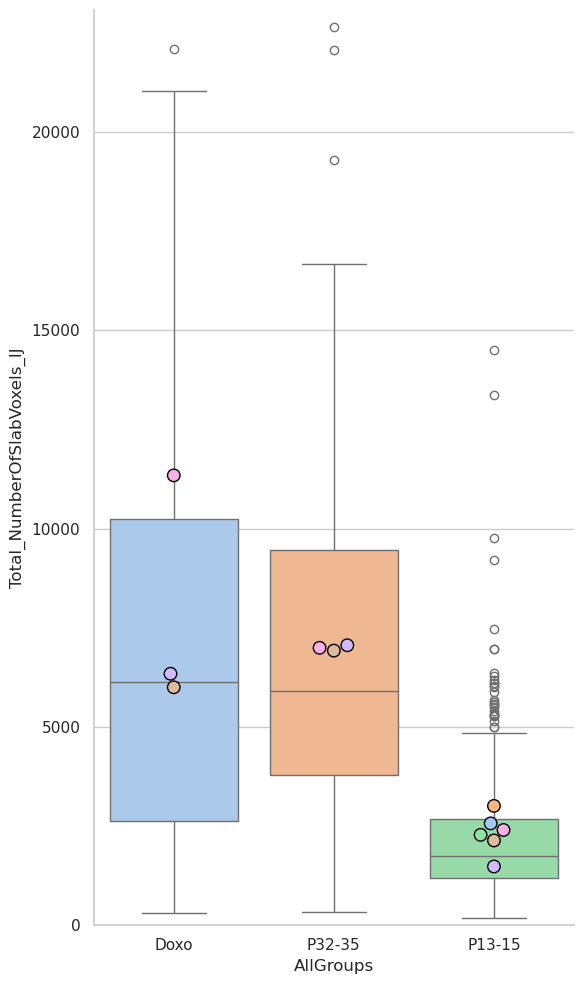

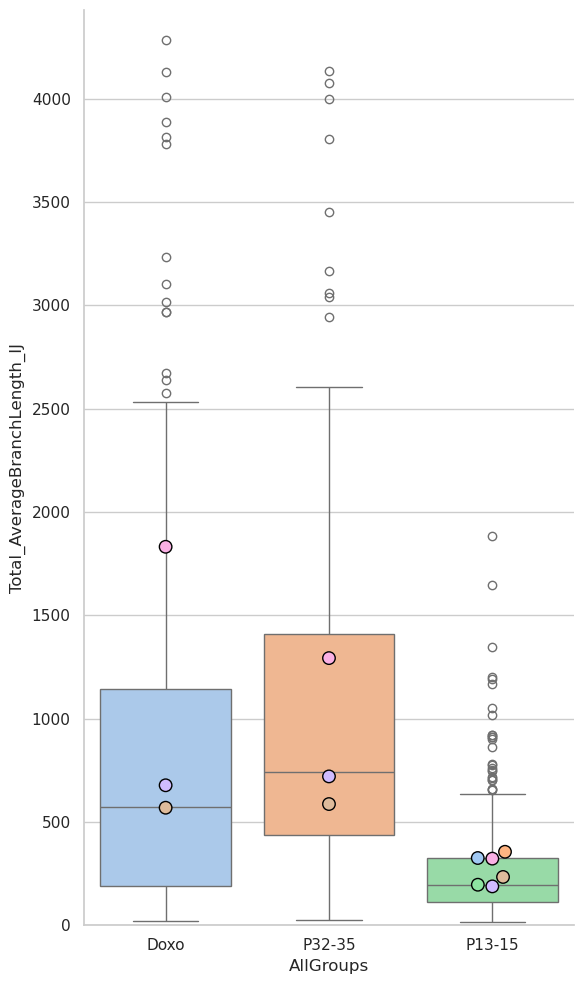

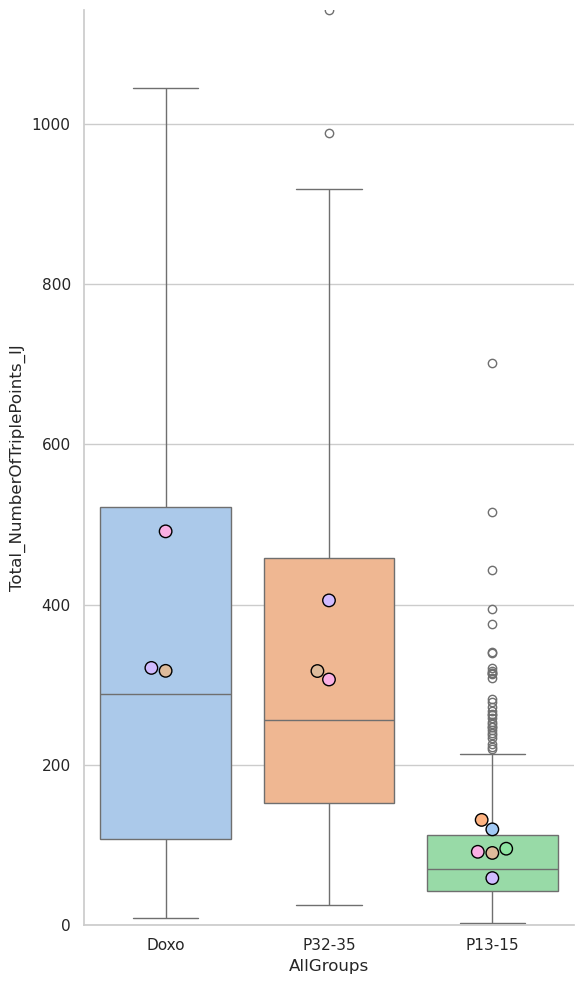

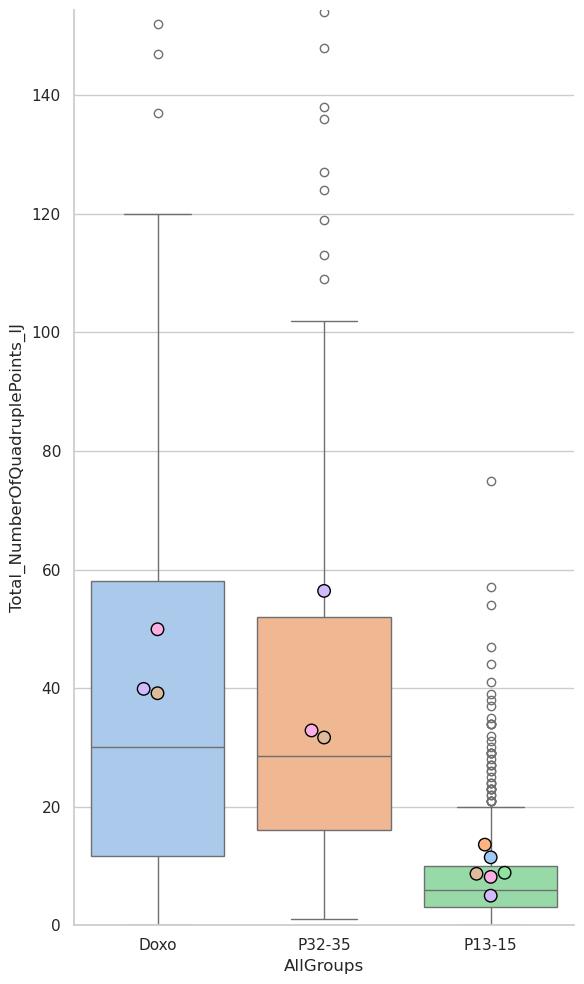

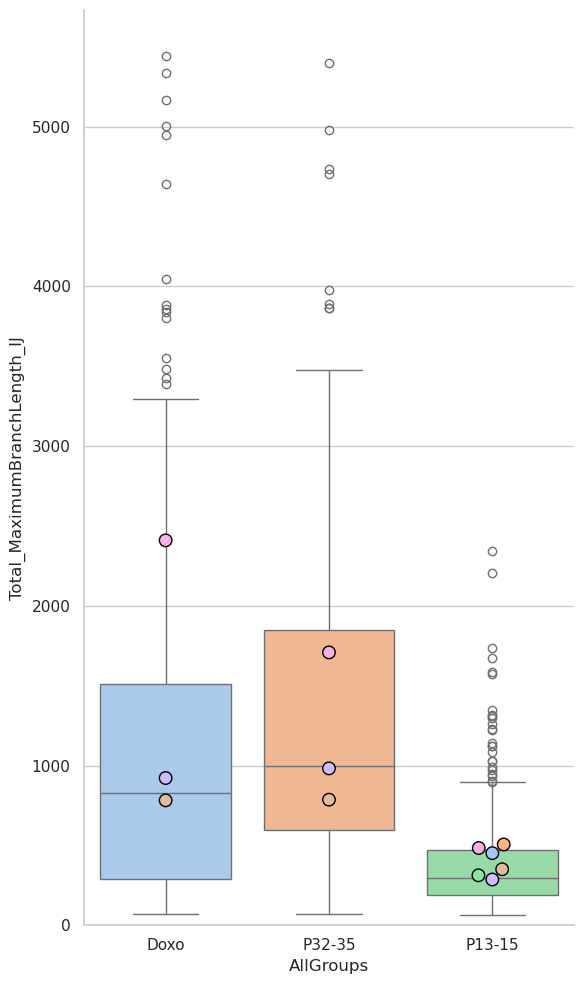

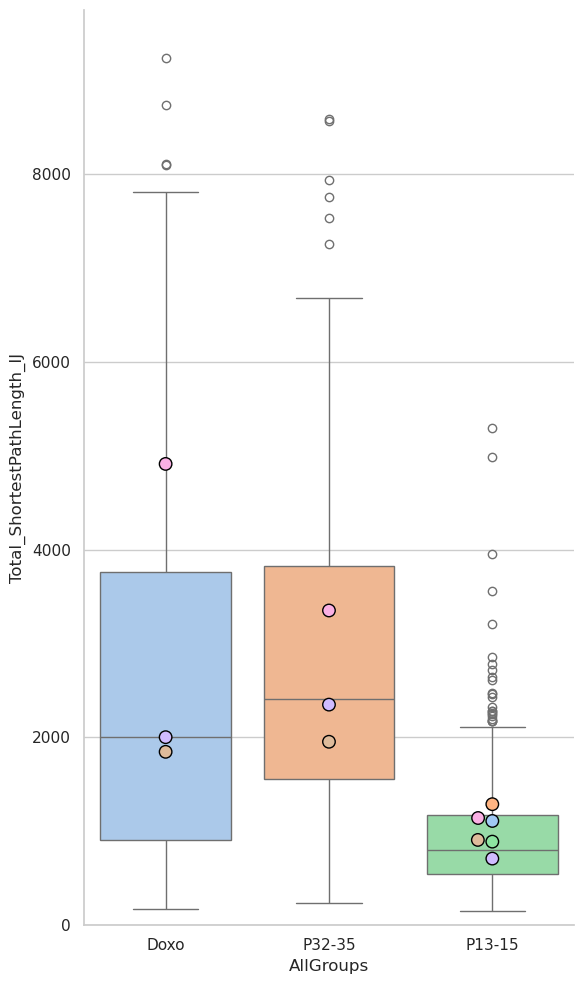

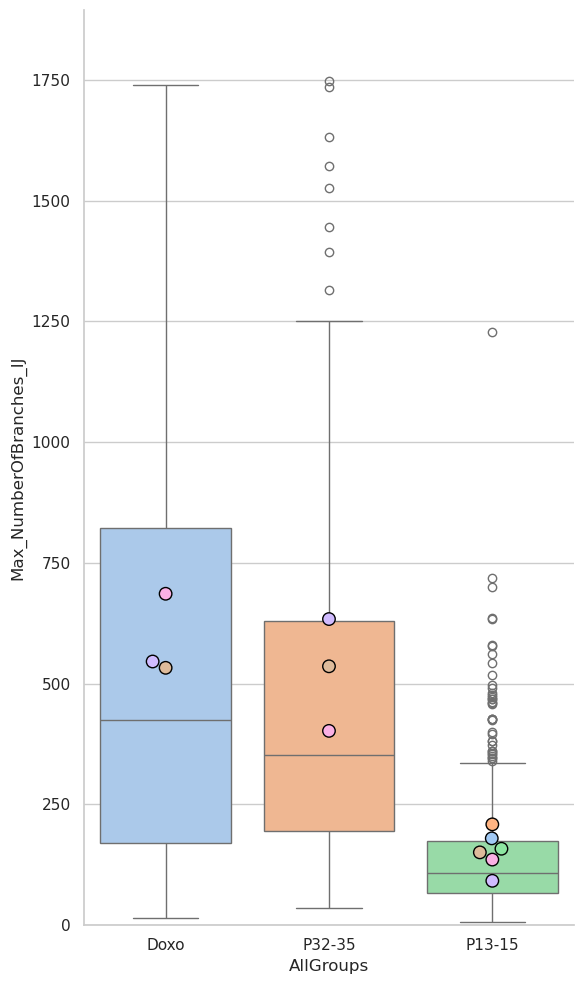

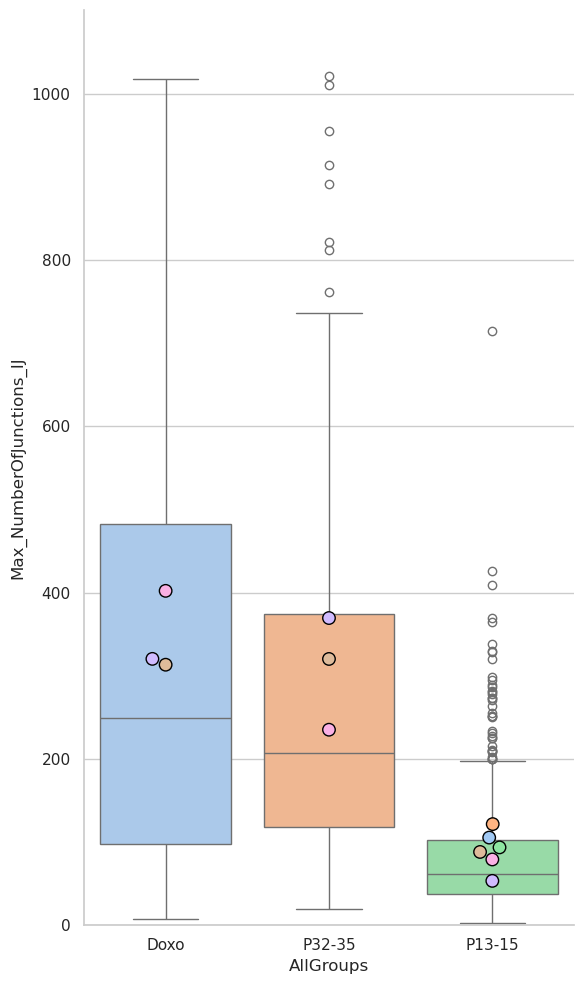

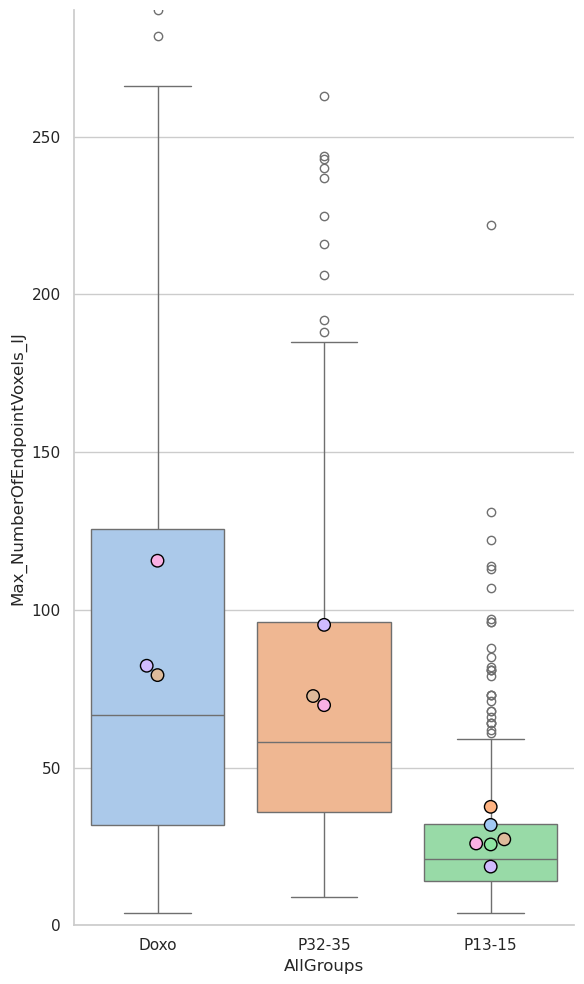

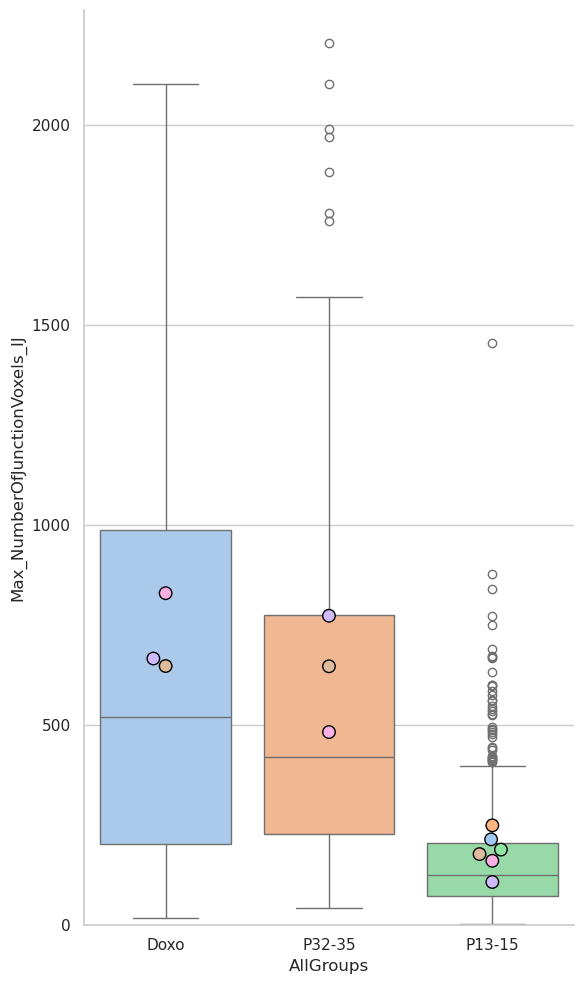

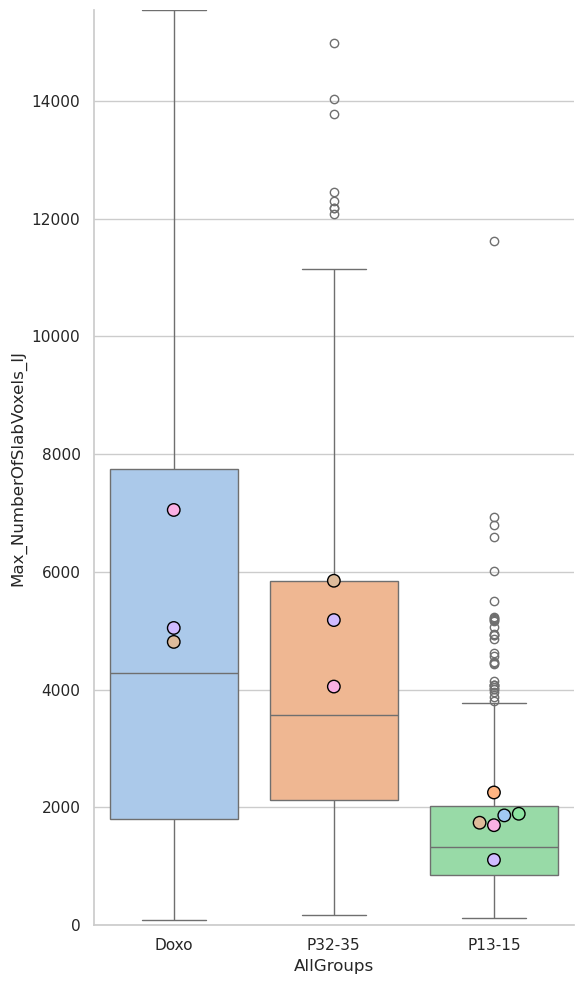

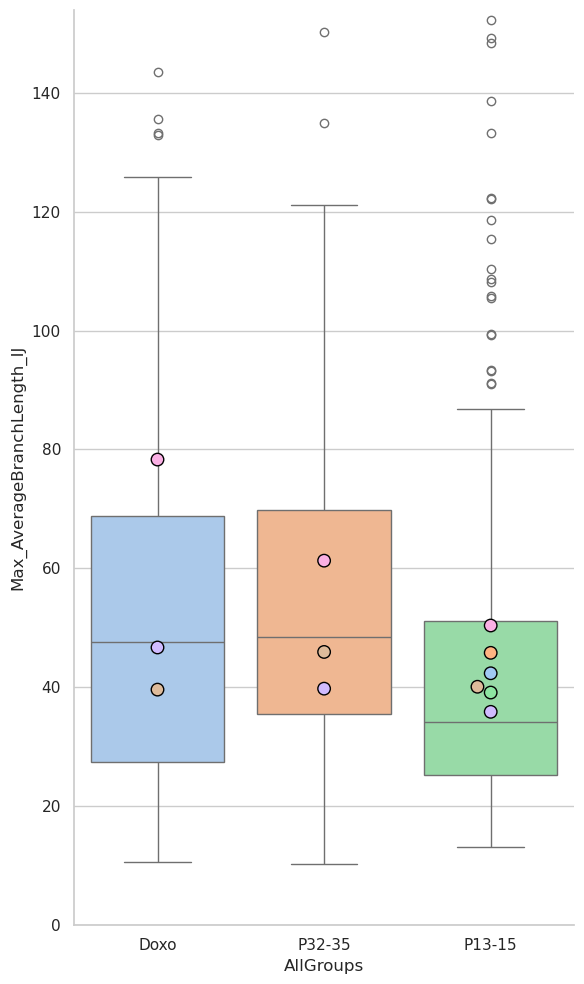

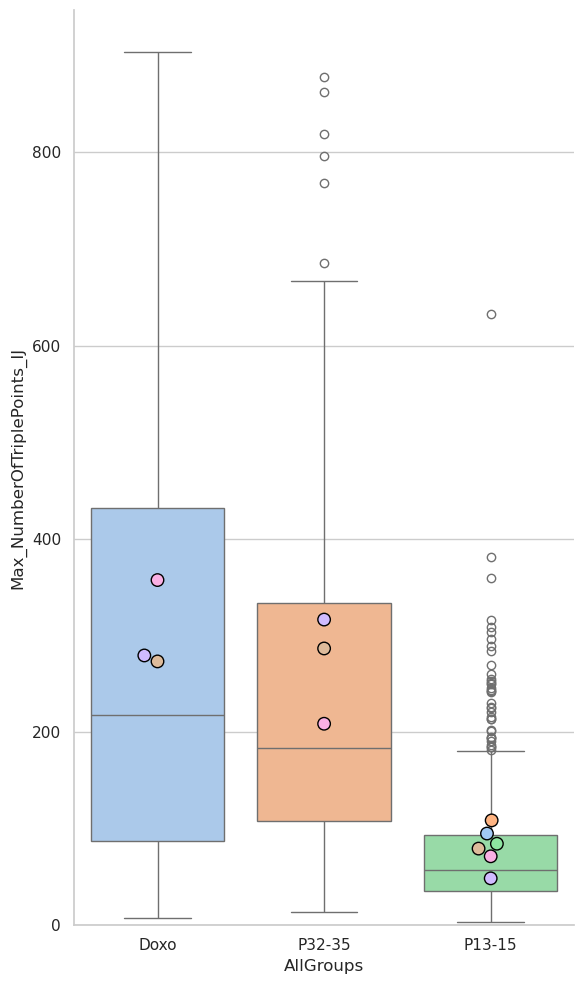

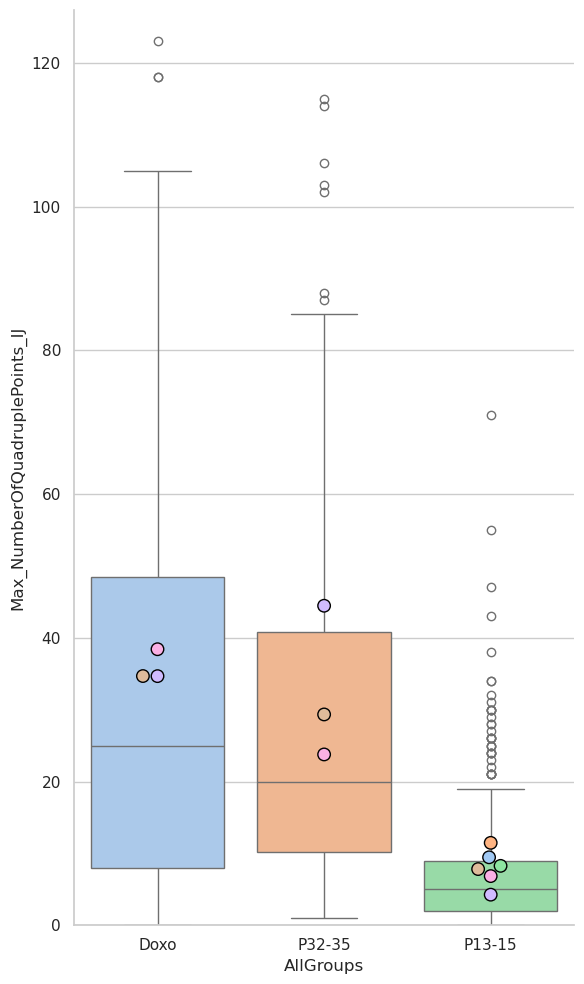

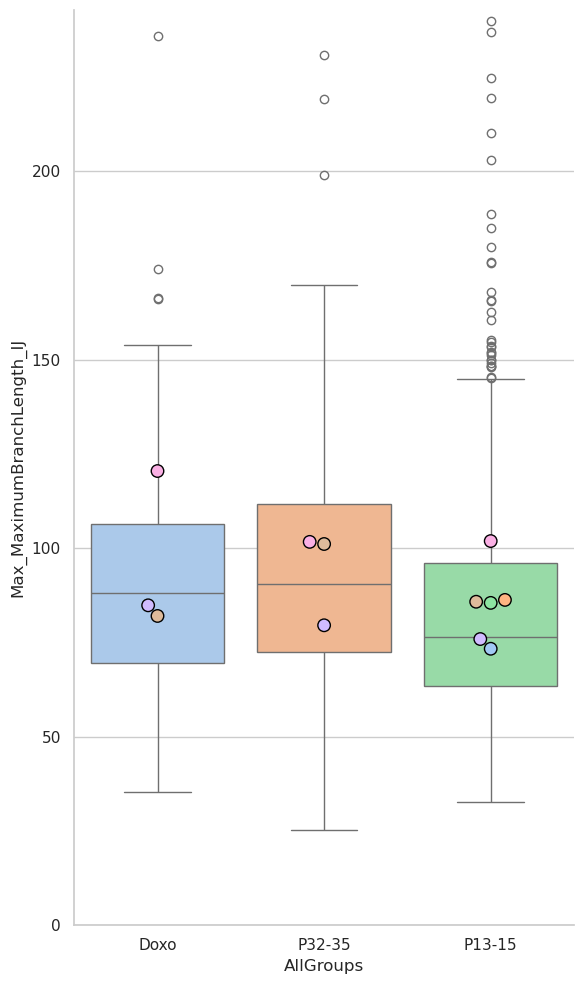

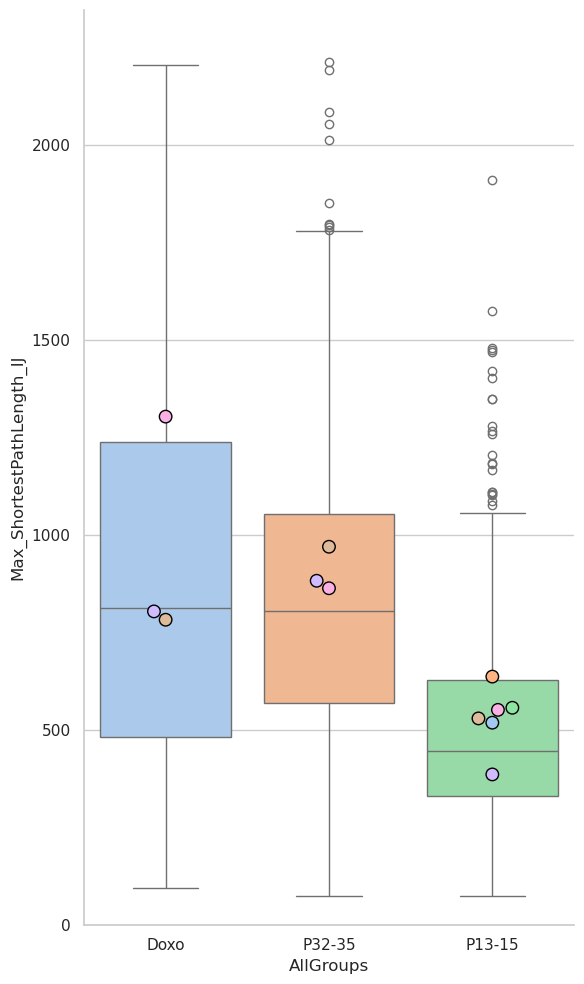

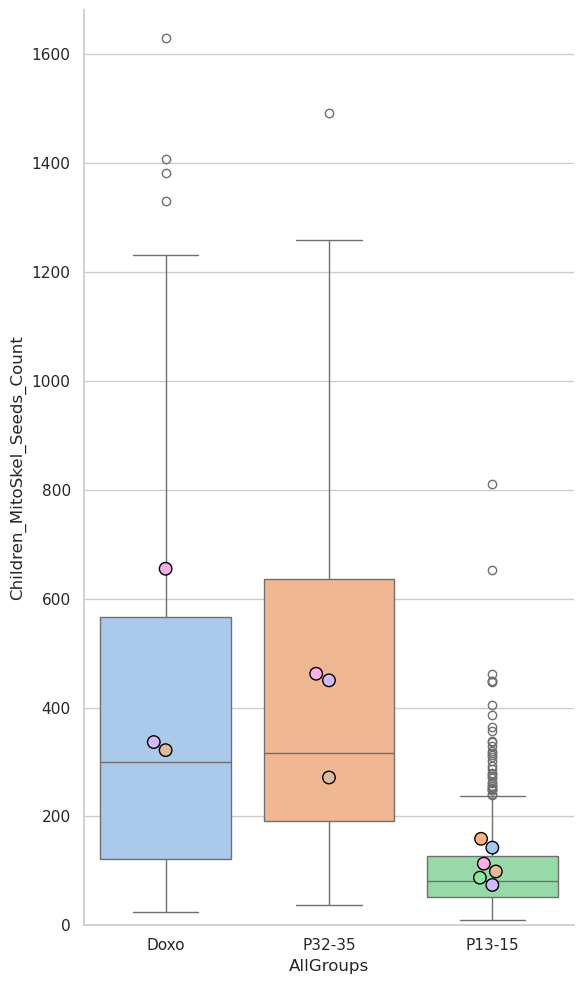

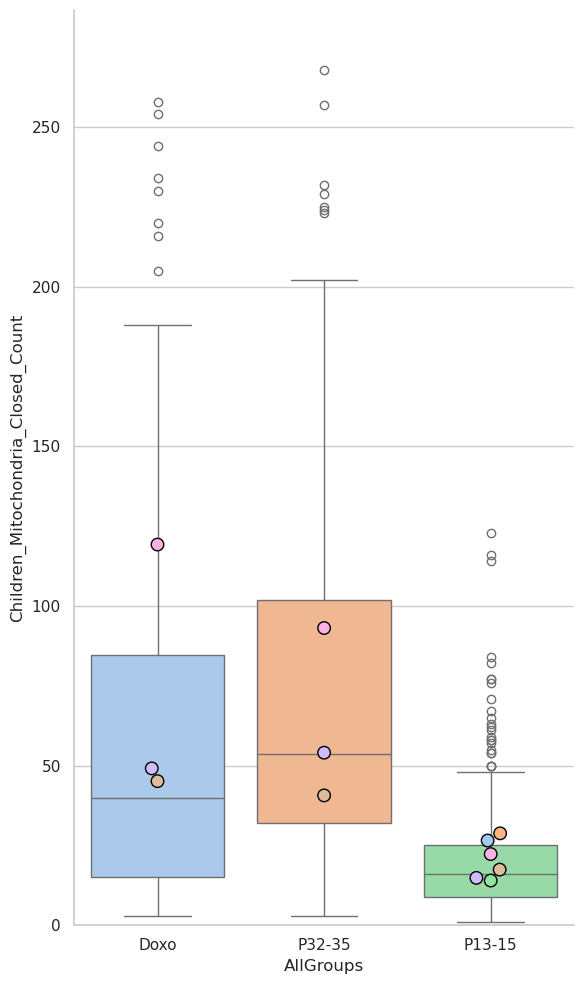

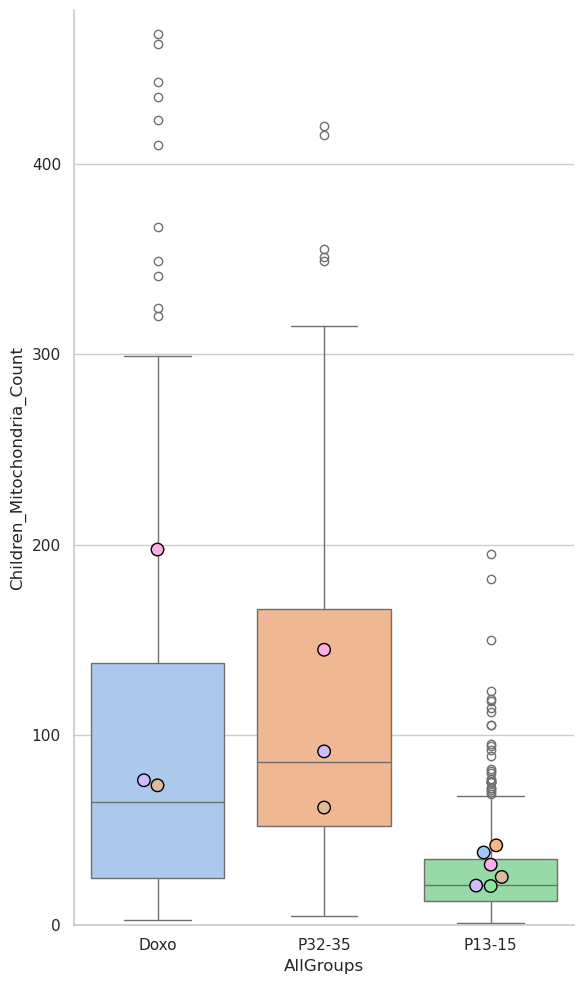

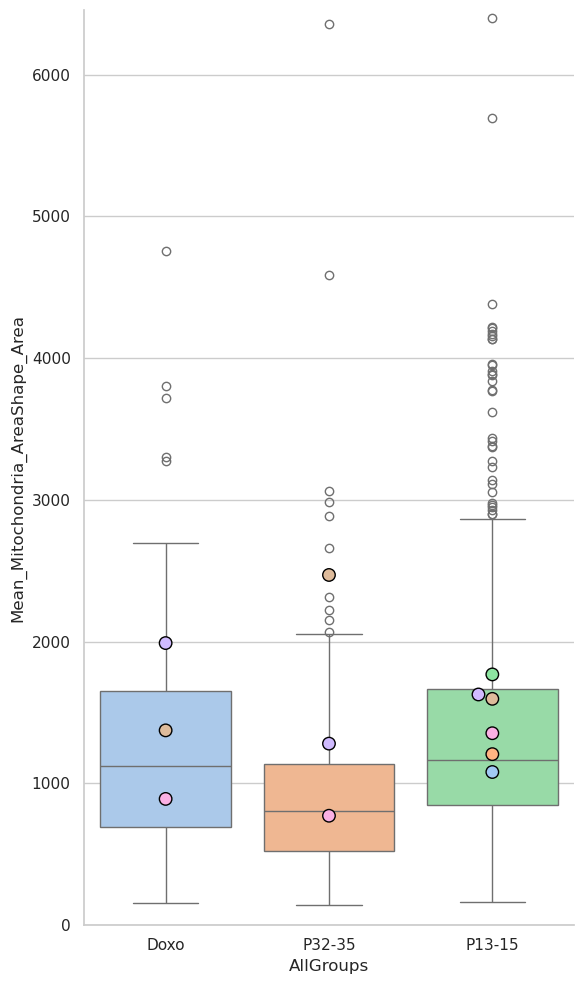

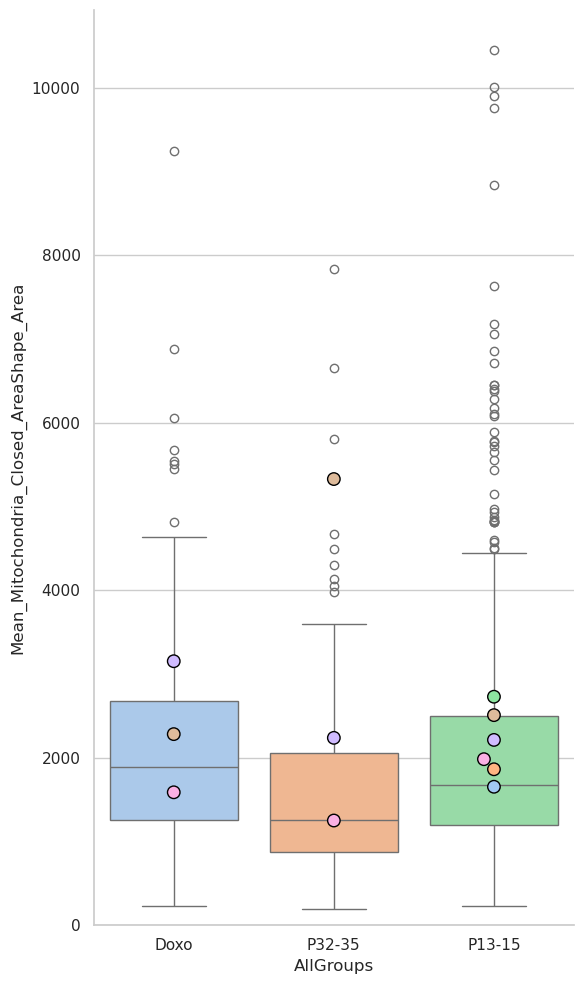

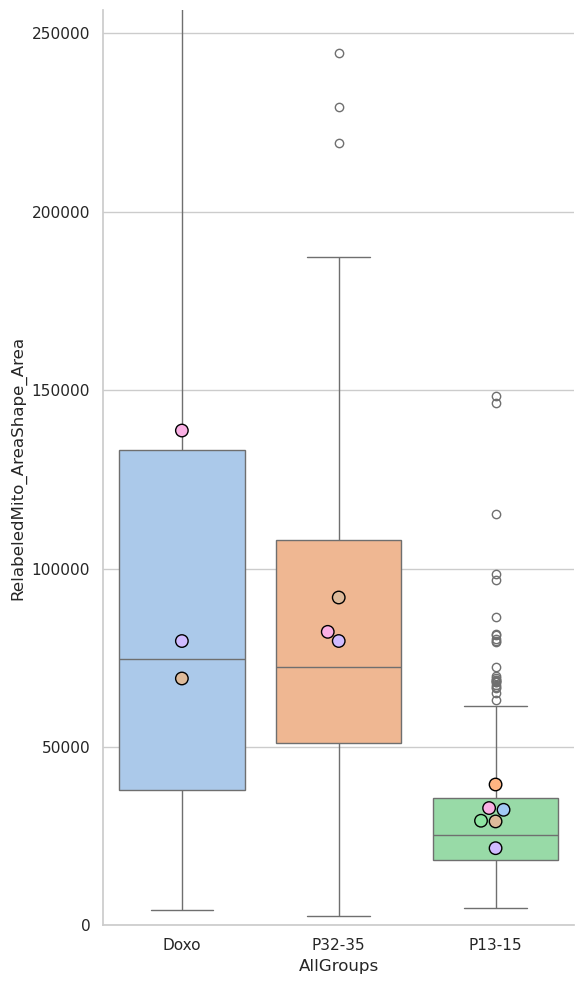

In [35]:


feature_cols = use_cols_unique[4:]
colour_dict = get_hard_code_plate_colours(
    combined_cell_df_mitolyso2, ["1", "2", "3", "4", "5", "6", "7"], "Metadata_PlateNumber"
)
def plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict=colour_dict, size=(6, 10)):
    outpath = "segmentation_test/plots"
    os.makedirs(outpath, exist_ok=True)
    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("notebook")
        sns.boxplot(display_df, x="AllGroups", y=col, palette="pastel" , fill=True, hue="AllGroups", legend=False)
        sns.swarmplot(display_df_pivot_plates, x="AllGroups", y=col, palette=colour_dict,hue="Metadata_PlateNumber", dodge=False, size = 9, legend=False, linewidth=1, edgecolor="k" )
        sns.despine()
        plt.ylim(0, np.percentile(display_df[col].dropna(), 99)*1.1)  
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
        plt.show()
        
# def plot_boxplots_with_swarm_pairs(
#     display_df,
#     display_df_pivot_plates,
#     feature_cols,
#     colour_dict=colour_dict,
#     size=(6, 10),
# ):
#     outpath = "segmentation_test/pairedplots"
#     os.makedirs(outpath, exist_ok=True)
#     for col in feature_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]), sharey=True)

#         for ax, suffix in zip(axes, ["1", "2"]):
#             item = rows[suffix]
#         sns.set_style("whitegrid")
#         sns.set_context("notebook")
#         ax = plt.gca()
#         ax = sns.boxplot(
#             display_df,
#             x="AllGroups",
#             y=col,
#             palette="pastel",
#             fill=True,
#             hue="AllGroups",
#             legend=False,
#         )
#         sns.swarmplot(
#             display_df_pivot_plates,
#             x="AllGroups",
#             y=col,
#             palette=colour_dict,
#             hue="Metadata_PlateNumber",
#             dodge=False,
#             size=9,
#             legend=False,
#             linewidth=1,
#             edgecolor="k",
#         )
#         sns.despine()
#         plt.ylim(0, np.percentile(display_df[col].dropna(), 99) * 1.1)
#         plt.tight_layout()
#         plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
#         plt.show()

plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 10))

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:1.400e-02


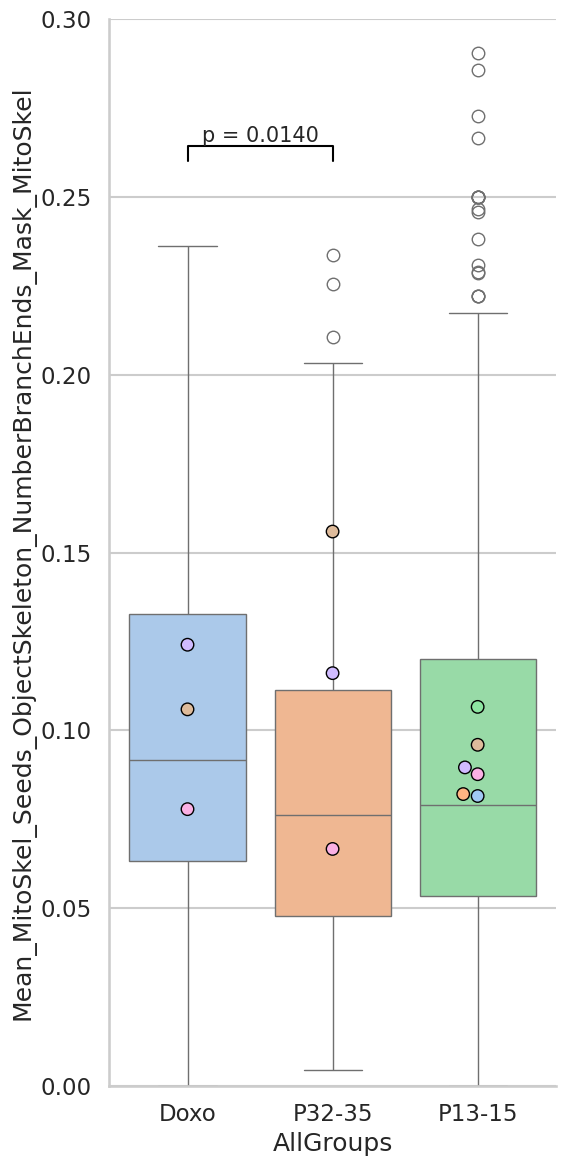

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:9.900e-03


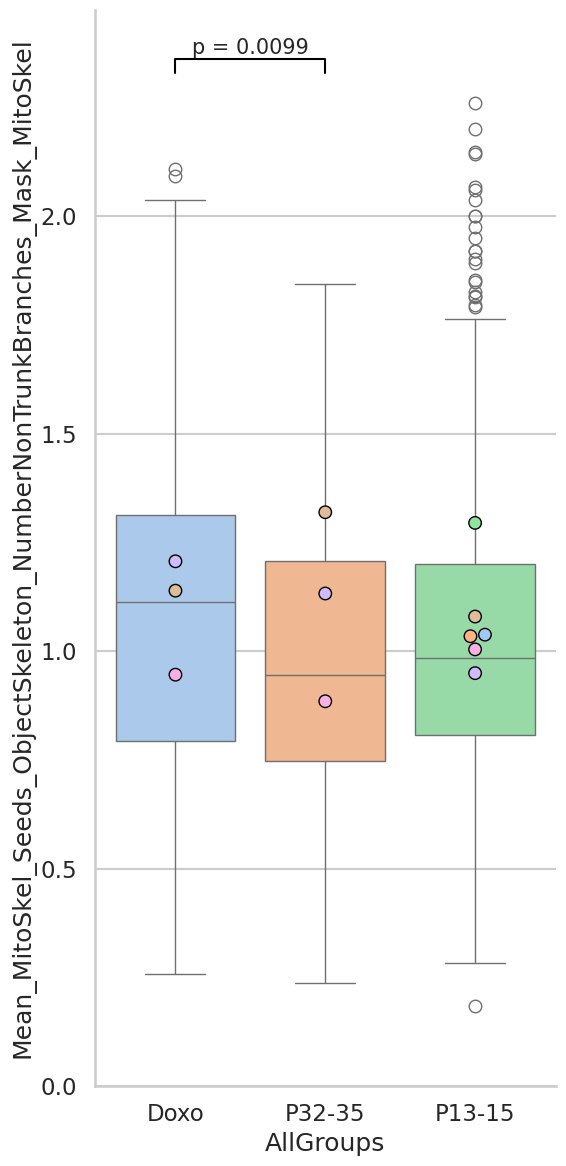

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


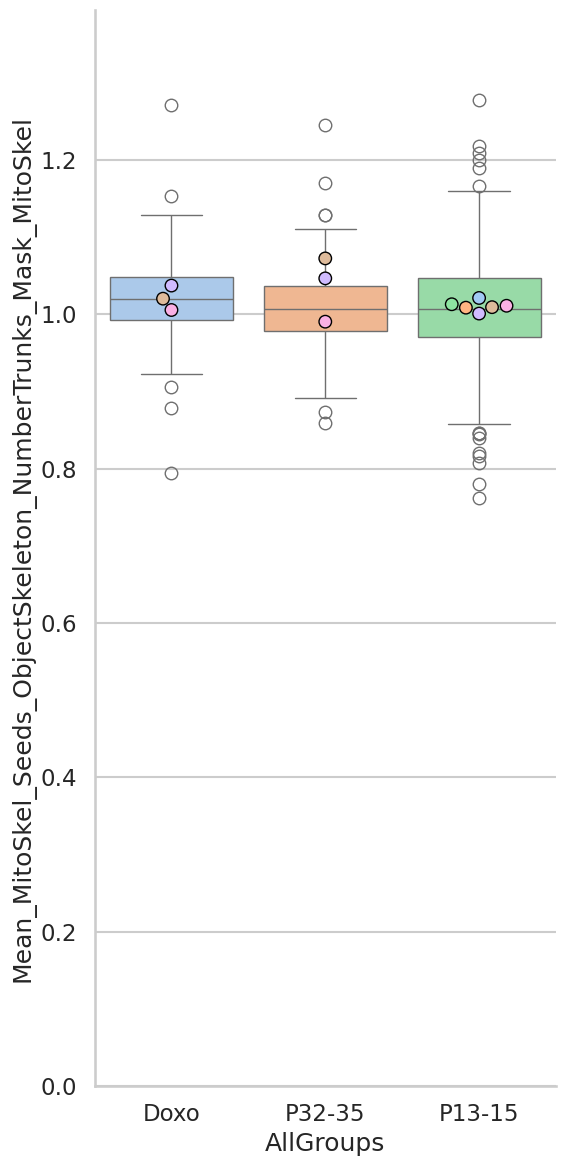

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:5.400e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:5.300e-03


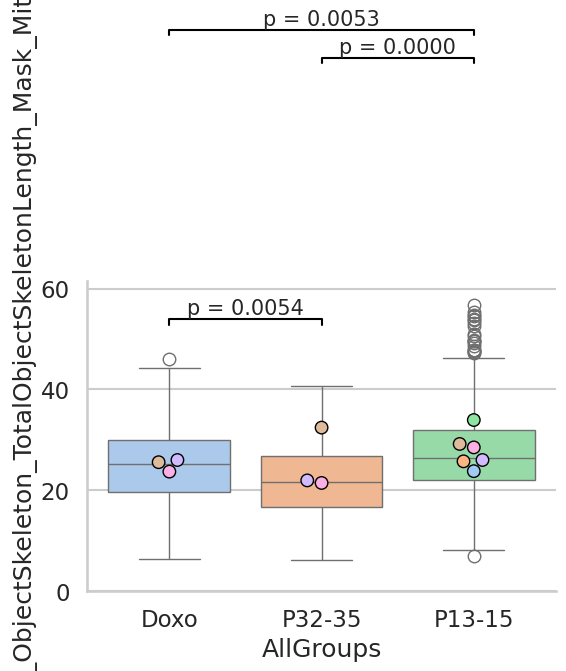

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


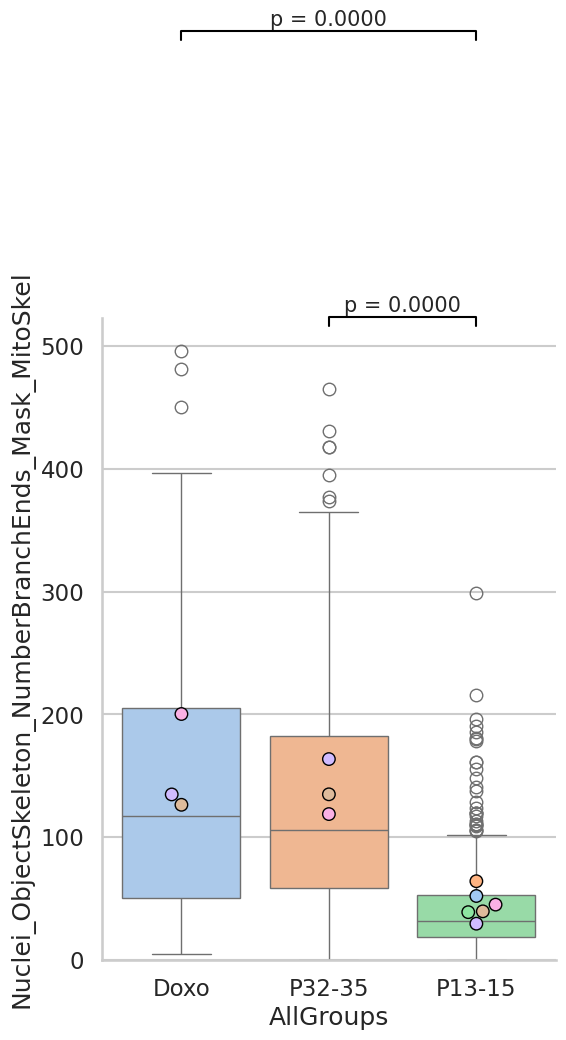

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


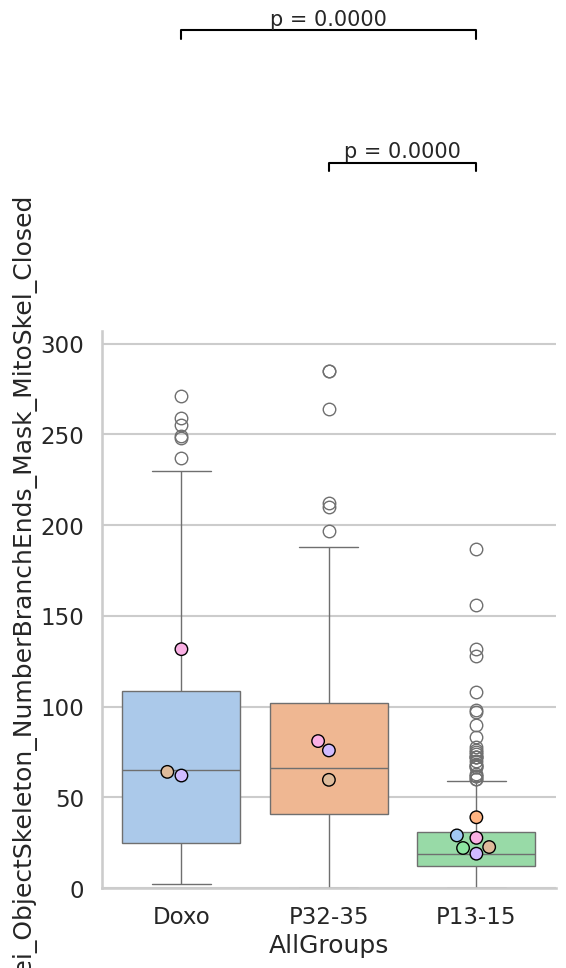

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.530e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


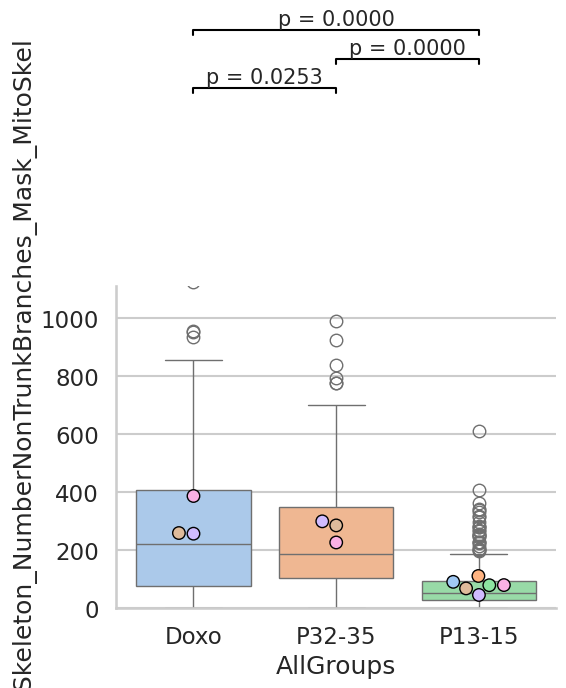

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


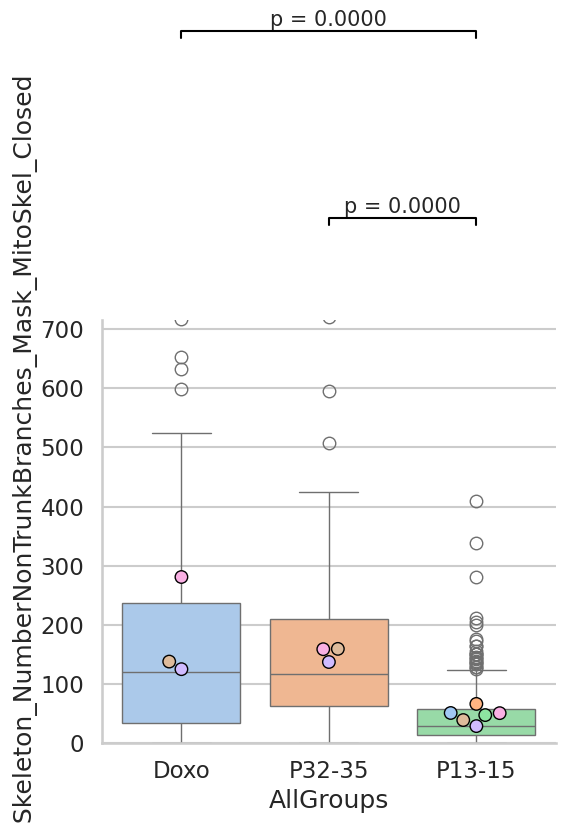

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


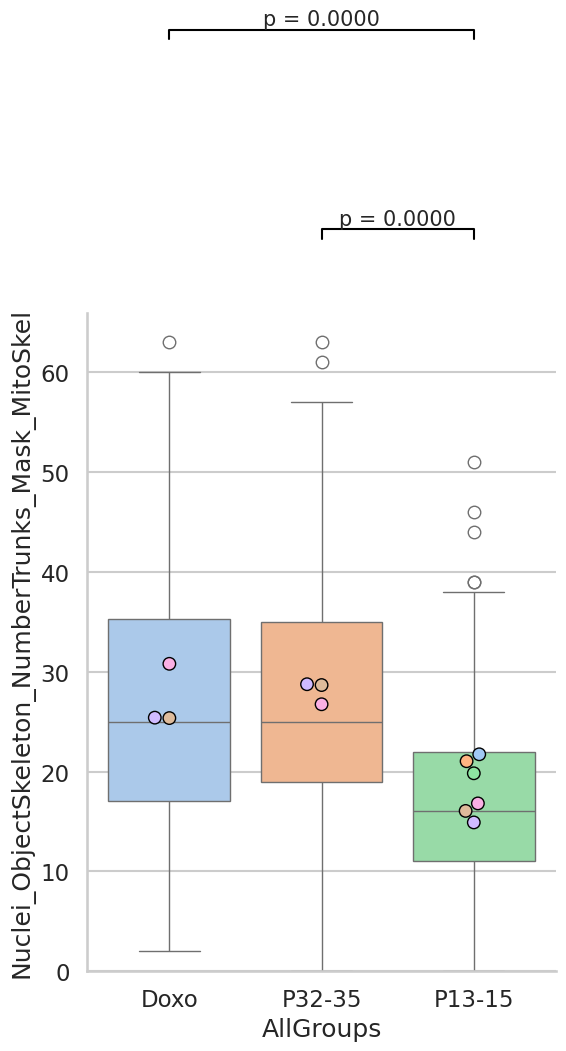

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


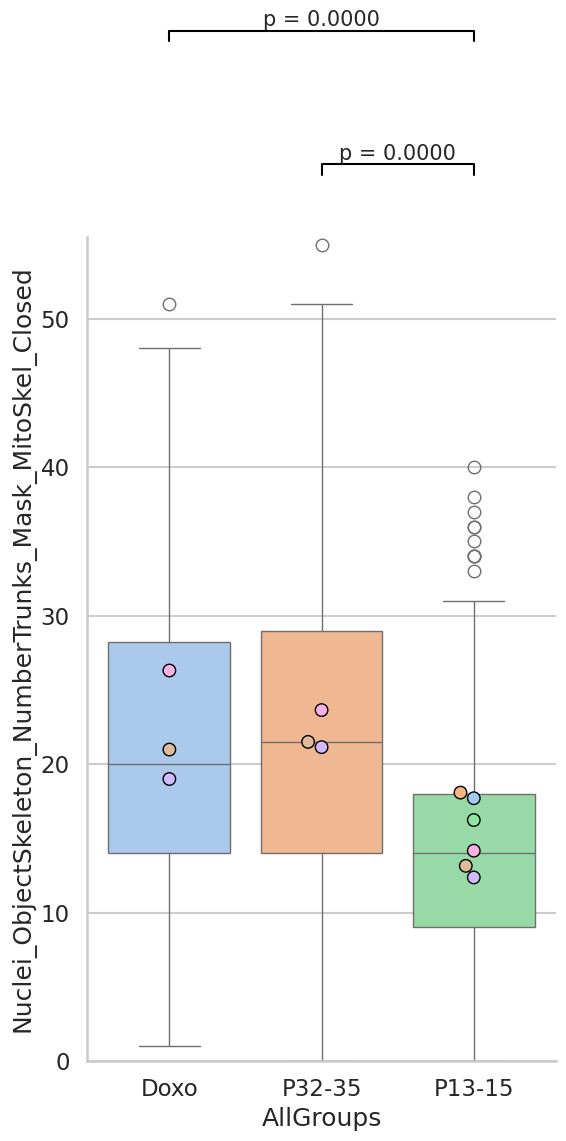

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:9.800e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


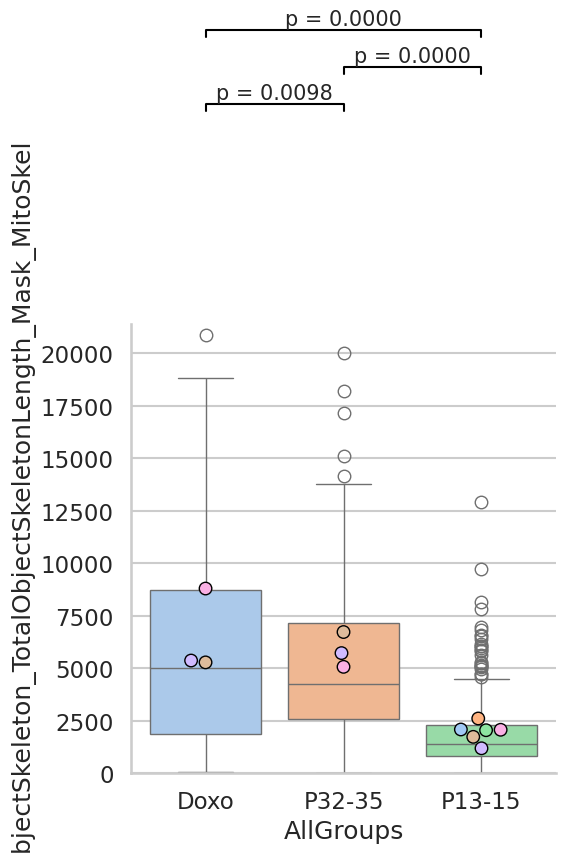

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.830e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


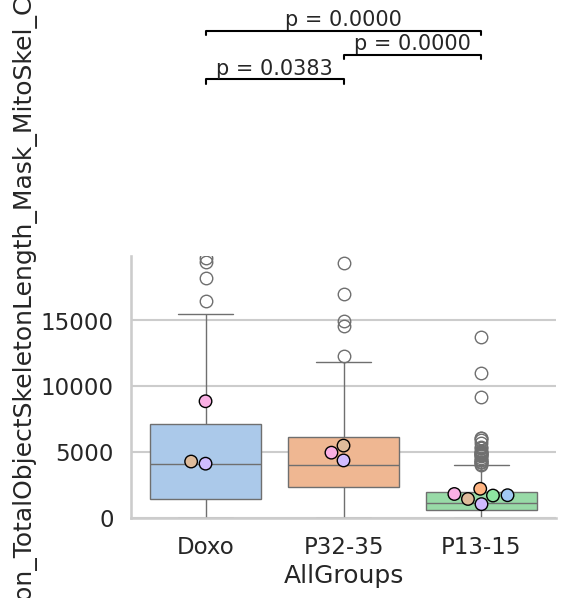

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.360e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


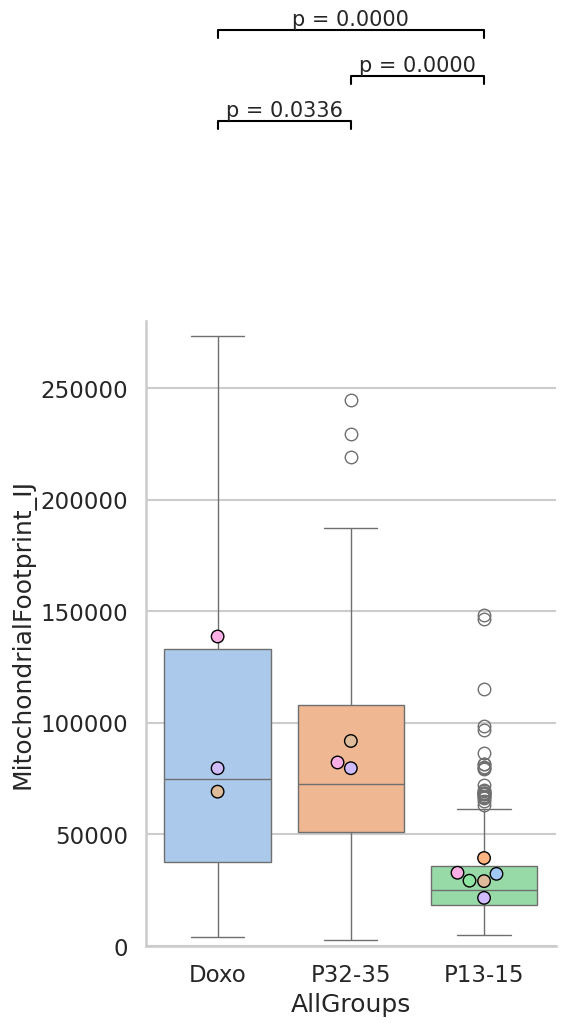

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


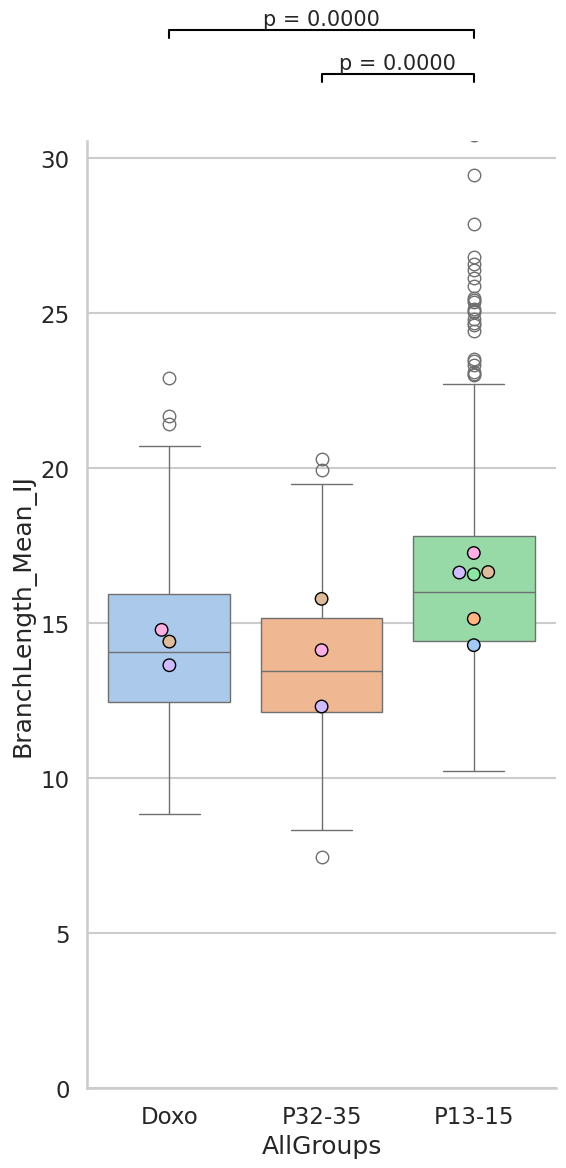

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


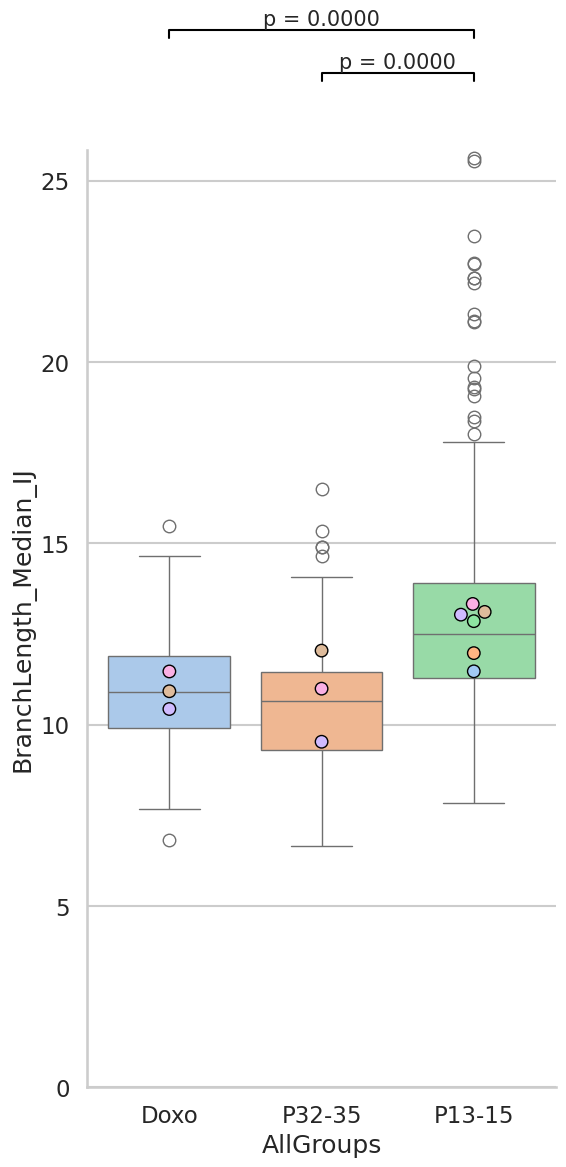

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:2.000e-04


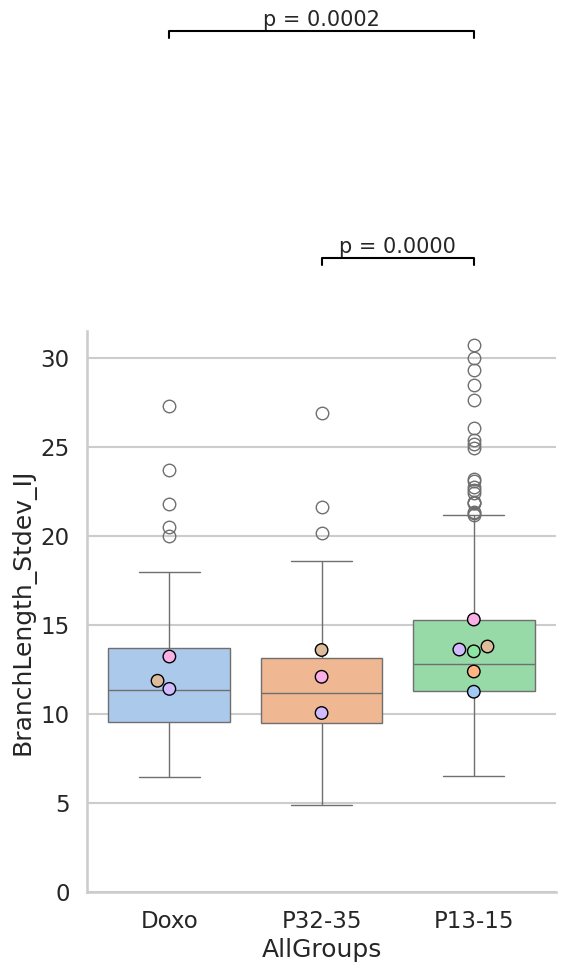

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:9.000e-04
Doxo vs. P13-15: Custom statistical test, P_val:7.300e-03


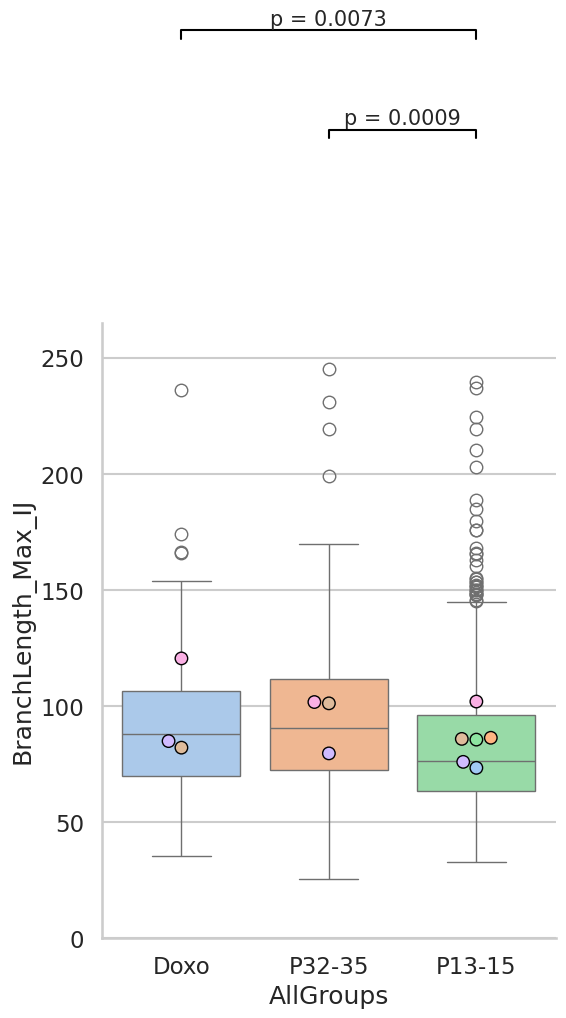

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.770e-02


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


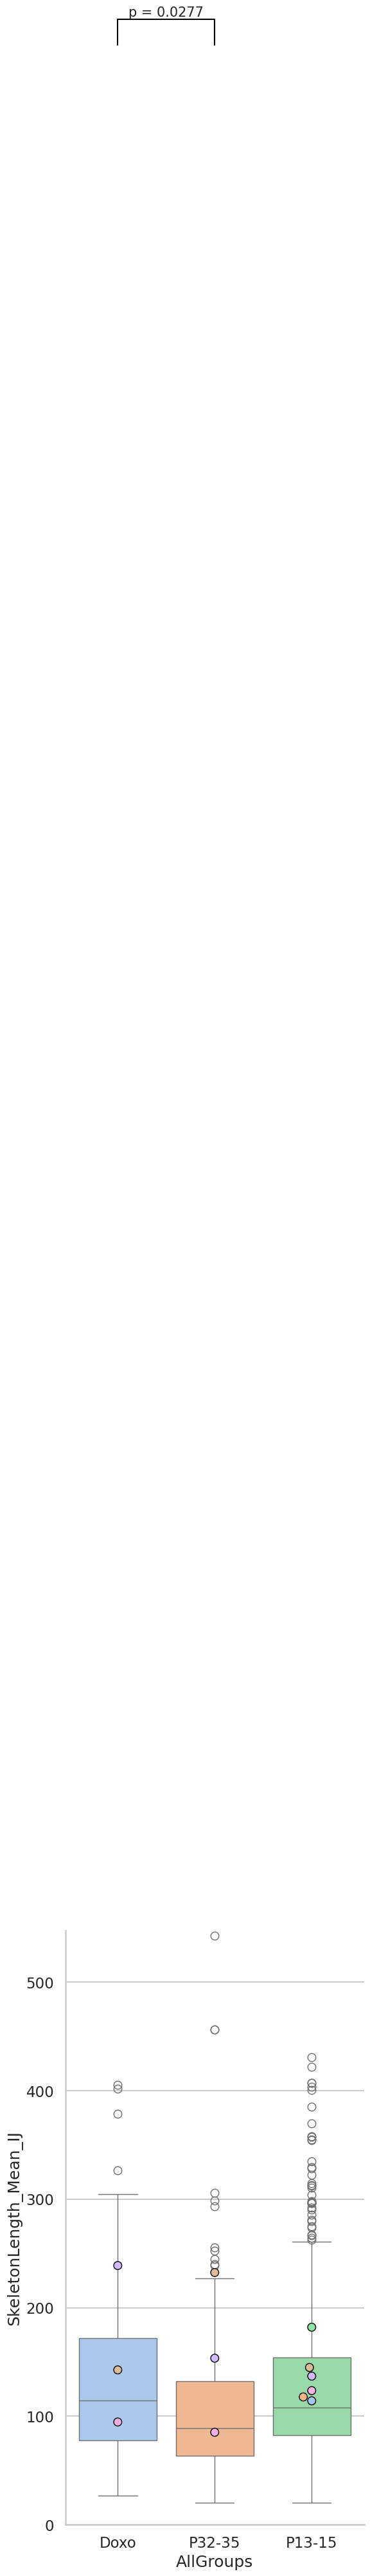

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


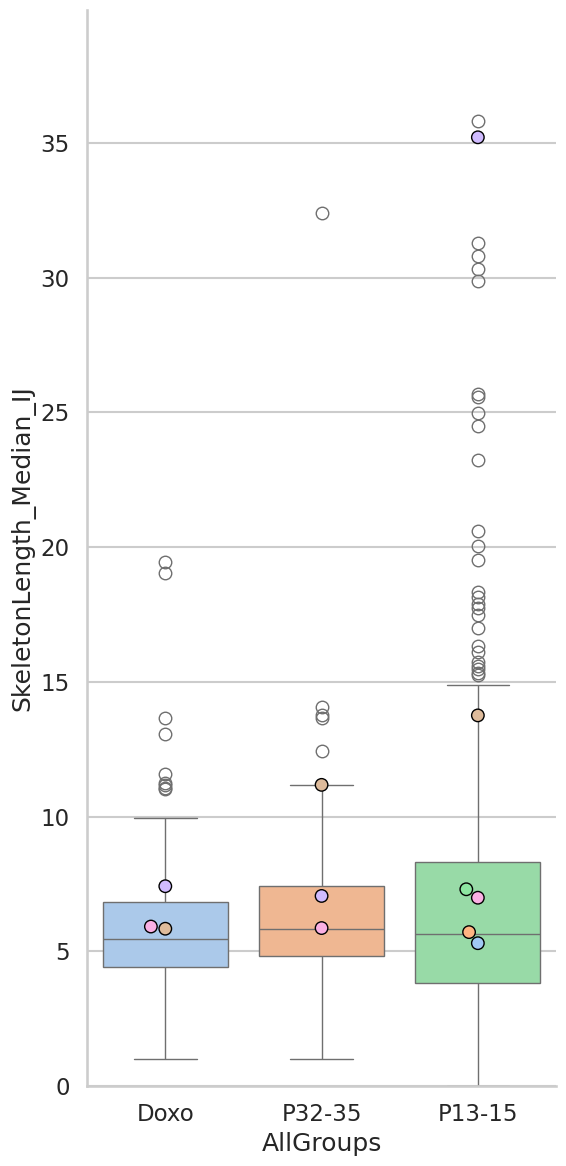

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:0.000e+00
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


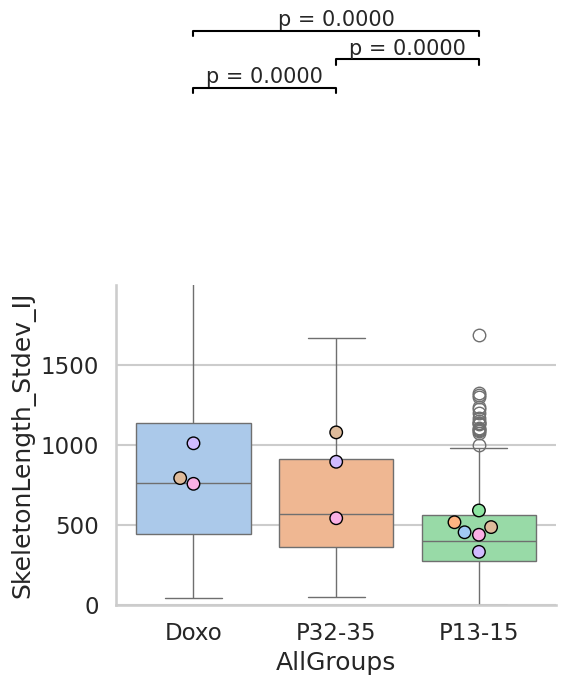

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:8.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


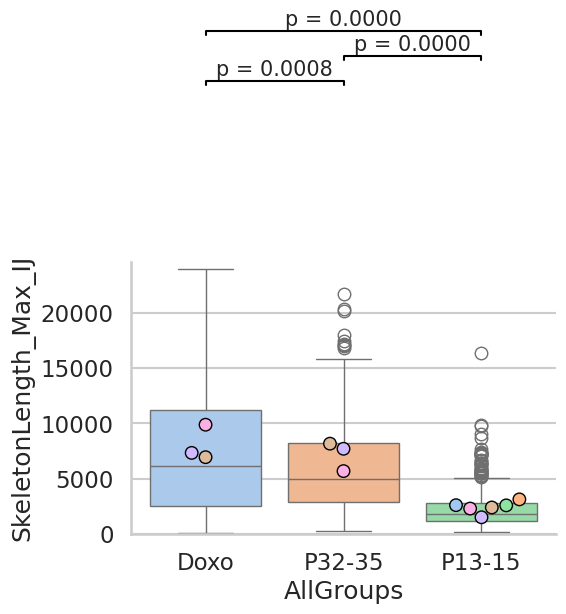

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.230e-02
Doxo vs. P13-15: Custom statistical test, P_val:8.500e-03


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


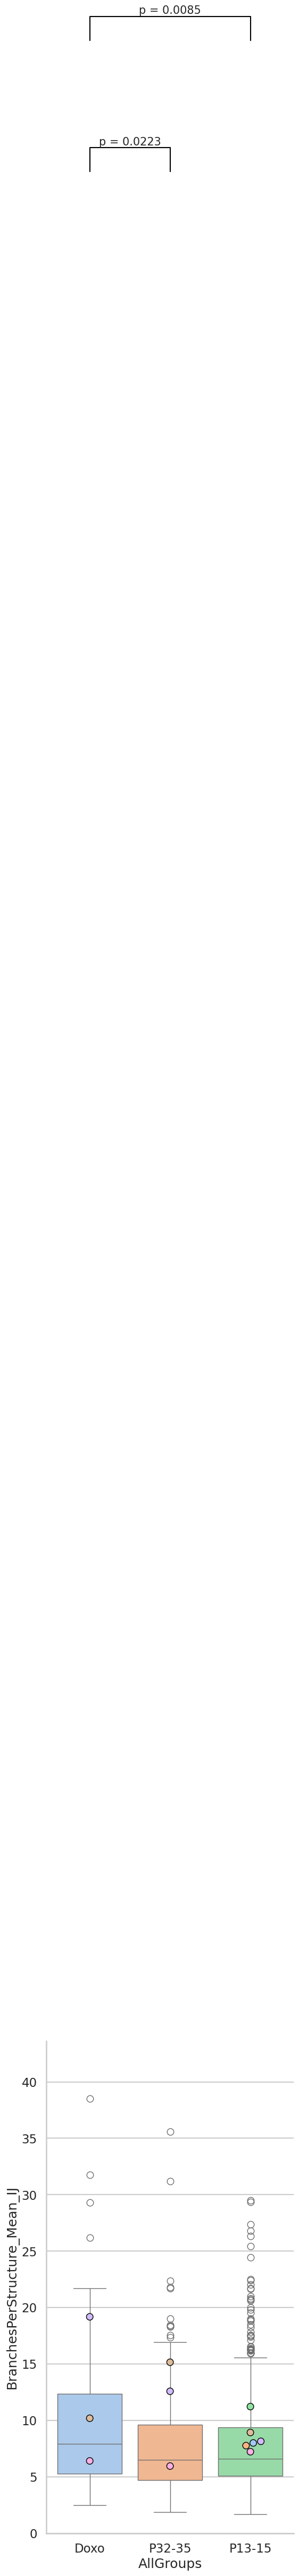

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


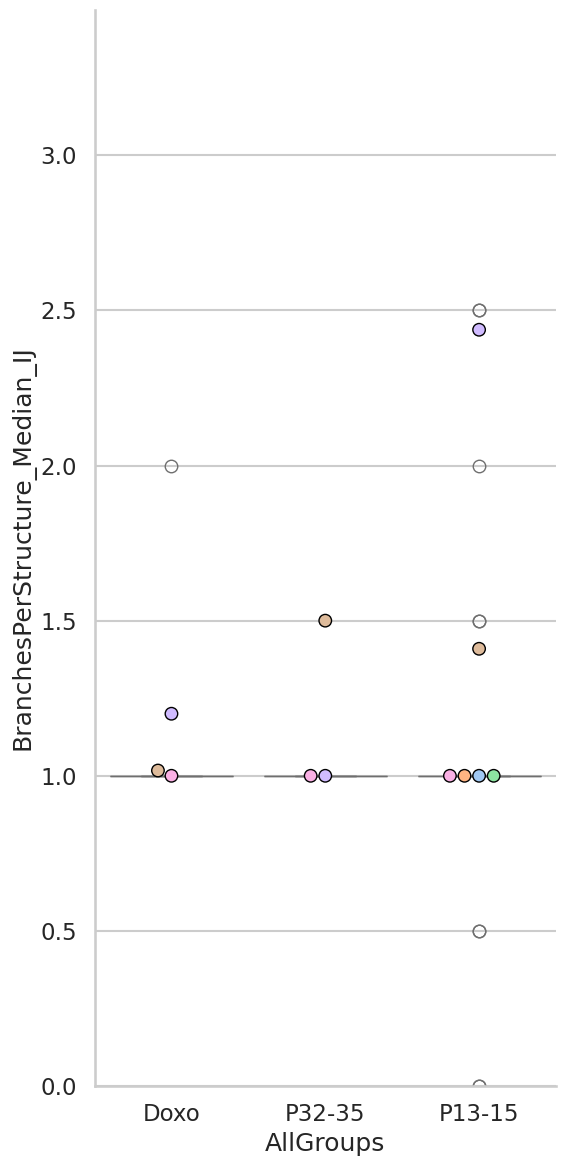

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


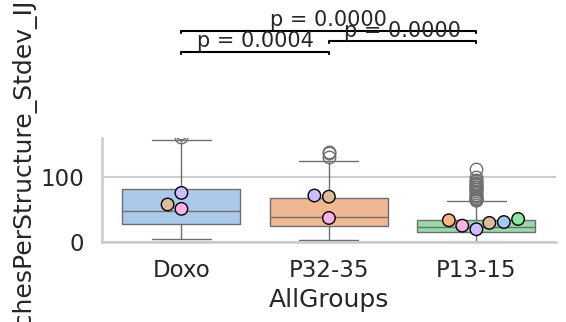

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.900e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


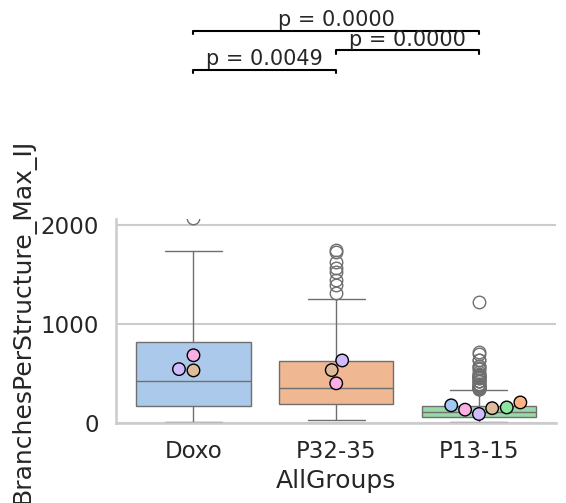

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


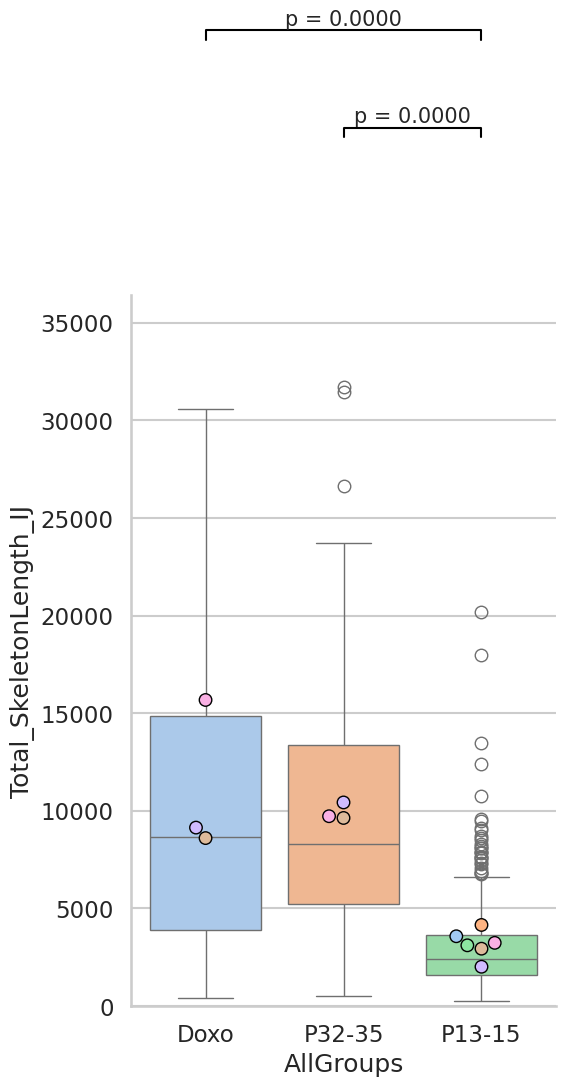

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


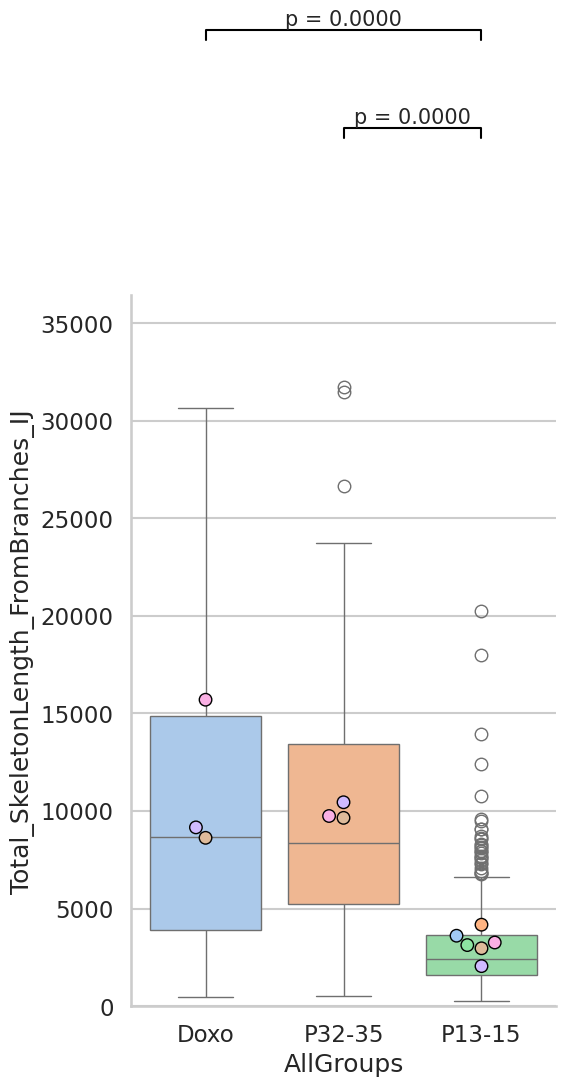

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


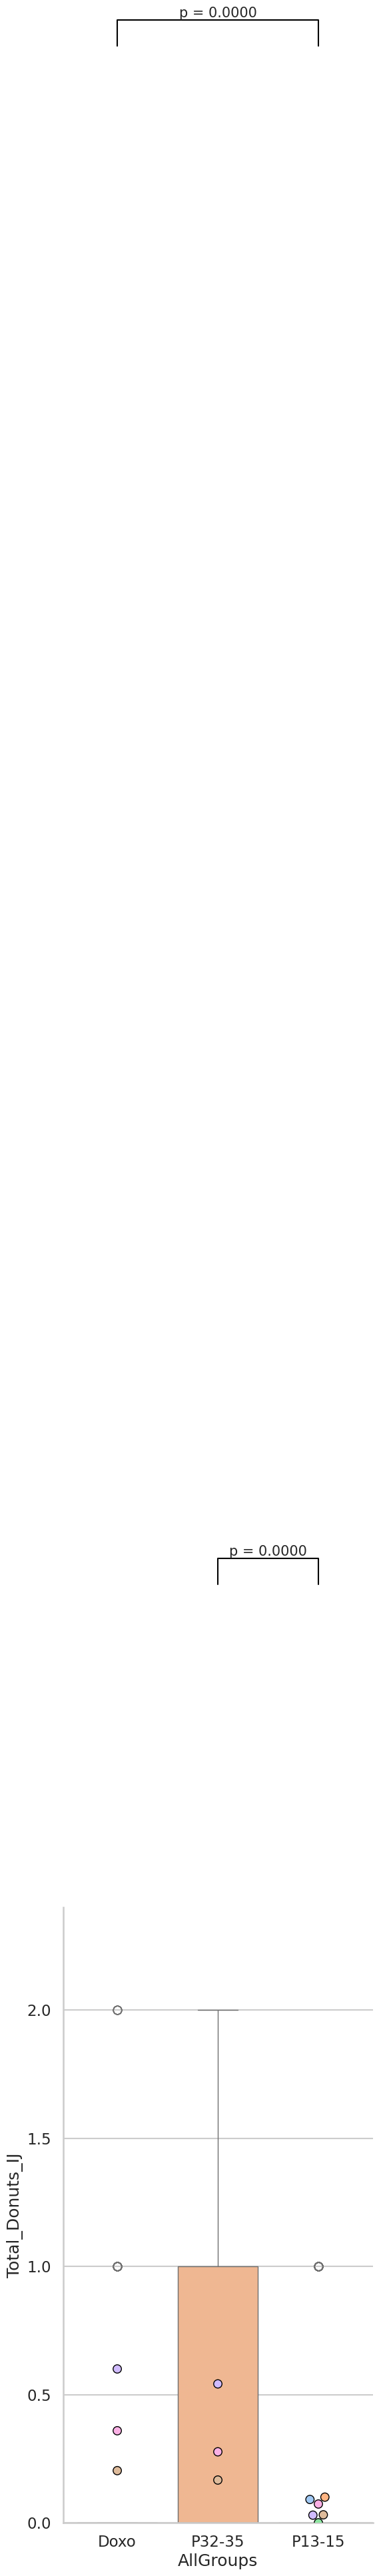

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


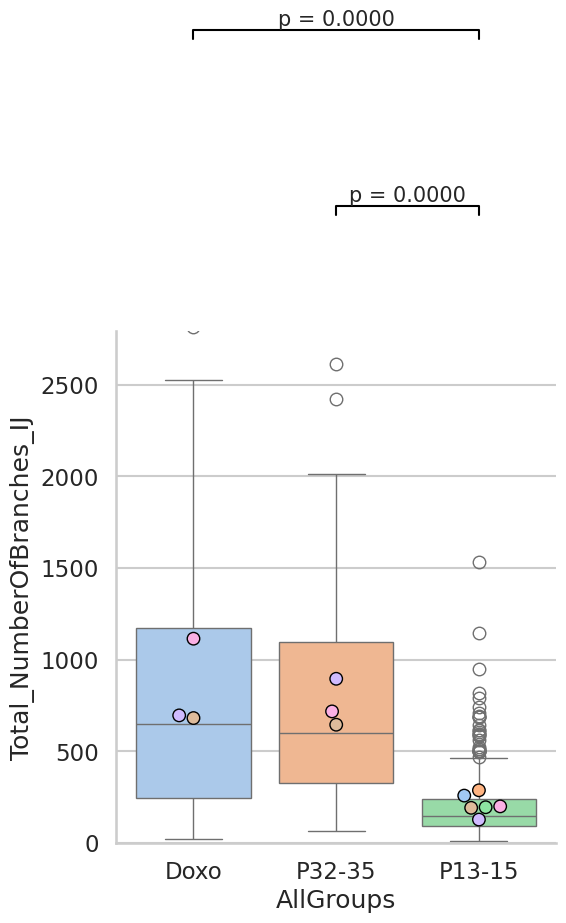

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


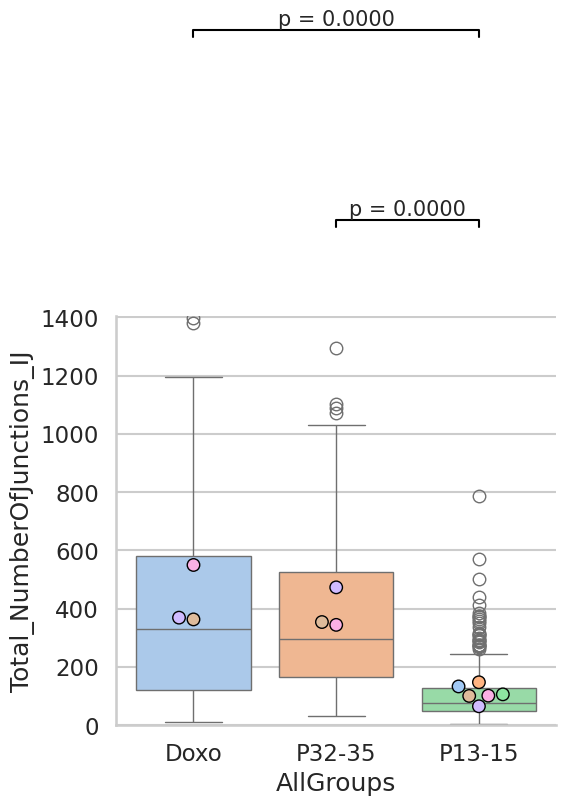

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


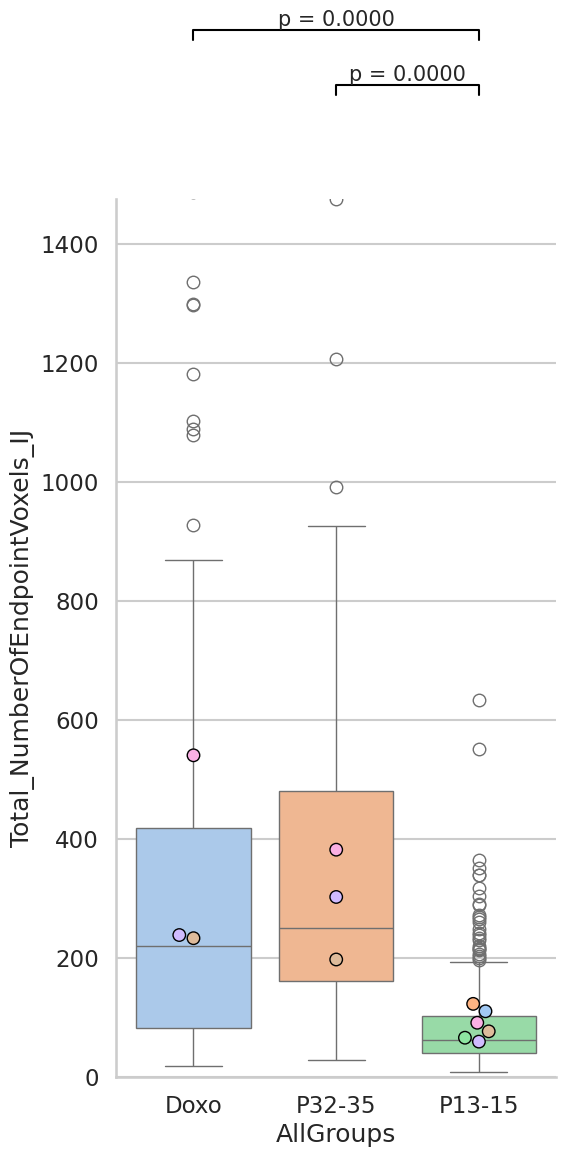

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


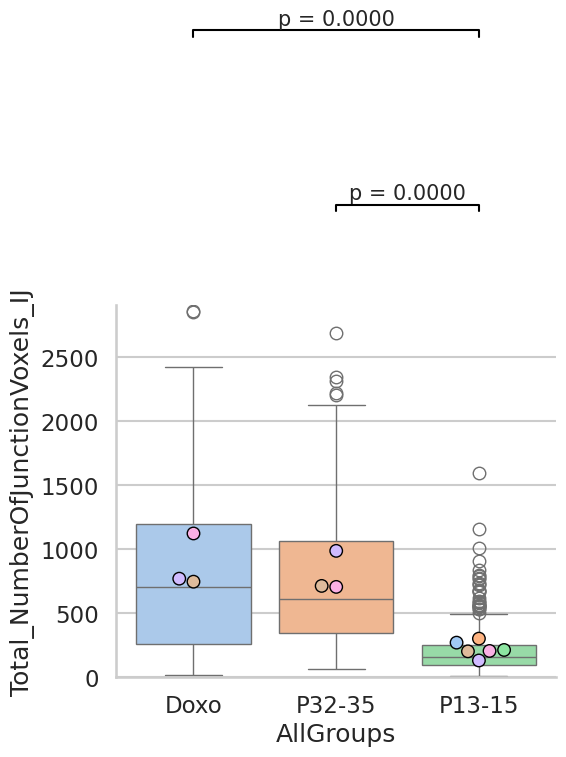

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


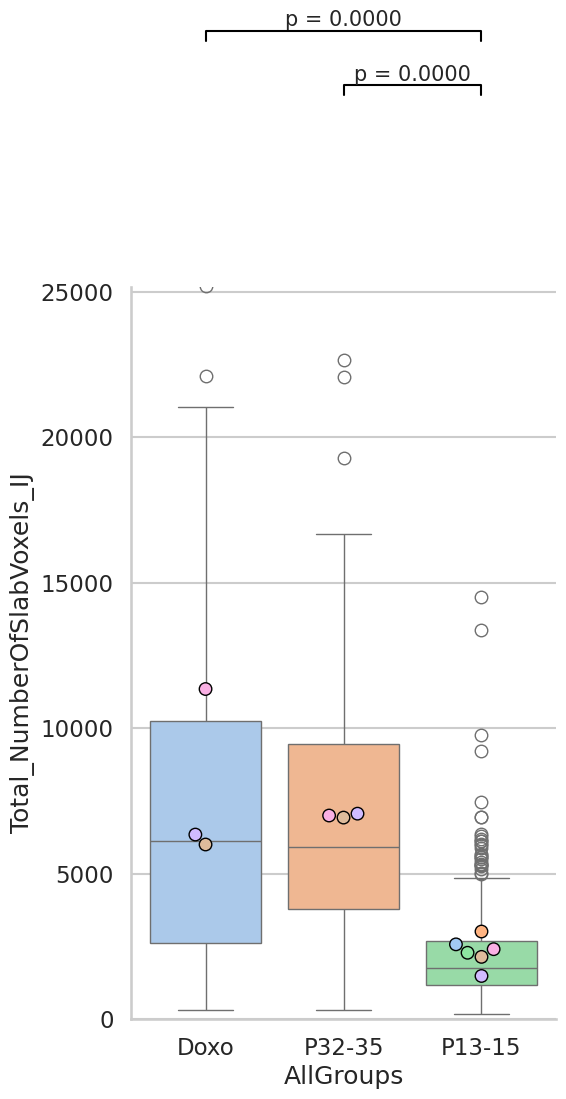

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


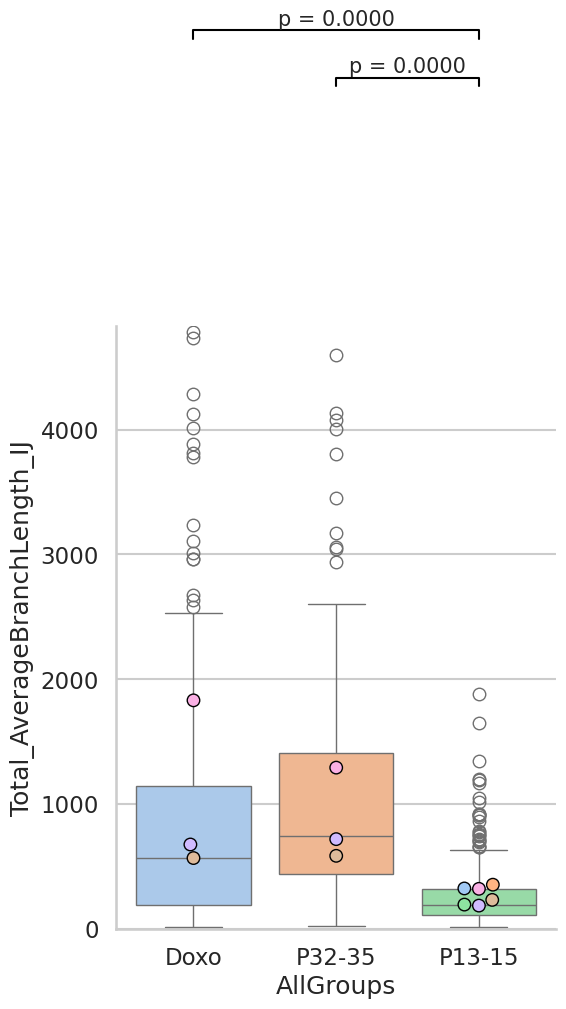

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


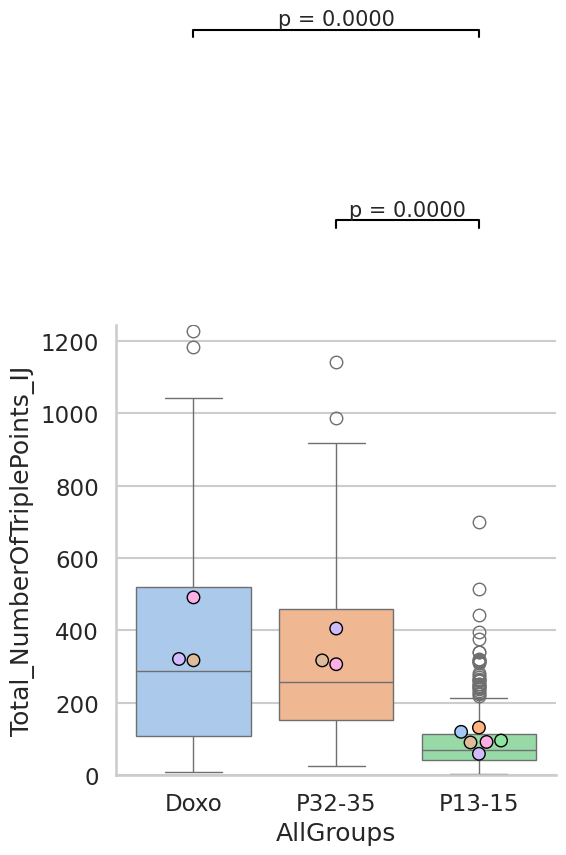

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


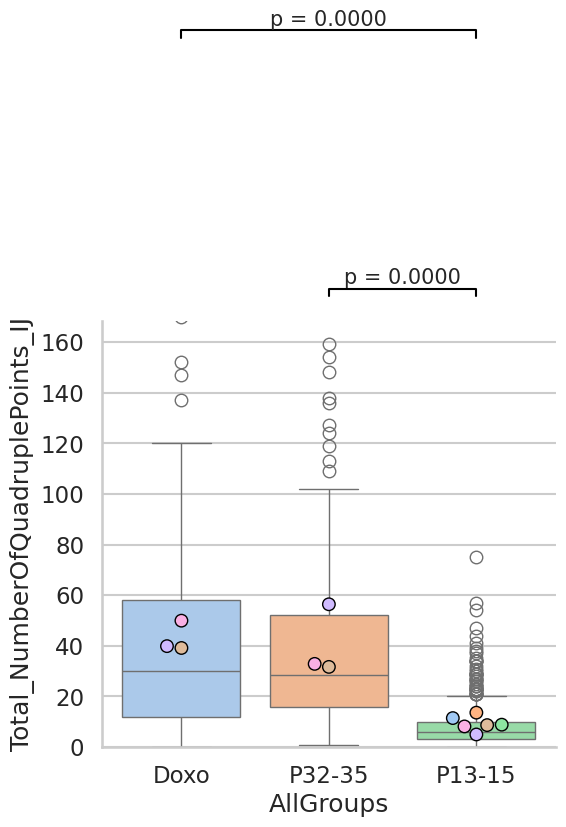

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


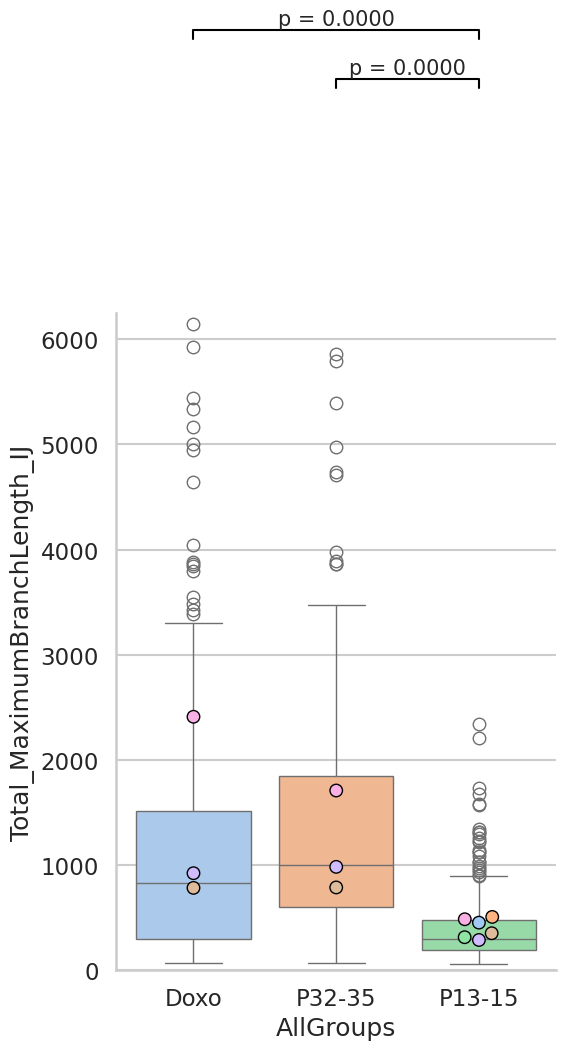

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


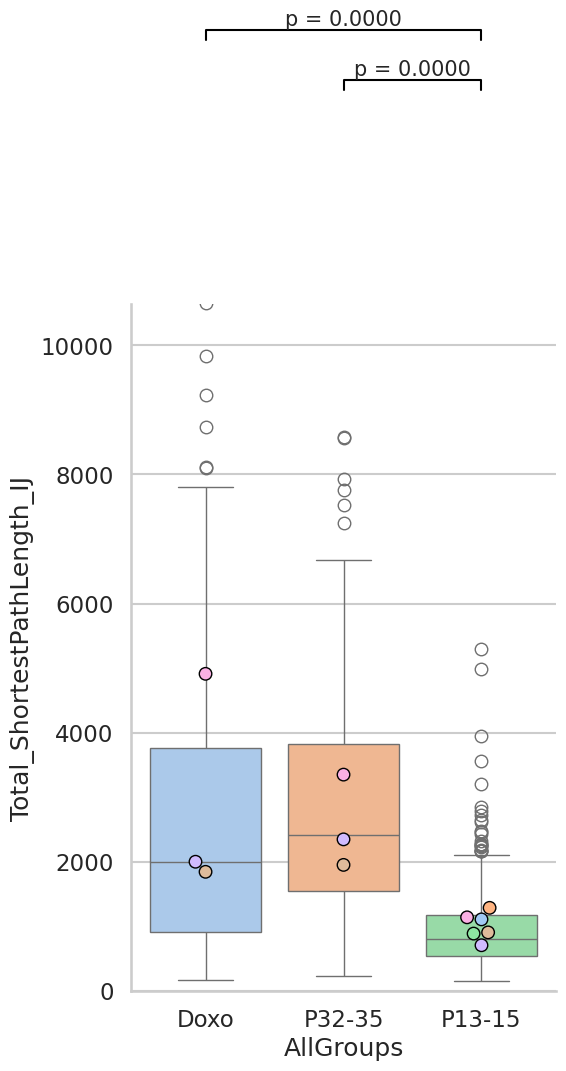

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.900e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


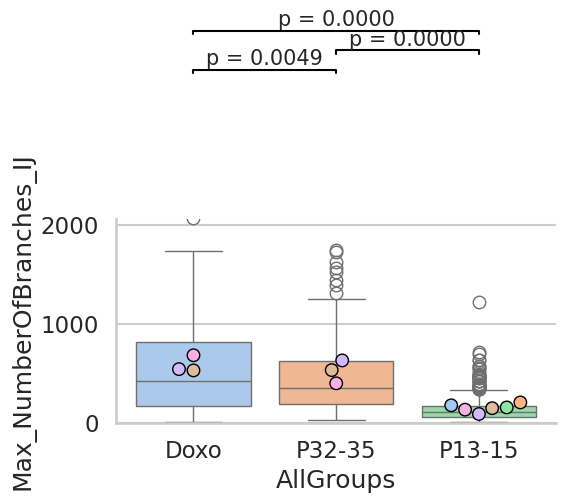

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.000e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


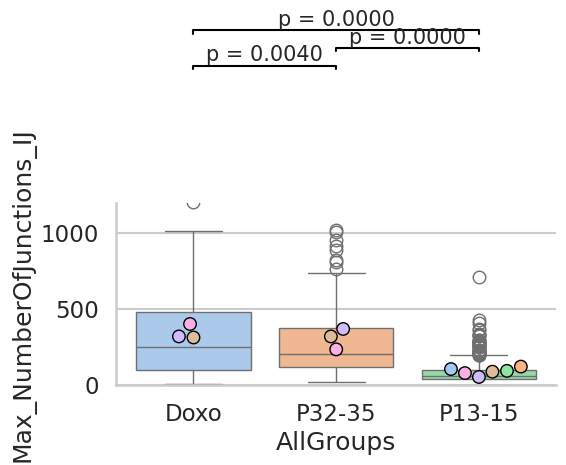

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.210e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


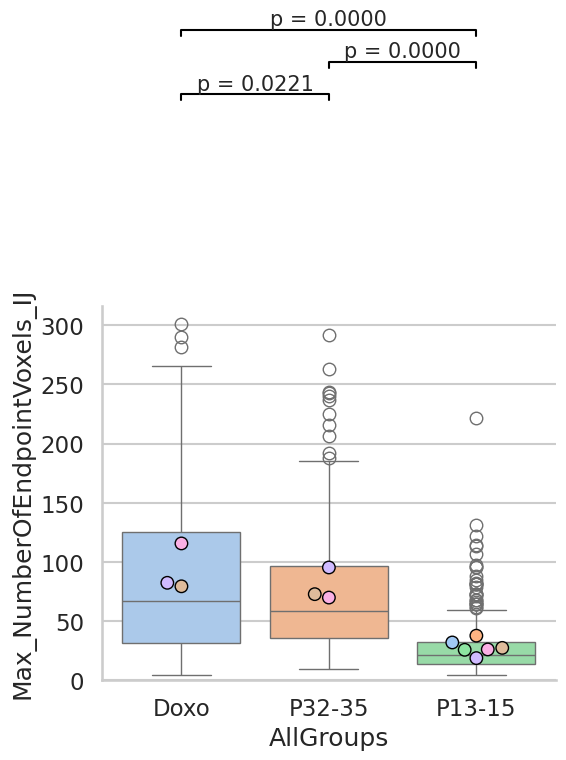

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.300e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


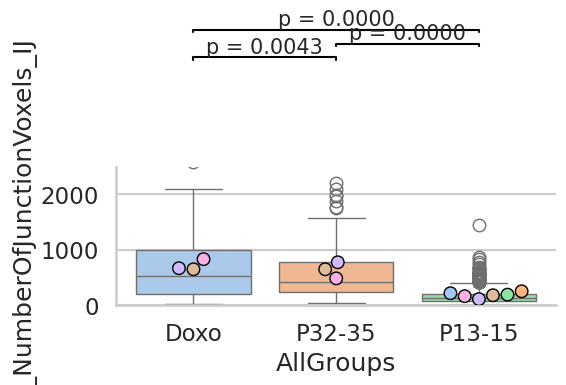

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:6.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


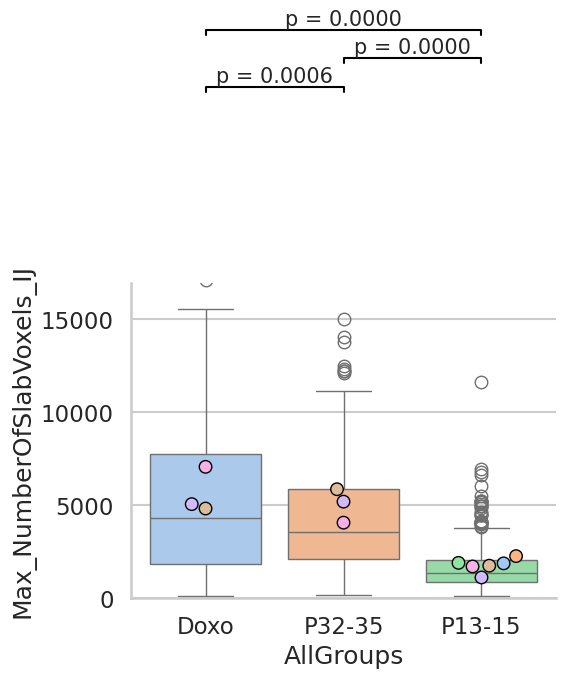

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


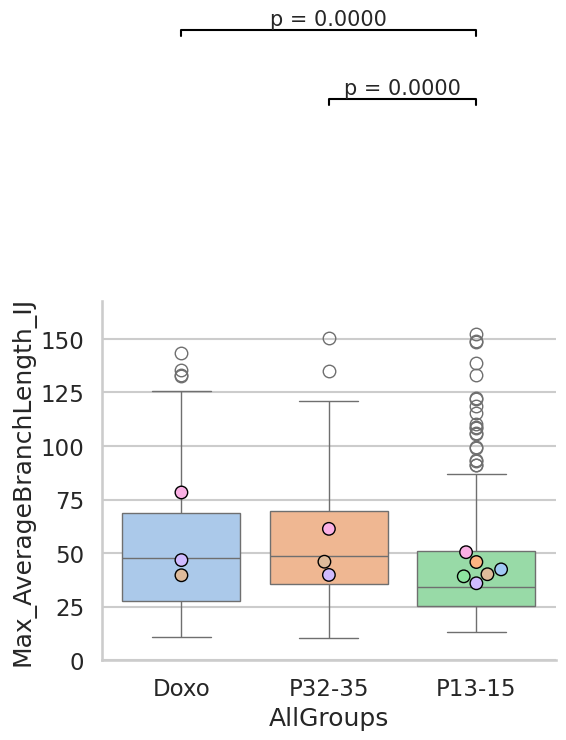

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.200e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


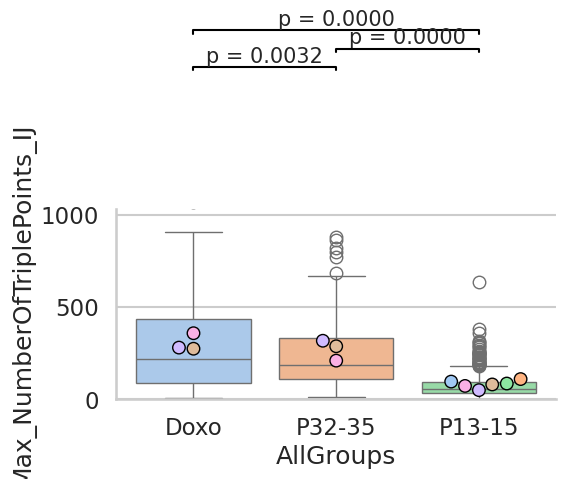

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.600e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


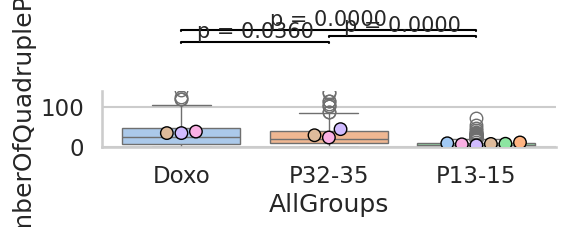

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:9.000e-04
Doxo vs. P13-15: Custom statistical test, P_val:7.300e-03


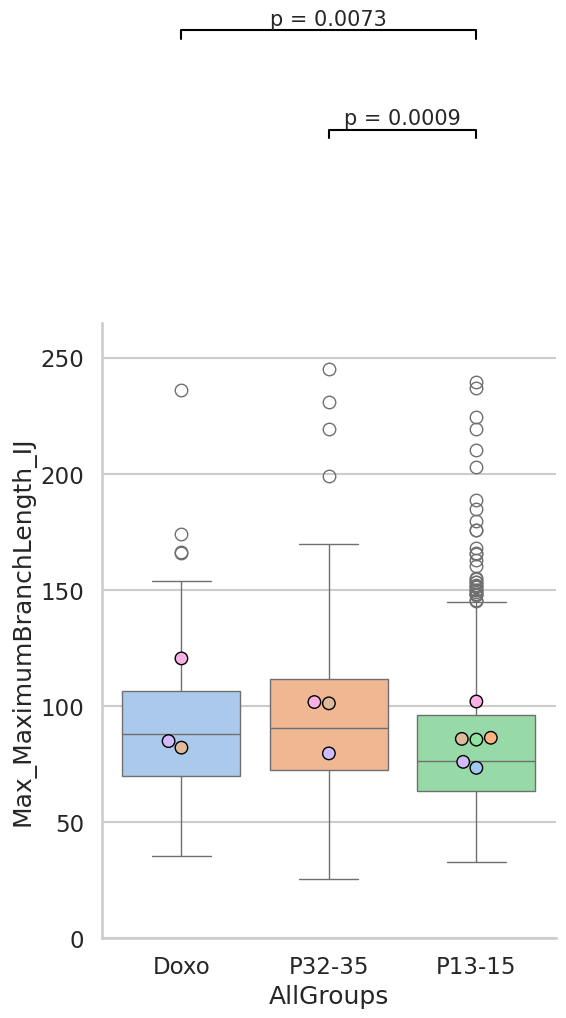

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


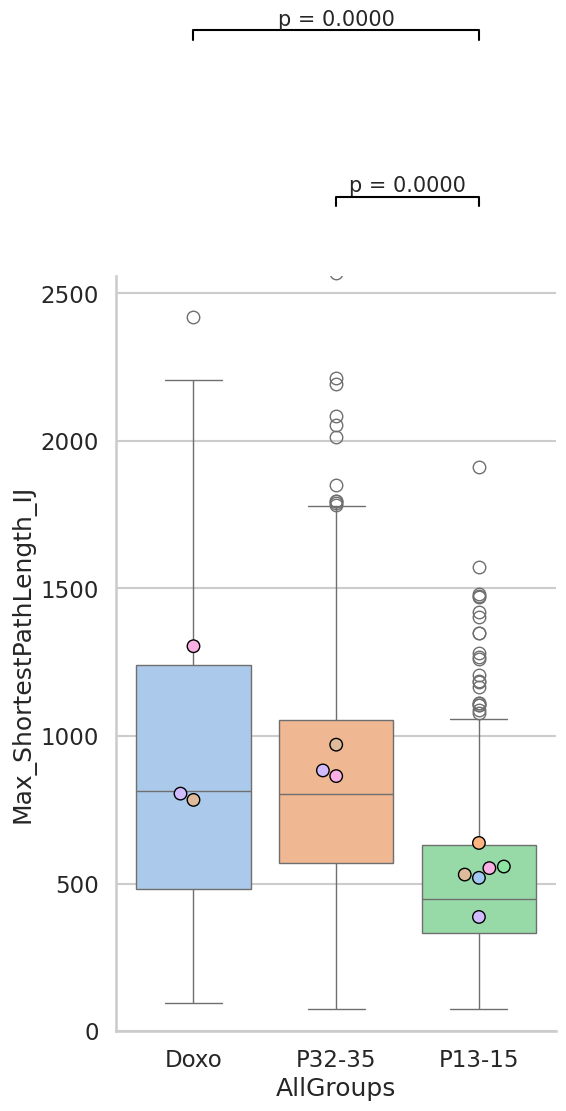

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


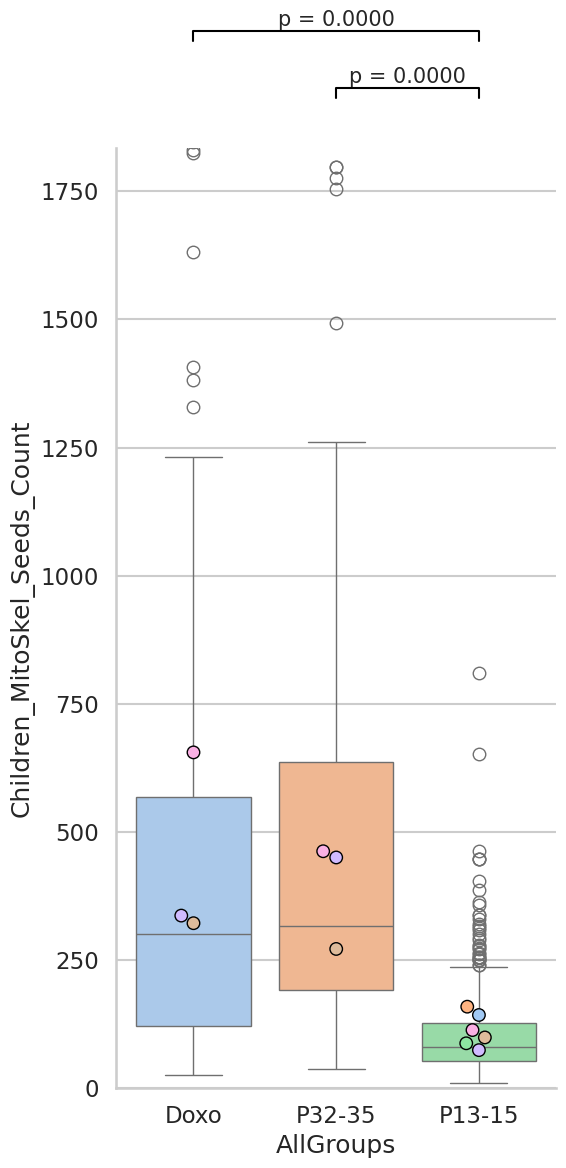

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


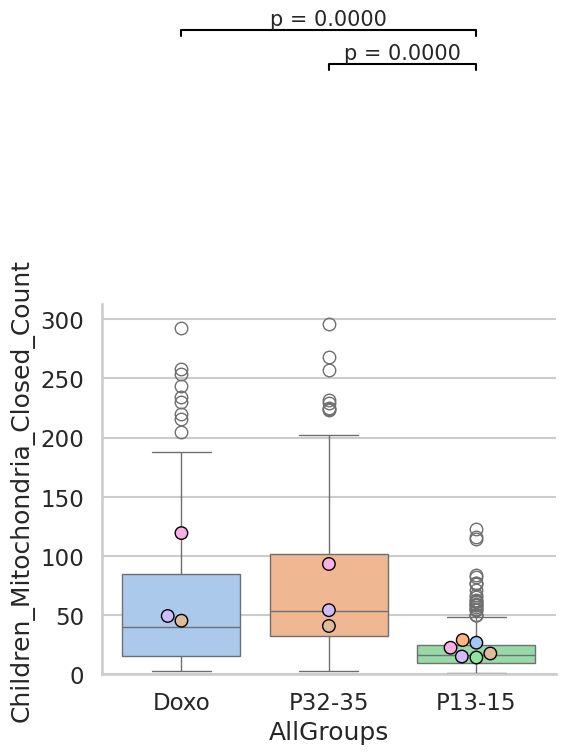

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


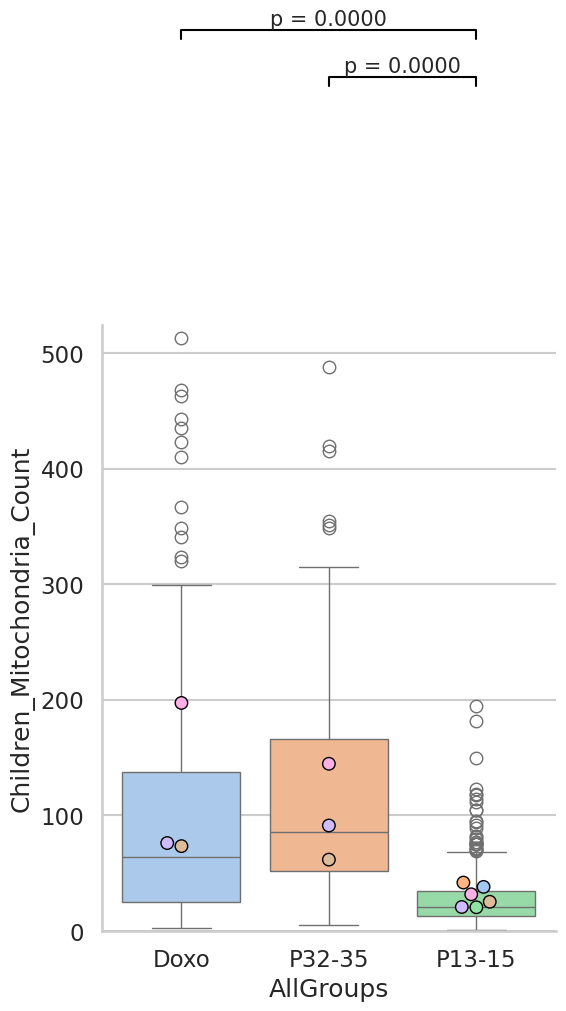

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:3.000e-04


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


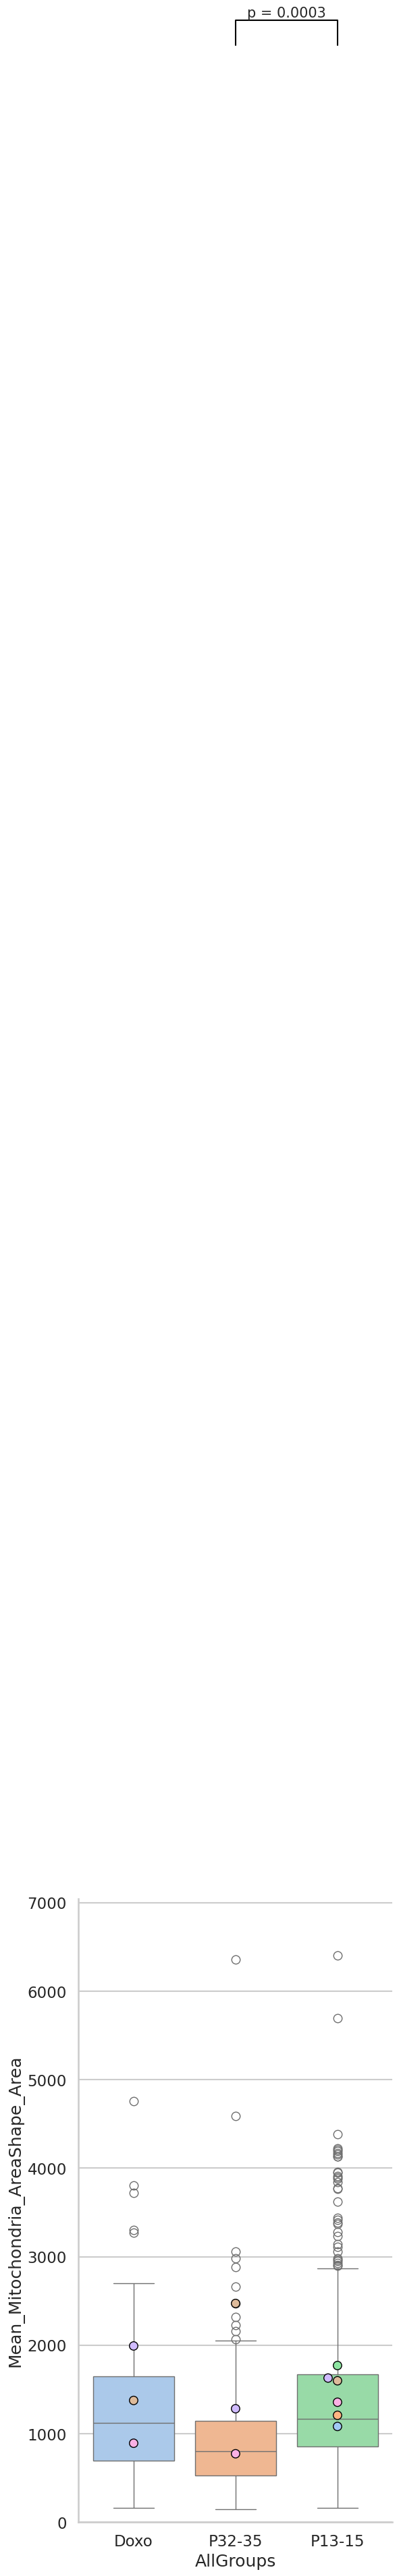

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.910e-02
P32-35 vs. P13-15: Custom statistical test, P_val:7.300e-03


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


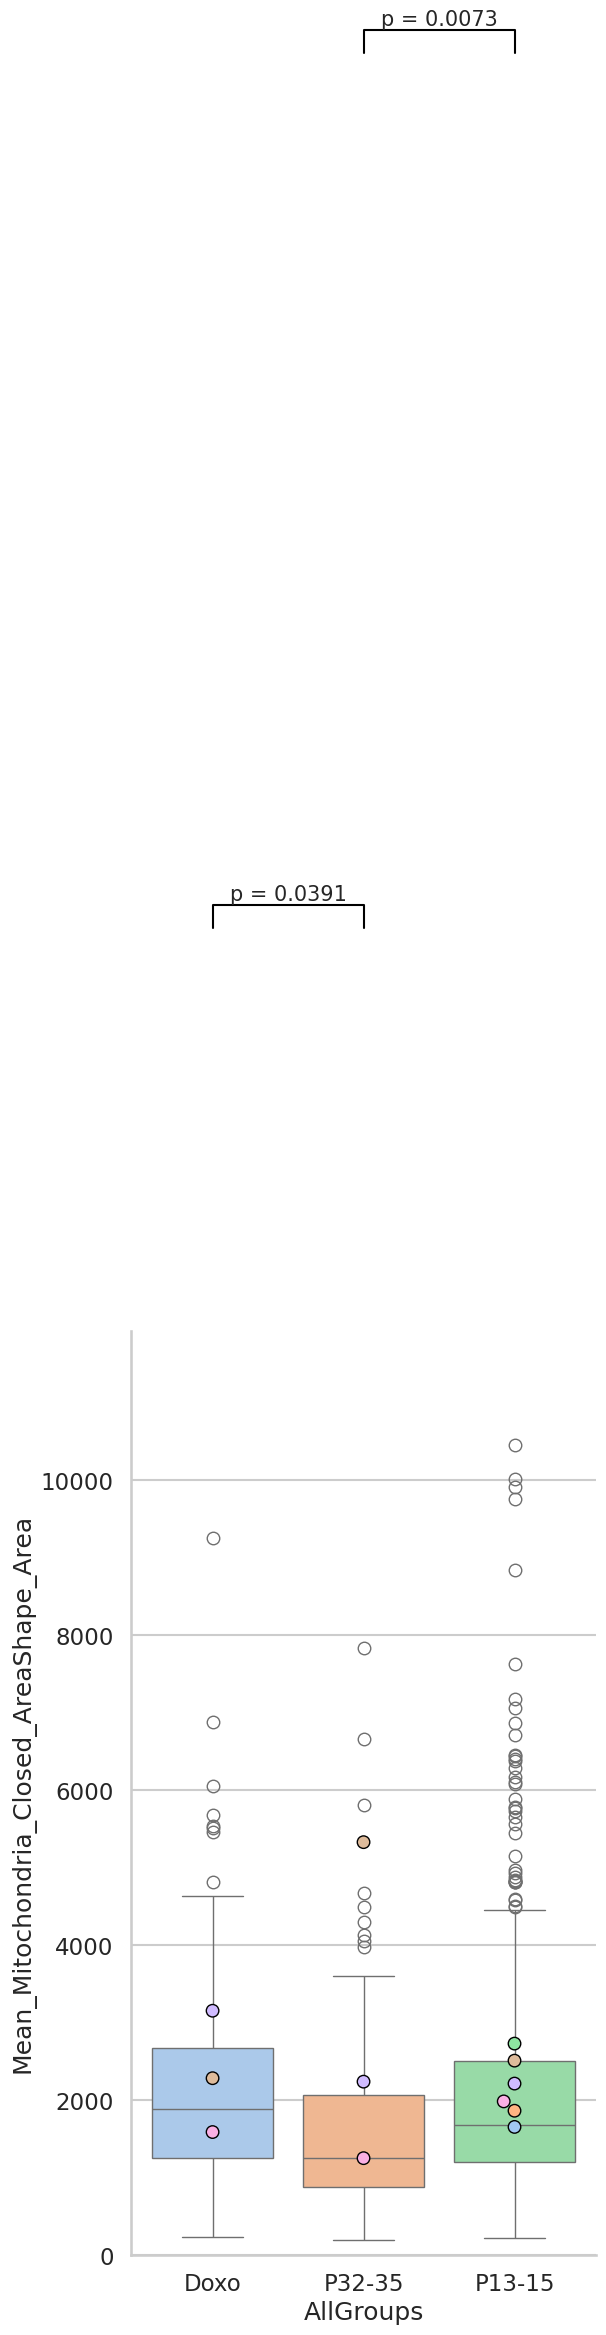

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.360e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


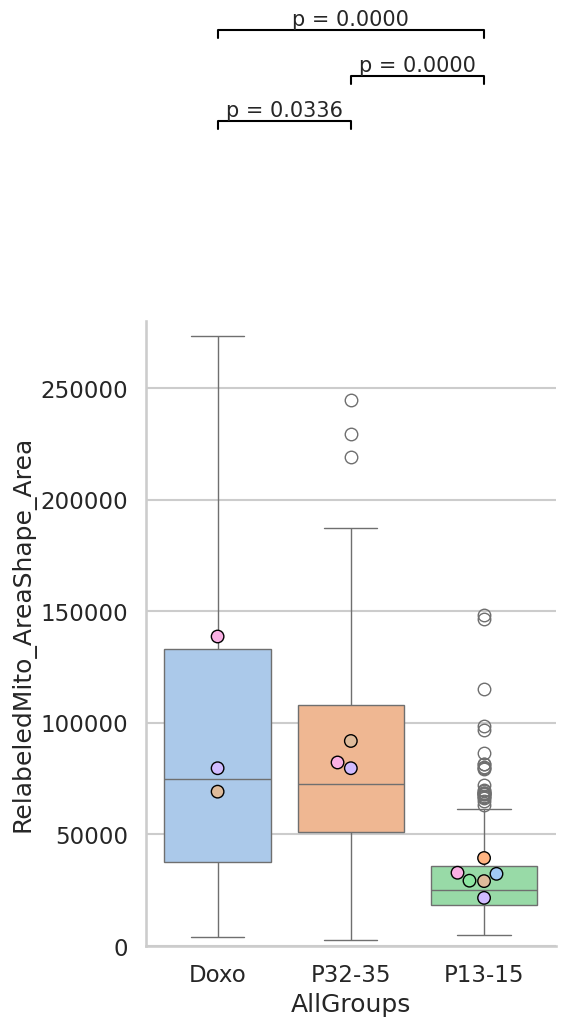

In [36]:
def plot_boxplots_with_swarm_tukey(
    display_df,
    display_df_pivot_plates,
    feature_cols,
    colour_dict=colour_dict,
    size=(6, 10),
    order=None,
    group_col="AllGroups",
    plate_col="Metadata_PlateNumber",
):
    outpath = "segmentation_test/plots_tukey"
    os.makedirs(outpath, exist_ok=True)
    from statannotations.Annotator import Annotator

    if order is None:
        order = display_df[group_col].dropna().unique().tolist()

    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("talk")
        ax = sns.boxplot(
            data=display_df,
            x=group_col,
            y=col,
            palette="pastel",
            fill=True,
            hue=group_col,
            legend=False,
        )
        sns.swarmplot(
            data=display_df_pivot_plates,
            x=group_col,
            y=col,
            palette=colour_dict,
            hue=plate_col,
            dodge=False,
            size=9,
            legend=False,
            linewidth=1,
            edgecolor="k",
        )

        pairs = getpairs(display_df, group_col, order=order)
        pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            display_df,
            display_df_pivot_plates,
            x_value=group_col,
            y_value=col,
            plate_number_col=plate_col,
            desired_pairs=pairs,
            order=order,
        )

        if pairs:
            annotator = Annotator(
                ax=ax,
                pairs=list(pairs),
                data=display_df,
                plot="boxplot",
                x=group_col,
                y=col,
                order=order,
            )
            annotator.reset_configuration()
            annotator.configure(
                text_format="full",
                test_short_name="tukey_v3",
                pvalue_format_string="{:.4f}",
                fontsize="small",
                loc="inside",
                hide_non_significant=True,
                color="black",
                verbose=2,
                line_height=0.01,
                text_offset=0.5,
                show_test_name=False,
            )
            annotator.set_pvalues_and_annotate(p_values)

        sns.despine()
        if display_df[col].dropna().shape[0] > 0:
            upper = np.nanpercentile(display_df[col].dropna(), 99) * 1.2
            if np.isfinite(upper):
                plt.ylim(0, upper)
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot_tukey.png"))
        plt.show()
        
plot_boxplots_with_swarm_tukey(
    display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 12)
)


# Define the cell features


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


## Normalize features to control (Passage 6-8)

In [ ]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="violinplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "violinplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    # nonparametric tests
    if test_name in ["kruskal", "dunn", "kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["drubin", "drubin_posthoc"]:
        used_pairs, p_values = kruskal_with_drubin_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["conover", "con", "kruskal-conover"]:
        used_pairs, p_values = kruskal_with_conover_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["nemenyi", "kruskal-nemenyi"]:
        used_pairs, p_values = kruskal_with_nemenyi_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
            p_correction=p_correction,
        )
    # parametric tests
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name in ["games", "games-howell"]:
        used_pairs, p_values = pvalues_anova_with_games_howell_pingouin(
            data,
            pivot_data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["tahmane", "tahmane-t2"]:
        used_pairs, p_values = anova_with_tahmane_posthoc(
            data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v2", "tukey_posthocs"]:
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v3", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["pairwise_ttest" or "multiple_ttest"]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=True,
            display=True,
        )
    elif test_name in [
        "pairwise_mwu"
        or "multiple_mwu"
        or "pairwise_mannwhitney"
        or "multiple_mannwhitney"
        or "pairwise_wilcoxon"
        or "multiple_wilcoxon"
    ]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=False,
            display=True,
        )
    elif test_name in ["ttest_posthoc", "welch's_posthoc", "tt_posthoc"]:
        used_pairs, p_values = anova_with_corr_ttest_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_corr=p_correction,
            display_results=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', 'games-howell', 'drubin', 'tukey_v2', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)

    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        # fill = True
        width=1,
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
    )
    # add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction,
                annotation_location=annotation_location,
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10 * data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)
    else:
        axlim = (None, None)

    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f'{y_value}_{plate_col_name}_histogram')}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(
            df_sorted,
            value_col=y_value,
            group_col=x_value,
            palette="Set2",
            save=True,
            out_dir=out_dir,
            show_percentiles=True,
        )
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="ticks", context=context, font_scale=font_scale)

    feature_df = df_sorted[[x_value, y_value, plate_col_name]].copy()
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")

    # remove outluers
    if remove_outliers is True:
        if rm_outliers_method == "mad":
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=50
            )
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=500
            )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == "iqr":
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        # display(feature_df)

    # group by plate and condition
    group_avg_df = feature_df.groupby([x_value, plate_col_name], as_index=False).mean()
    # sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)

    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction,
        annotation_location=annotation_location,
    )

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            title=plate_col_name,
        )
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            # display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_", " "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)

    # Set the ylim and don't throw an inf
    if ylim is None:
        ylim = axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine(trim=True)
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

In [ ]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
this_df = norm_combined_cell_df_mitolyso.copy()

data_df = this_df  # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (13, 12)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density

## Make multiple plots as defined

In [ ]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            data_df = data_df[data_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context="talk",
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=True,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 12),
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
)